# Projet REXIA 2026

## Gaël GARNIER - Raphaël VIGNAL - Maëlys HANOIRE - Fanny BADOULES

### Lien GitHub si besoin : 
https://github.com/RaphaelVignal/rexia_projet

# Partie (1/3) : Données tabulaires

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List,Dict,Tuple

## 1. Analyse du jeu de données:

### Analyse générale

In [104]:
df_rh:pd.DataFrame=pd.read_csv("Data/RH_dataset.csv",delimiter=";")
df_rh.head()

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


In [105]:
df_rh.isnull().sum()

Famille d'emploi                0
Dernière promotion (mois)       0
Dernière augmentation (mois)    0
Début de contrat (années)       0
Ancienneté groupe (années)      0
Etablissement                   0
Âge (années)                    0
Parent                          0
Niveau hiérarchique             0
Salaire (Euros)                 0
Statut marital                  0
Véhicule                        0
matricule                       0
label                           0
dtype: int64

On a pas de valuer nulle, analysons les types de données

In [106]:
df_rh.dtypes

Famille d'emploi                    str
Dernière promotion (mois)       float64
Dernière augmentation (mois)    float64
Début de contrat (années)       float64
Ancienneté groupe (années)      float64
Etablissement                     int64
Âge (années)                      int64
Parent                            int64
Niveau hiérarchique               int64
Salaire (Euros)                   int64
Statut marital                      str
Véhicule                          int64
matricule                         int64
label                             int64
dtype: object

In [107]:
df_rh.info()

<class 'pandas.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  str    
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  str    
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  label       

In [108]:
df_rh.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')

On remarque une colone matricule qui représente le matricule de l'employé

In [109]:
df_rh.shape

(23857, 14)

### Analyse matricule

In [110]:
df_rh["matricule"].nunique()

2676

On a 2676 personnes dans le dataset donc comme il ya beaucoup plus de lignes on s'attends à ce que lorsqu'une personne a une évolution dans sa carrière, elle a une ligne pour chaque évolution. Donc on s'attends à ce que le matricule soit dupliqué. A vérifier.

In [111]:
#nombre de doublons dans matricule
df_rh["matricule"].duplicated().sum()


np.int64(21181)

In [112]:
df_rh["matricule"].value_counts()

matricule
32      15
1890    15
1847    15
1963    15
2642    15
        ..
1543     1
1558     1
2356     1
1571     1
1563     1
Name: count, Length: 2676, dtype: int64

Beaucoup de matricule sont dupliqués, analysons les lignes du dataframe pour voir ce qui change quand le matricule est le même.

In [113]:
# déterminer ce qui change dans les lignes du dataframe quand le matricule est le même
df_rh_doublons_matricule=df_rh[df_rh["matricule"].duplicated(keep=False)]
df_rh_doublons_matricule["matricule"].value_counts()

matricule
32      15
1890    15
1847    15
1963    15
2642    15
        ..
1547     2
1515     2
1544     2
2210     2
1318     2
Name: count, Length: 2490, dtype: int64

In [114]:
df_rh_doublons_matricule["matricule"].nunique()

2490

On a 2490 personnes sur les 2676 donc cela touche un grand nombre de personnes, analysons les lignes du dataframe pour voir ce qui change quand le matricule est le même.

In [115]:
df_rh_doublons_matricule["matricule"].shape

(23671,)

In [116]:
#déterminons ce qui change dans les lignes du dataframe quand le matricule est le même
list_df_rh_doublons_matricule=[]
for mat in df_rh_doublons_matricule["matricule"].unique():
    list_df_rh_doublons_matricule.append(df_rh_doublons_matricule[df_rh_doublons_matricule["matricule"]==mat].sort_values(by="Ancienneté groupe (années)",ascending=True))

for i in range(4):
    display(list_df_rh_doublons_matricule[i])

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.91,0.97,27,30,1,1,3199,Marié(e),0,32,0
435,Production,11.280000,10.750000,1.18,1.20,27,30,1,1,3200,Marié(e),0,32,0
1735,Production,14.040000,13.590000,1.45,1.45,27,31,1,1,3200,Marié(e),0,32,0
3247,Production,16.920000,16.370001,1.70,1.70,27,32,1,1,3199,Marié(e),0,32,0
4799,Production,19.889999,19.340000,2.08,2.08,28,33,1,1,3199,Marié(e),0,32,0
6358,Etudes & Technique,2.350000,21.889999,2.27,2.38,27,34,1,1,3202,Marié(e),0,32,0
7967,Etudes & Technique,5.960000,0.960000,2.53,2.53,27,34,1,1,3560,Marié(e),0,32,0
9637,Etudes & Technique,8.710000,3.890000,2.77,2.77,27,34,1,1,3559,Marié(e),0,32,0
11353,Etudes & Technique,11.500000,6.770000,3.03,3.03,27,34,1,1,3560,Marié(e),0,32,0
13091,Etudes & Technique,14.770000,1.980000,3.25,3.31,27,35,1,1,3773,Marié(e),0,32,0


,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
437,Production,37.970001,25.559999,15.020000,16.510000,7,46,1,2,3861,PACS,1,1890,0
1737,Production,40.820000,28.430000,15.210000,16.719999,7,47,1,2,3860,PACS,1,1890,0
3249,Production,43.750000,30.790001,15.420000,16.780001,7,48,1,2,3858,PACS,1,1890,0
5601,Production,46.869999,33.070000,15.720000,16.820000,7,48,1,2,3859,PACS,1,1890,0
7190,Matériel/Equipement,49.840000,2.060000,16.790001,17.440001,7,48,1,2,3960,Marié(e),1,1890,0
8834,Matériel/Equipement,52.630001,4.990000,17.049999,17.480000,7,49,1,2,3958,Marié(e),1,1890,0
10524,Matériel/Equipement,55.509998,7.910000,17.209999,17.670000,7,49,1,2,3954,Marié(e),1,1890,0
12258,Production,58.580002,10.920000,17.290001,17.990000,7,49,1,2,3951,Marié(e),1,1890,0
14032,Matériel/Equipement,61.770000,2.250000,17.889999,18.059999,7,50,1,2,4077,Marié(e),1,1890,0


,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
438,Production,28.370001,25.240000,17.620001,18.000000,28,50,1,2,4326,PACS,1,1847,0
1738,Production,31.469999,27.980000,17.940001,18.070000,28,51,1,2,4327,PACS,1,1847,0
3250,Production,34.630001,30.309999,18.270000,18.370001,28,51,1,2,4327,PACS,1,1847,0
5602,Production,37.770000,32.619999,18.600000,18.670000,28,52,1,2,4327,PACS,1,1847,0
7191,Production,40.779999,34.849998,18.879999,18.969999,28,52,1,2,4327,PACS,1,1847,0
8835,Production,43.720001,2.510000,19.450001,19.450001,28,53,1,2,4461,PACS,1,1847,0
10525,Production,46.400002,5.170000,19.670000,19.750000,28,53,1,2,4458,PACS,1,1847,0
12259,Production,49.020000,7.630000,19.780001,20.049999,28,53,1,2,4454,PACS,1,1847,0
14033,Production,52.459999,2.490000,20.400000,20.400000,28,53,1,2,4553,PACS,1,1847,0


,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
3,Production,5.24,5.10,1.02,1.75,27,24,0,1,2641,Célibataire,0,2619,1
439,Production,7.99,7.86,1.29,1.92,27,25,0,1,2640,Célibataire,0,2619,1


On voit que les colones qui sont la famille d'emploi (rarement) ce qui indique un changement de poste (à vérifier si il y a des changements qui arrivent plus souvent que d'autres). Ce qui change toujours c'est l'ancienneté groupe (annnée) qui indique le nombre d'annnée que la personne a passé dans l'entreprise. On remarque que le début de contrat augmente aussi en permanence on note qu'il y a souvent un écart de 0.6 entre le début de contrat et l'ancienneté groupe (années) ce qui indique surement une période d'essai de 6 mois (il serait intéressant de voir quelqu'un avec une date de contrat qui repart de 0 pour analyser si ça existe). On a aussi la dernière promotion qui est donc fortement lié à l'augmentation de salaire celle ci fluctue beaucoup et semble assez important pour prédire le label. On a établissement qui peut changer il faudrait voir si c'est lié avec les augmentation ou les changements de postes. On pourrait lier les établissement avec les familles d'emploi pour voir si il y a des établissements qui sont plus propices à certaines familles d'emploi. Le statut marital change aussi et on peut voir si cela a un impact sur les salaires et la démission. Et les autres colones changent aussi. On peut en conclure que cela représente bel et bien l'évolution des personnes dans l'entreprise.



### Retour analyse globale


In [117]:
df_rh.describe()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000
mean,29.460739,7.934986,7.530322,11.632095,20.193947,41.767154,0.720711,1.554554,4168.404032,0.506853,1361.255858,0.031647
std,25.497874,7.549982,5.985476,9.218618,9.295469,11.014444,0.448659,0.657887,1657.829824,0.500299,794.183153,0.175062
min,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2134.000000,0.000000,0.000000,0.000000
25%,10.590000,3.180000,2.300000,3.800000,11.000000,34.000000,0.000000,1.000000,3197.000000,0.000000,655.000000,0.000000
50%,21.219999,5.880000,6.280000,9.870000,26.000000,41.000000,1.000000,1.000000,3629.000000,1.000000,1371.000000,0.000000
75%,41.400002,10.340000,11.070000,16.320000,28.000000,49.000000,1.000000,2.000000,4511.000000,1.000000,2072.000000,0.000000
max,152.970001,84.050003,33.119999,45.619999,36.000000,100.000000,1.000000,4.000000,18137.000000,2.000000,2675.000000,1.000000


On remarque que l'on a des données de types différents: int, float et string. Nous allons devoir faire du prétraitement pour pouvoir utiliser ces données dans un modèle de machine learning. De plus les données numérique ne sont pas à la même échelle, il faudra donc les normaliser. Enfin, il y a des données catégorielles qui devront être encodées.

In [118]:

str_columns: List[str] = df_rh.select_dtypes(include=['str']).columns.tolist()
str_columns

["Famille d'emploi", 'Statut marital']

Regardons la distributions des données dans les différentes colones.

In [119]:
numeric_columns: List[str] = df_rh.columns.difference(str_columns).tolist()
numeric_columns

['Ancienneté groupe (années)',
 'Dernière augmentation (mois)',
 'Dernière promotion (mois)',
 'Début de contrat (années)',
 'Etablissement',
 'Niveau hiérarchique',
 'Parent',
 'Salaire (Euros)',
 'Véhicule',
 'label',
 'matricule',
 'Âge (années)']

Regardons la plage de valeur de chaque colone numérique pour voir si on doit les normaliser ou pas.

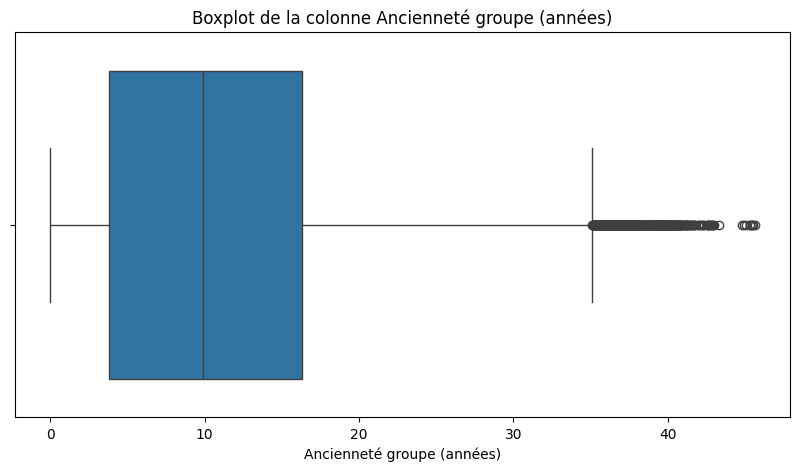

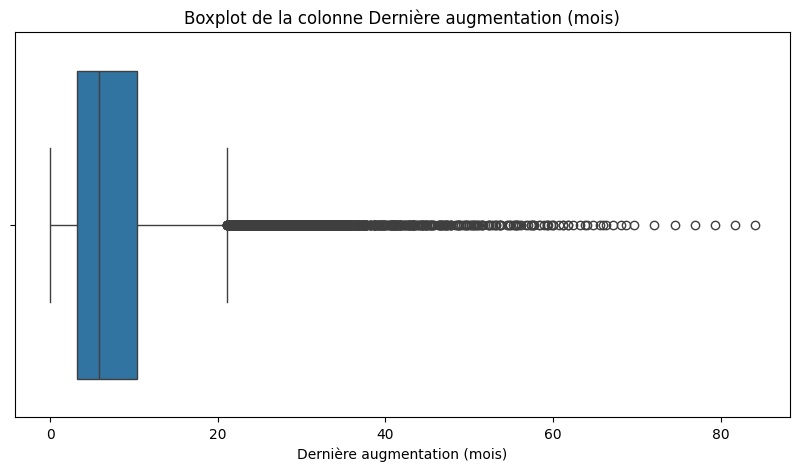

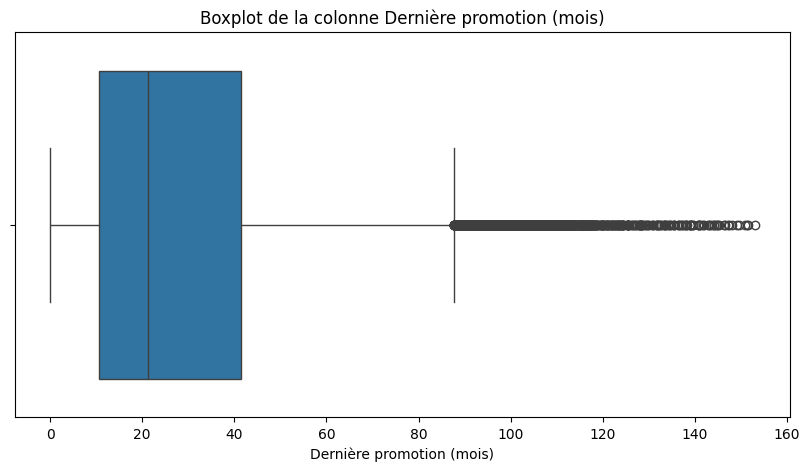

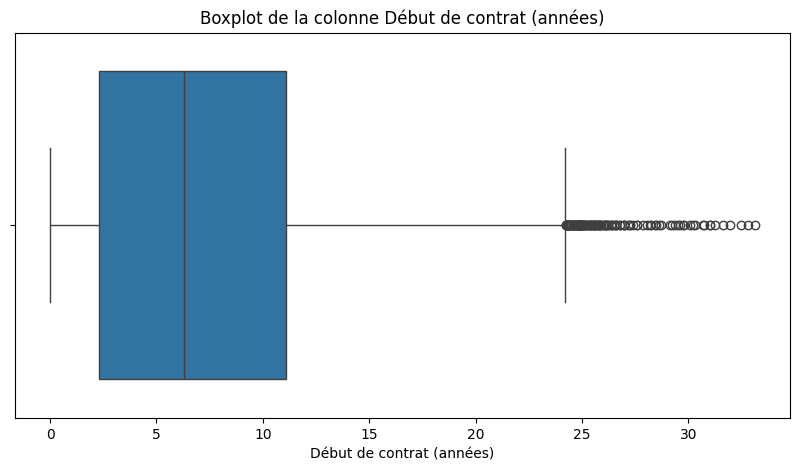

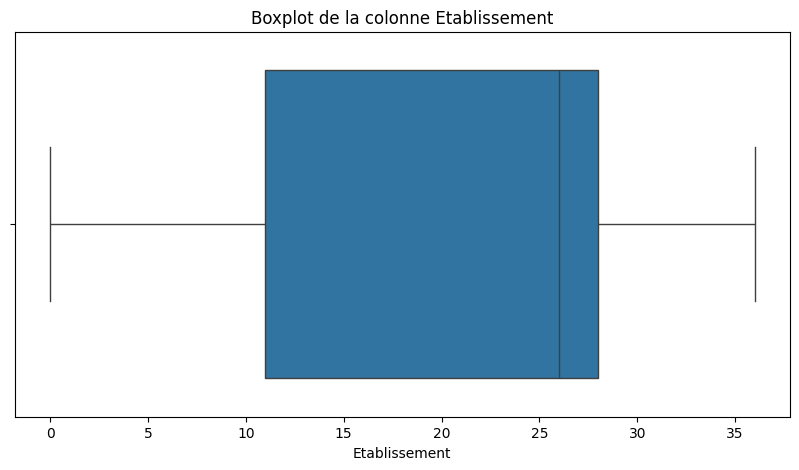

...

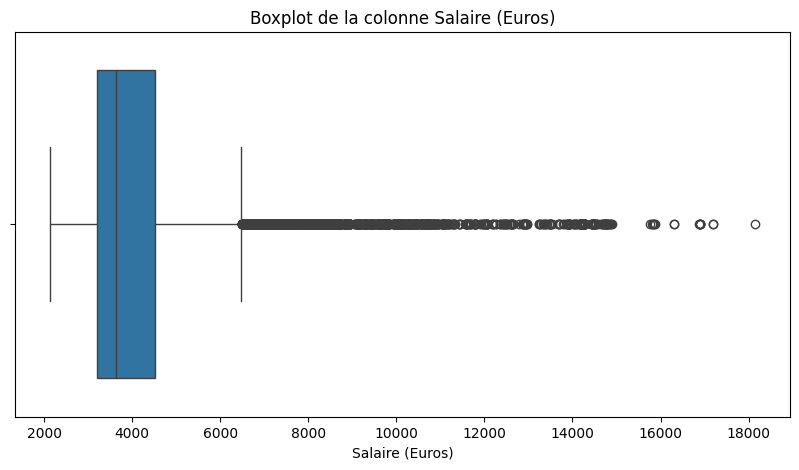

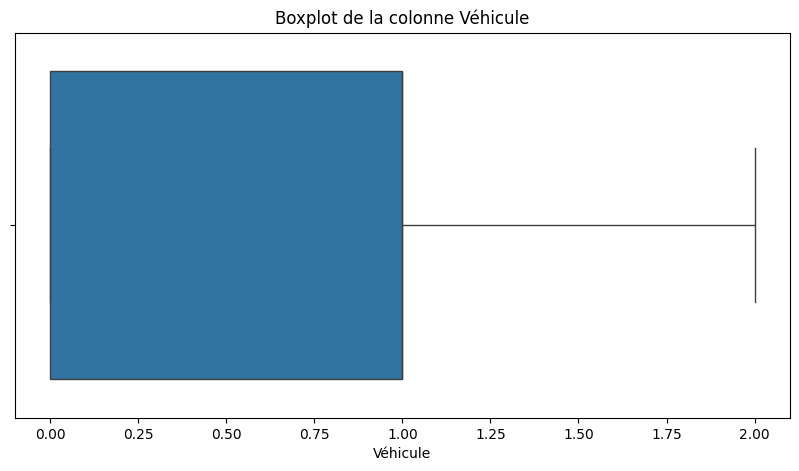

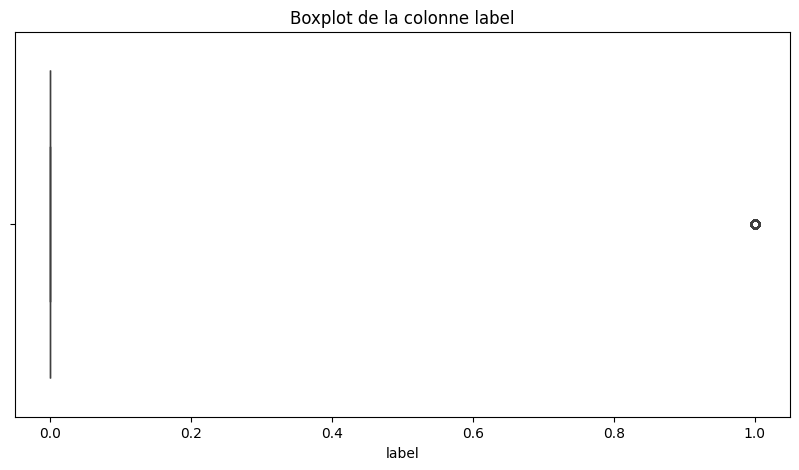

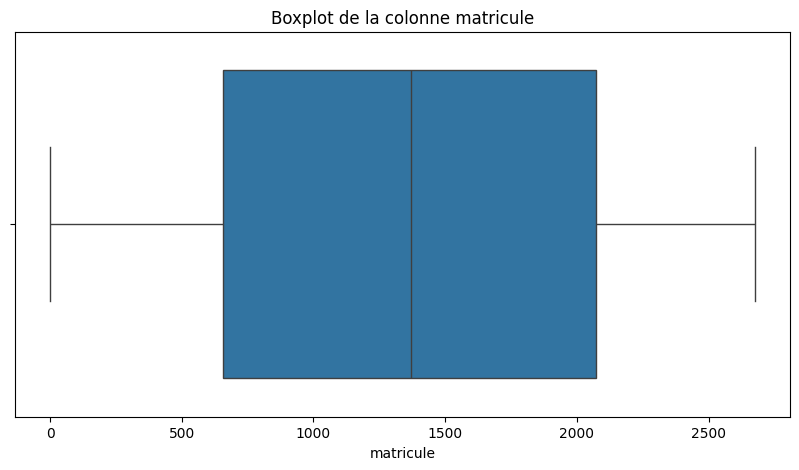

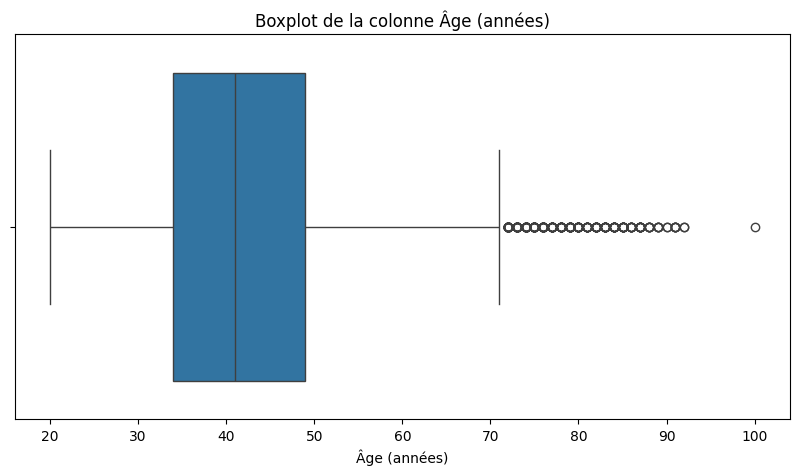

In [120]:
for col in numeric_columns:
    #boxplot
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df_rh, x=col)
    plt.title(f"Boxplot de la colonne {col}")
    plt.show()


On remarque quelques outliers

In [121]:
dictionary_min_max_columns:Dict[str,Tuple[int,int]] = {}

for col in numeric_columns:
    print("la valeur max dela colone",col,"est de",df_rh[col].max()
          ,"et la valeur min est de",df_rh[col].min())
    dictionary_min_max_columns[col]=(df_rh[col].min(),df_rh[col].max())
    
    

la valeur max dela colone Ancienneté groupe (années) est de 45.619998931884766 et la valeur min est de 0.0
la valeur max dela colone Dernière augmentation (mois) est de 84.05000305175781 et la valeur min est de 0.0
la valeur max dela colone Dernière promotion (mois) est de 152.97000122070312 et la valeur min est de 0.0
la valeur max dela colone Début de contrat (années) est de 33.119998931884766 et la valeur min est de 0.0
la valeur max dela colone Etablissement est de 36 et la valeur min est de 0
la valeur max dela colone Niveau hiérarchique est de 4 et la valeur min est de 1
la valeur max dela colone Parent est de 1 et la valeur min est de 0
la valeur max dela colone Salaire (Euros) est de 18137 et la valeur min est de 2134
la valeur max dela colone Véhicule est de 2 et la valeur min est de 0
la valeur max dela colone label est de 1 et la valeur min est de 0
la valeur max dela colone matricule est de 2675 et la valeur min est de 0
la valeur max dela colone Âge (années) est de 100 et 

In [122]:
print(dictionary_min_max_columns)

{'Ancienneté groupe (années)': (np.float64(0.0), np.float64(45.619998931884766)), 'Dernière augmentation (mois)': (np.float64(0.0), np.float64(84.05000305175781)), 'Dernière promotion (mois)': (np.float64(0.0), np.float64(152.97000122070312)), 'Début de contrat (années)': (np.float64(0.0), np.float64(33.119998931884766)), 'Etablissement': (np.int64(0), np.int64(36)), 'Niveau hiérarchique': (np.int64(1), np.int64(4)), 'Parent': (np.int64(0), np.int64(1)), 'Salaire (Euros)': (np.int64(2134), np.int64(18137)), 'Véhicule': (np.int64(0), np.int64(2)), 'label': (np.int64(0), np.int64(1)), 'matricule': (np.int64(0), np.int64(2675)), 'Âge (années)': (np.int64(20), np.int64(100))}


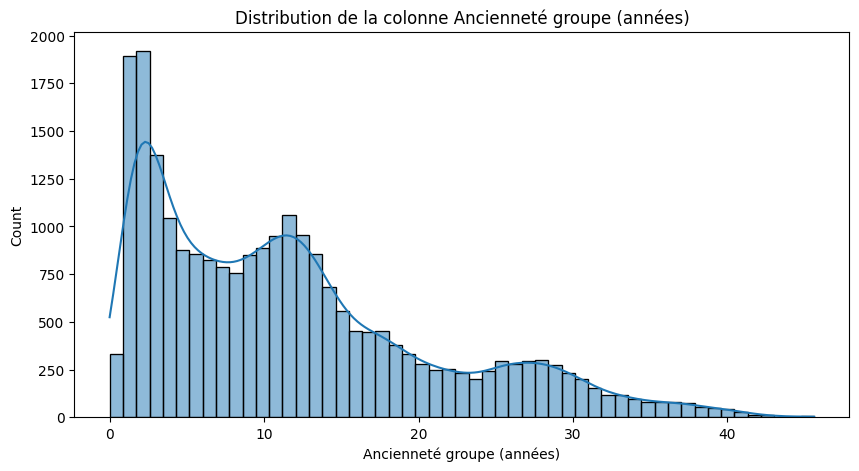

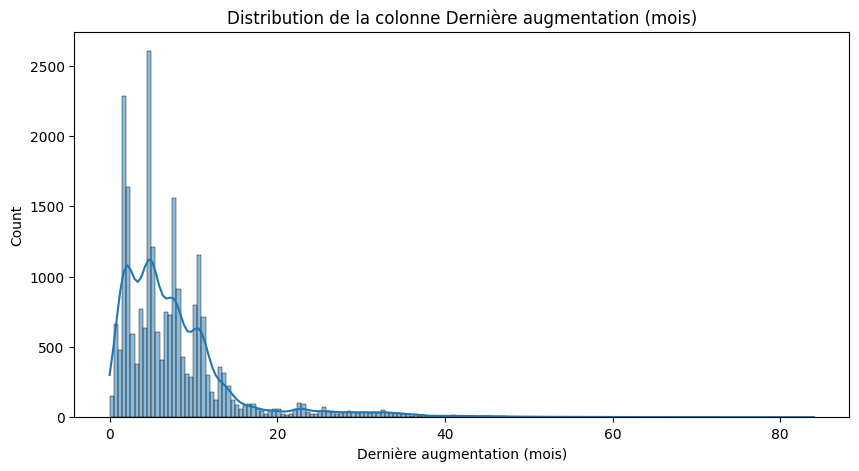

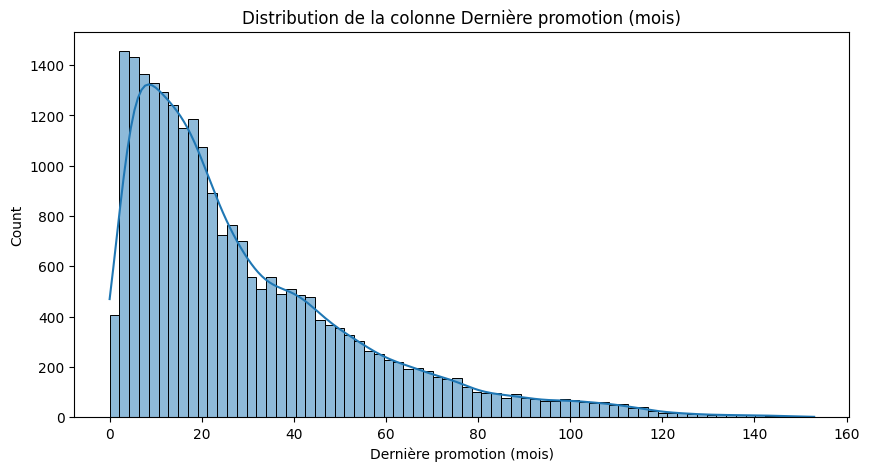

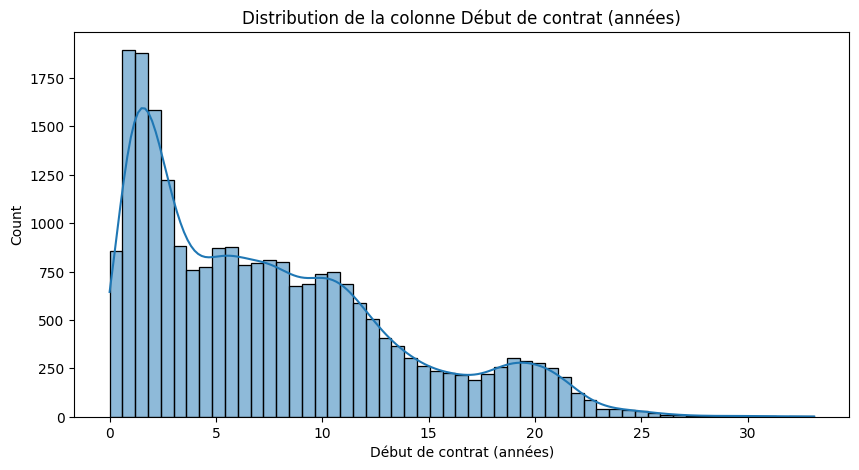

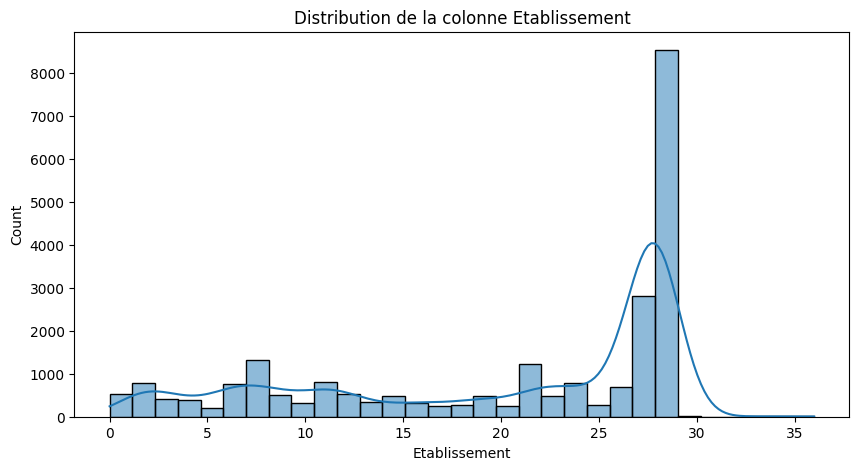

...

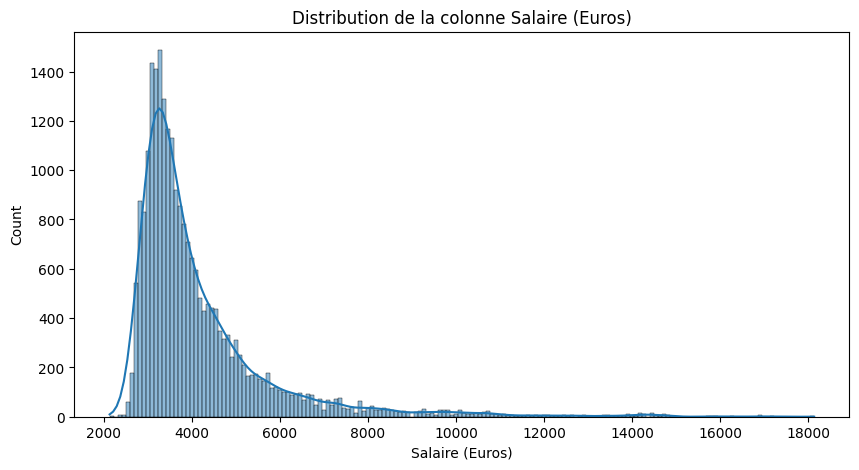

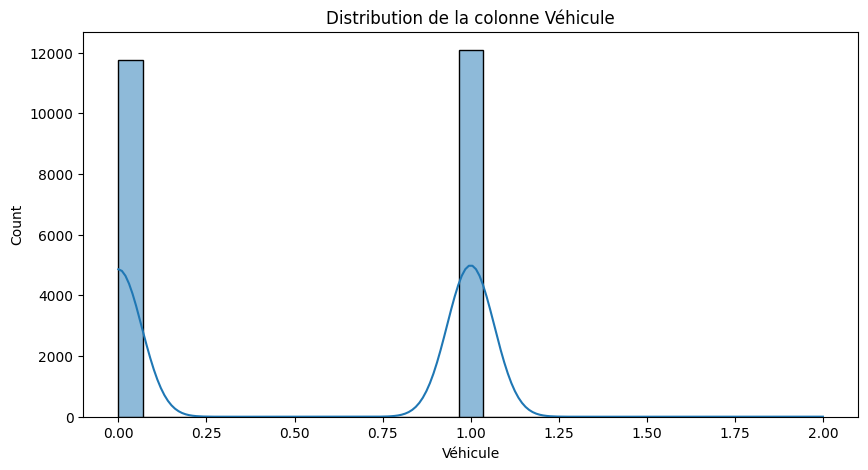

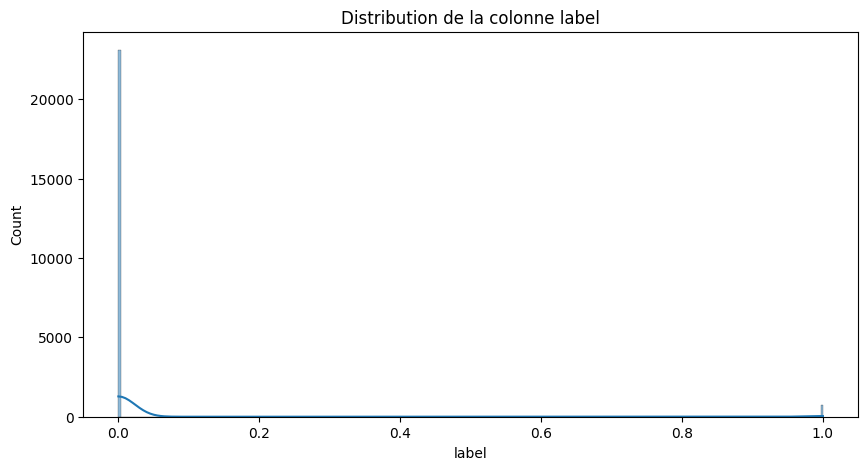

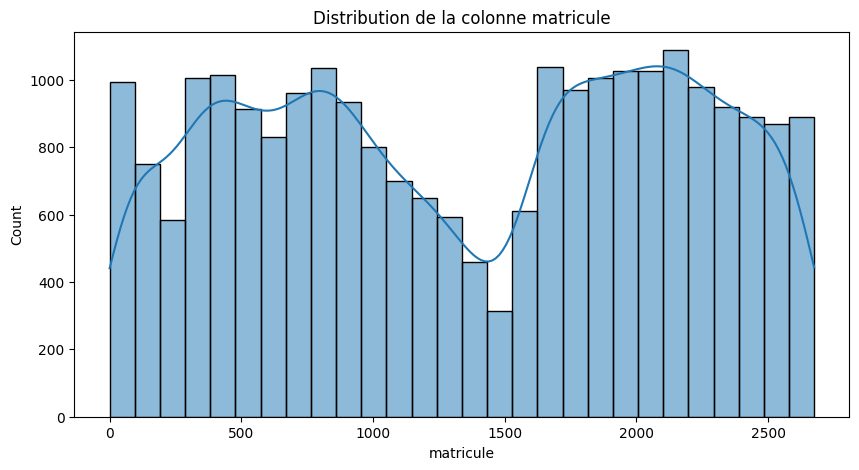

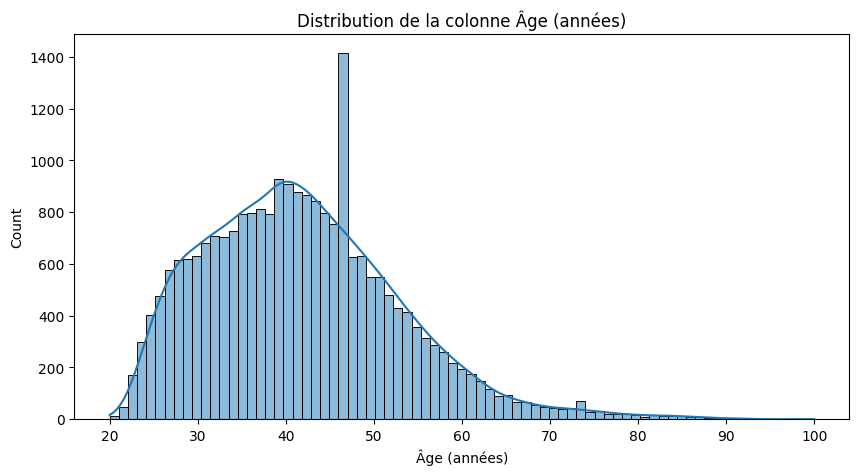

In [123]:
for col in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df_rh[col], kde=True)
    plt.title(f"Distribution de la colonne {col}")
    plt.show()

On remarque que certaines colones sont continues et d'autres sont didcrètes. Les colones discrètes sont:
- Etablissement
- label (forcément)
- véhicule
- Parent
- Niveau hierarchique  

donc:

In [124]:
discrete_columns: List[str] = ['Etablissement', 'label', 'Véhicule', 'Parent', 'Niveau hiérarchique']
df_rh[discrete_columns].nunique()

Etablissement          35
label                   2
Véhicule                3
Parent                  2
Niveau hiérarchique     4
dtype: int64

In [125]:
continus_columns:List[str] = [col for col in numeric_columns if col not in discrete_columns]
continus_columns

['Ancienneté groupe (années)',
 'Dernière augmentation (mois)',
 'Dernière promotion (mois)',
 'Début de contrat (années)',
 'Salaire (Euros)',
 'matricule',
 'Âge (années)']

Regardons les deux types de colones séparément:

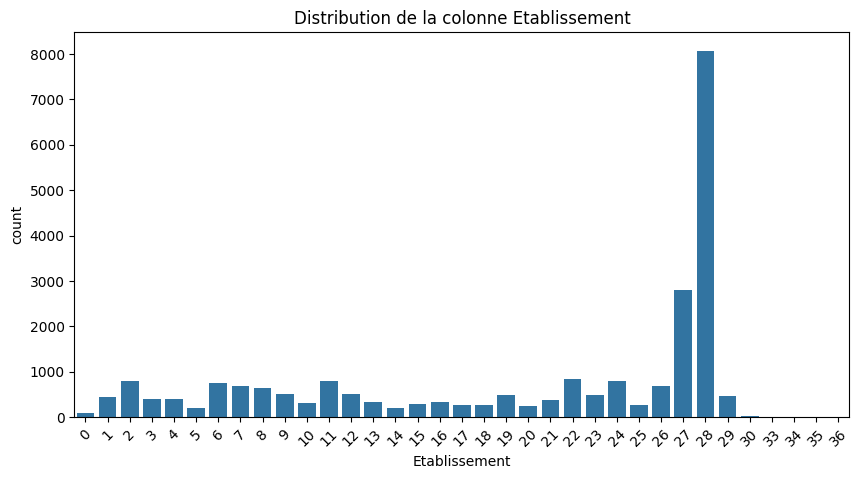

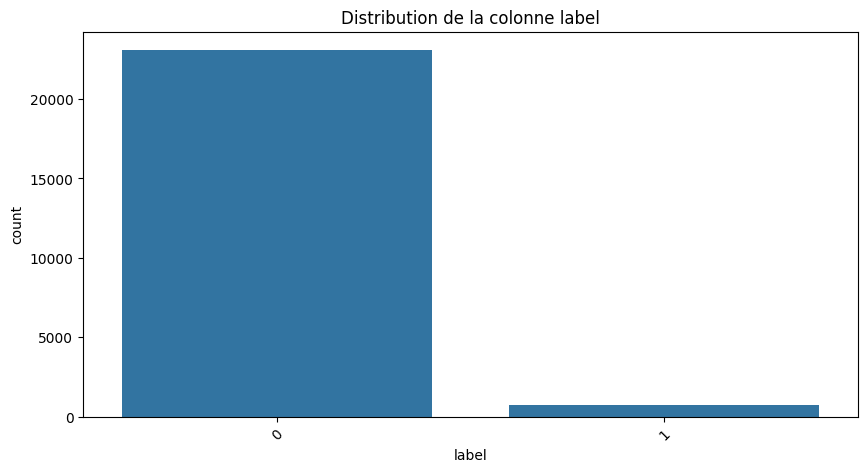

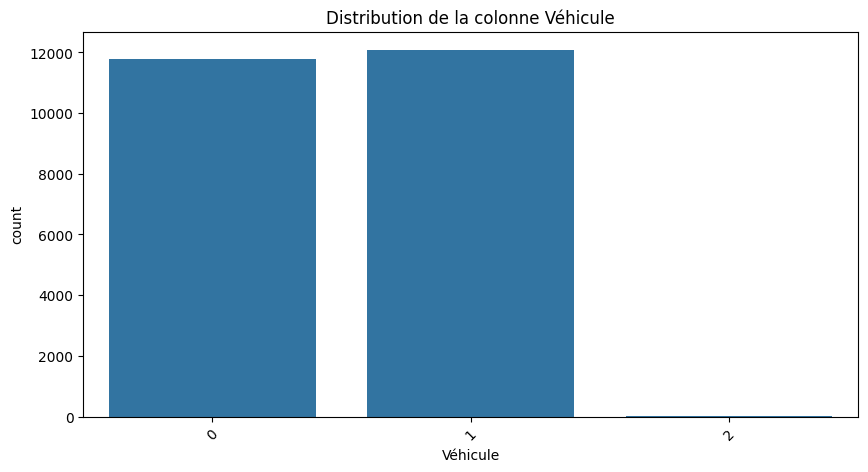

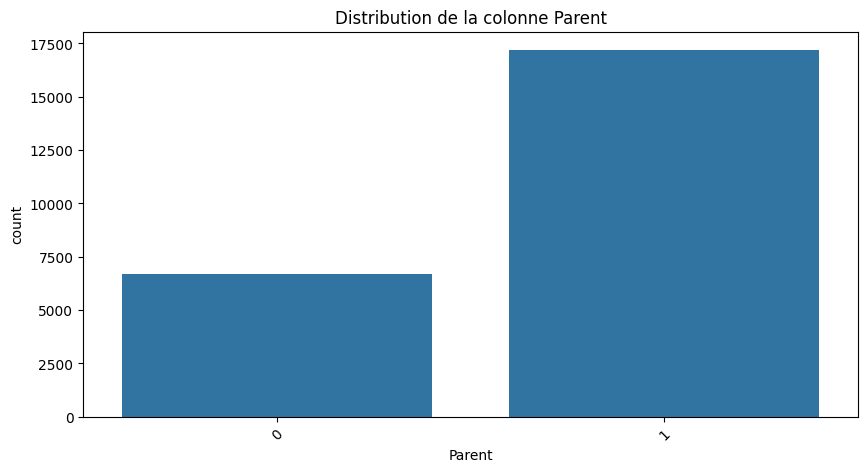

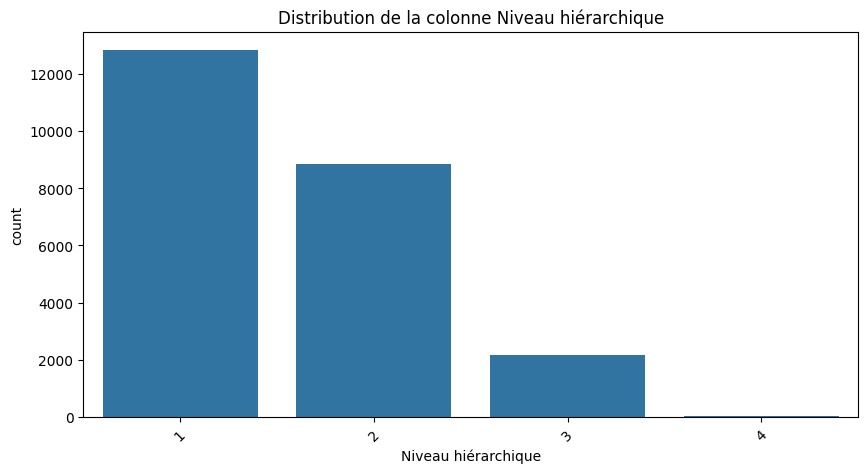

In [126]:
#plot des colones discrètes
for col in discrete_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df_rh, x=col)
    plt.title(f"Distribution de la colonne {col}")
    plt.xticks(rotation=45)
    plt.show()

L'analyse de la distribution de ces colonnes nous indique que :

* La colonne **Niveau hiérarchique** suit une structure pyramidale très marquée : une grande majorité se trouve au niveau **1** (plus de 12 000), le volume diminue d'un tier pour le niveau **2**, devient faible pour le niveau **3** et est quasi inexistant pour le niveau **4**.
* La colonne **Etablissement** montre une répartition très inégale. Alors que la plupart des établissements ont un effectif faible et stable (entre 200 et 800), l'établissement **28** se détache de manière spectaculaire avec plus de 8 000 individus, suivi de loin par le **27**. C'est clairement le site majeur de l'organisation.
* La colonne **Parent** est binaire, avec une nette majorité d'individus identifiés par le label **1** (plus de 17 000) contre environ 6 500 pour le label **0**.
* La colonne **Véhicule** est presque équitablement répartie entre les catégories **0** et **1** (autour de 12 000 chacune), tandis que la catégorie **2** est marginale.
* La colonne **label** (qui semble être notre variable cible) présente un **fort déséquilibre de classe** : la quasi-totalité des données appartient à la classe **0** (plus de 20 000), alors que la classe **1** est très minoritaire (moins de 1 000). Cela suggère un événement rare à prédire.


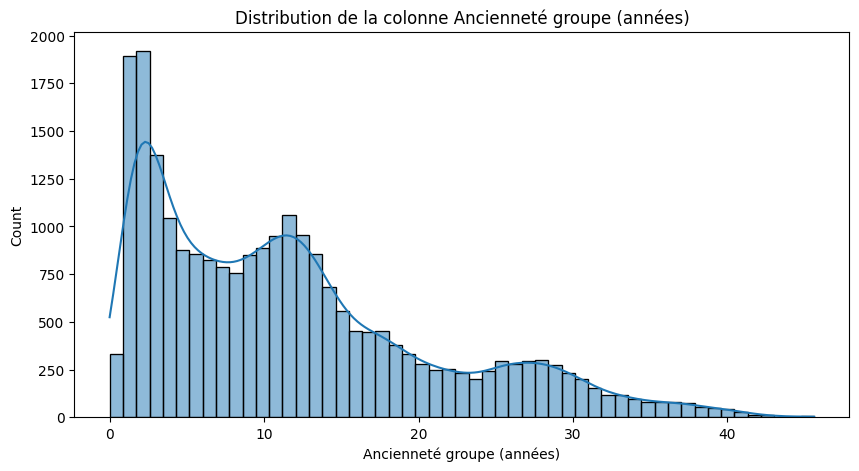

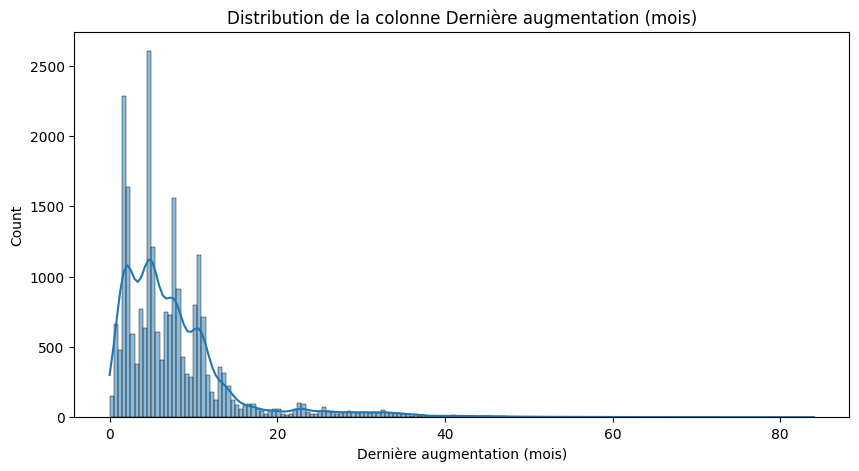

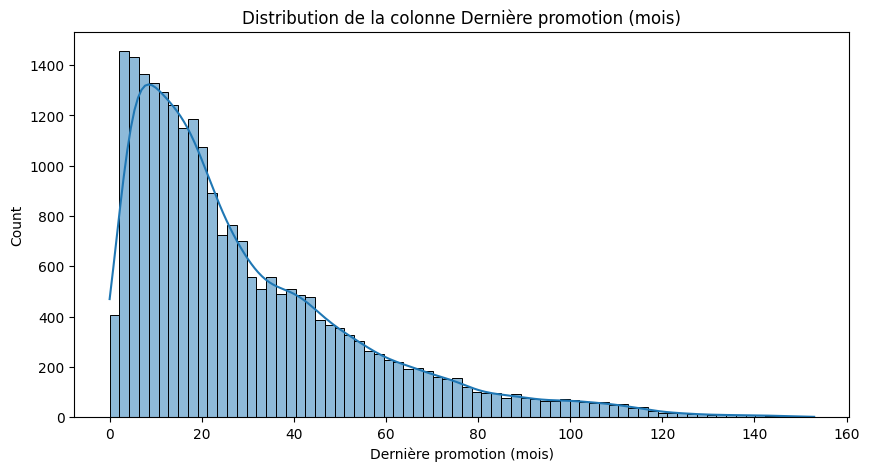

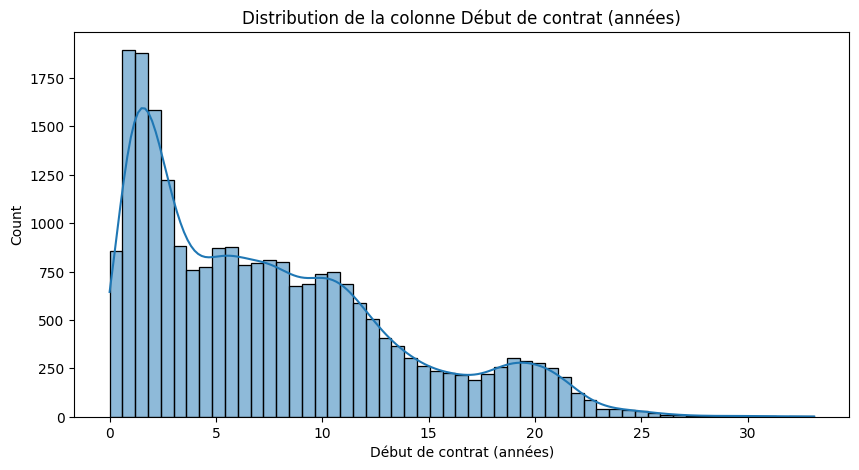

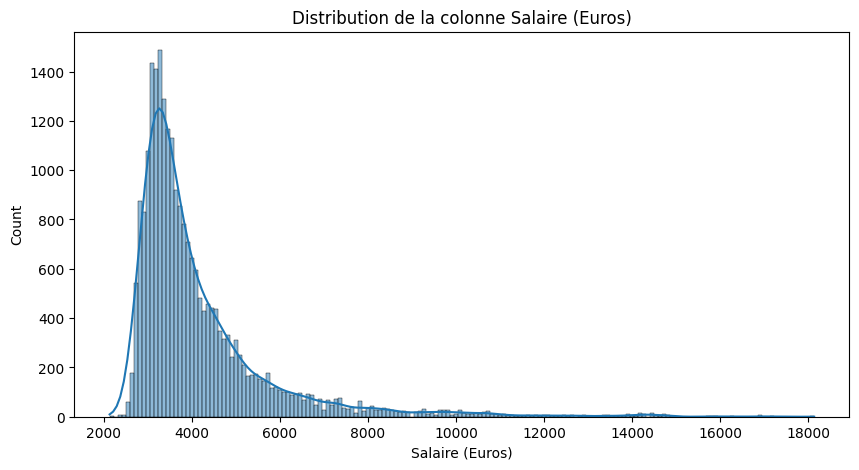

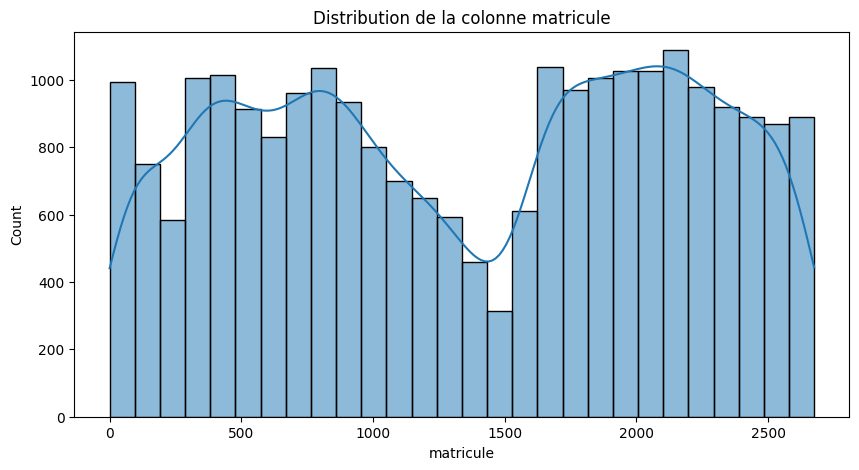

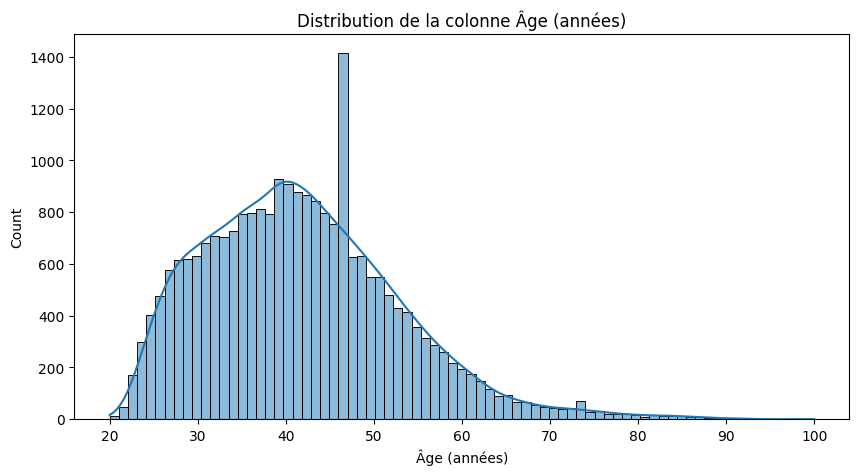

In [127]:
#plot des colones continues
for col in continus_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df_rh[col], kde=True)
    plt.title(f"Distribution de la colonne {col}")
    plt.show()

L'analyse de la distribution des colones continues nous indique que:
- La colone **Ancienneté du groupe** a une distribution un peu asymétrique avec une majorité ayant une ancienneté de 0 à 15 ans et une minorité ayant une ancienneté de 15 à 30 ans. Il y a aussi quelques outliers avec une ancienneté de plus de 30 ans.
- La colone **dernière augmentation** a une distribution très asymétrique avec une majorité ayant une dernière augmentation de 0 à 15 mois et une minorité ayant une dernière augmentation plus loin.
- La colone **dernière promotion** a une distribution très asymétrique avec une majorité ayant une dernière promotion de 0 à 20 mois et une minorité ayant une dernière promotion plus loin.
- La colone **début de contrat** a une distribution assez constanteentre 5 et 10 ans, un pic entre 0 et 5 ans et une minorité ayant un début de contrat de plus de 10 ans.
- La colone **Salaire** a une distribution très asymétrique avec une majorité ayant un salaire de 0 à 50k et une minorité ayant un salaire plus élevé.
- La colone **matricule** est plus ou moins constante d'ailleurs je vois mal l'utilité de cette colone.
- La colone **d'âge** est une belle gaussienne avec une moyenne d'environ 40 mais avec un pics au alentour de 46 ans ce qui est étranges (on va investiguer)



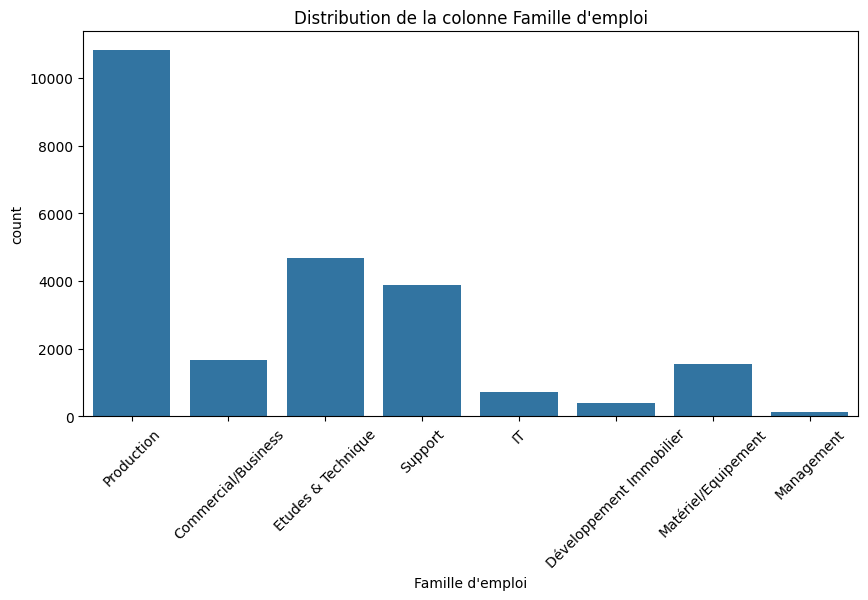

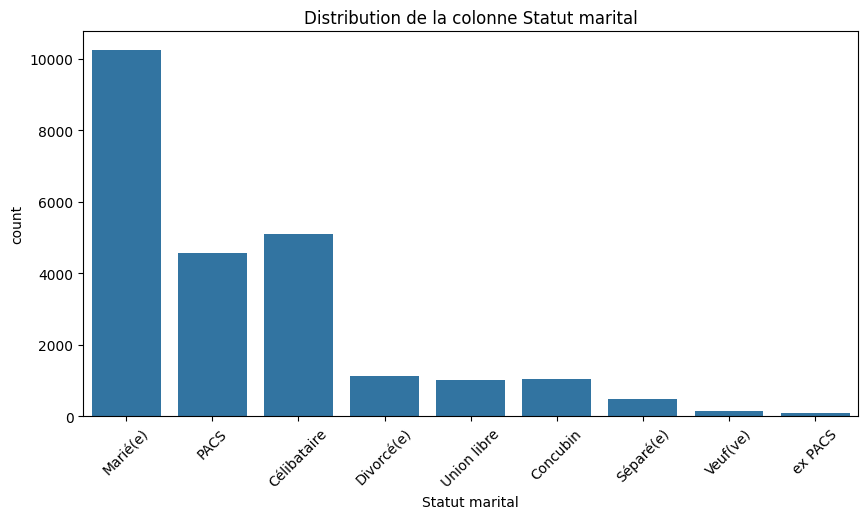

In [128]:
#plot colones str
for col in str_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df_rh, x=col)
    plt.title(f"Distribution de la colonne {col}")
    plt.xticks(rotation=45)
    plt.show()

- La colonne **Statut marital** présente une forte concentration sur le profil Marié(e) (plus de 10 000 individus), suivi par les Célibataires et les PACS qui tournent autour de 4 500 à 5 000. Les autres catégories (Divorcé, Union libre, etc.) sont très minoritaires, avec moins de 1 000 individus chacune.

- La colonne **Famille d'emploi** est dominée de façon écrasante par la catégorie Production (plus de 10 000 individus), ce qui suggère un profil d'entreprise très opérationnel ou industriel.

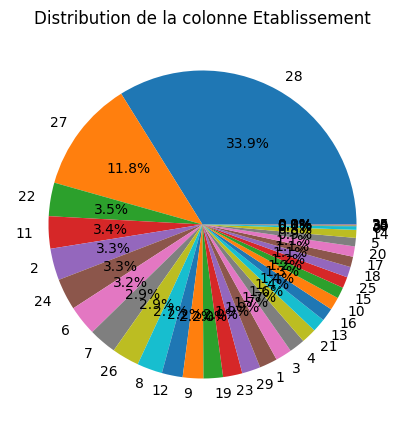

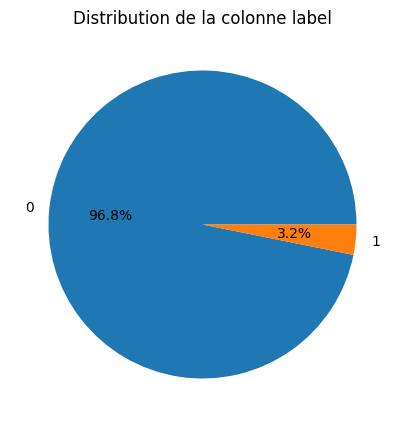

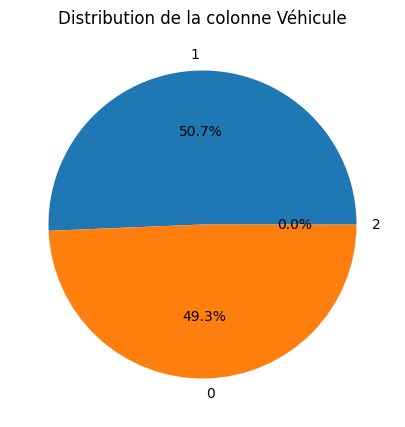

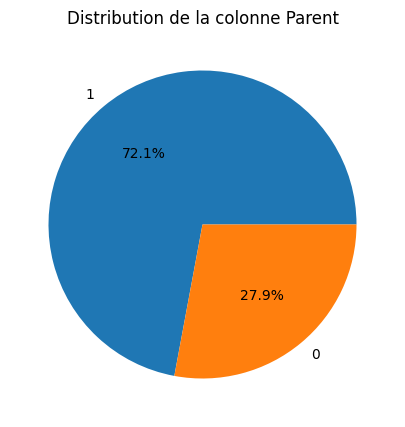

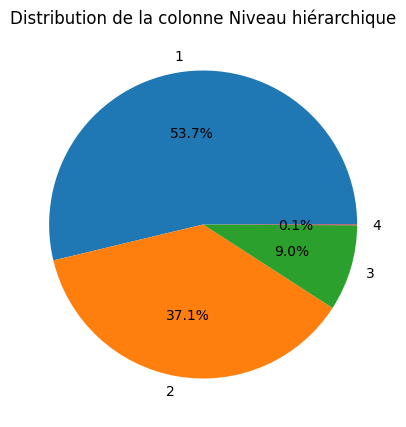

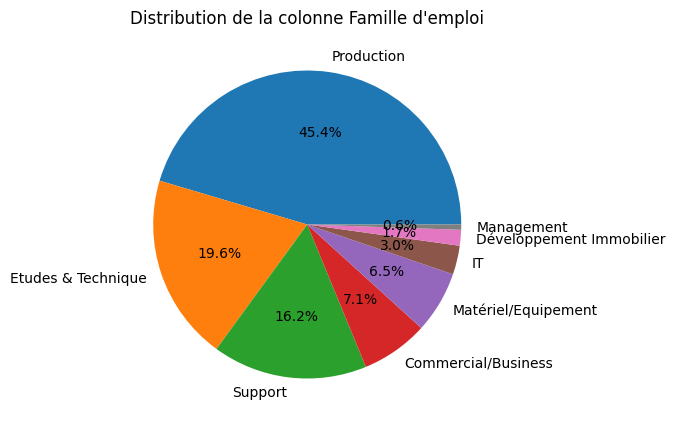

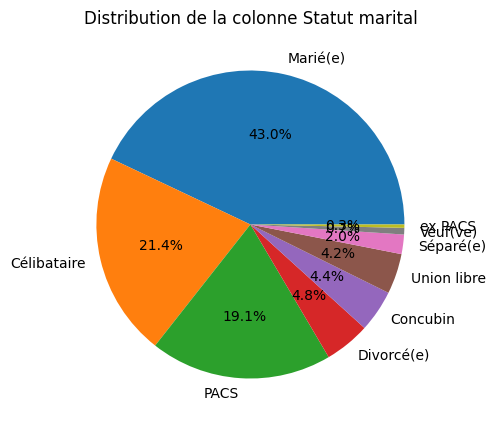

In [129]:
#plot pie chart pour les colones discrètes et str
for col in discrete_columns+str_columns:
    plt.figure(figsize=(10,5))
    df_rh[col].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(f"Distribution de la colonne {col}")
    plt.ylabel('')
    plt.show()

essayons deux méthodes:
- label encoding
- one hot encoding

In [130]:
#Label encoding pour les colones str
dict_label_encoding = {}
for col in str_columns:
    df_rh[col] = df_rh[col].astype('category')
    dict_label_encoding[col] = dict(enumerate(df_rh[col].cat.categories))
    df_rh[col] = df_rh[col].cat.codes
dict_label_encoding

{"Famille d'emploi": {0: 'Commercial/Business',
  1: 'Développement Immobilier',
  2: 'Etudes & Technique',
  3: 'IT',
  4: 'Management',
  5: 'Matériel/Equipement',
  6: 'Production',
  7: 'Support'},
 'Statut marital': {0: 'Concubin',
  1: 'Célibataire',
  2: 'Divorcé(e)',
  3: 'Marié(e)',
  4: 'PACS',
  5: 'Séparé(e)',
  6: 'Union libre',
  7: 'Veuf(ve)',
  8: 'ex PACS'}}

In [131]:
df_rh[str_columns].nunique()

Famille d'emploi    8
Statut marital      9
dtype: int64

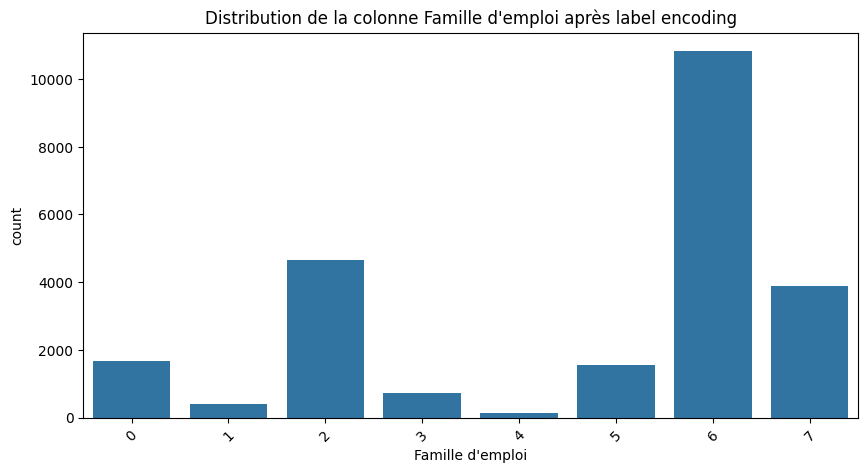

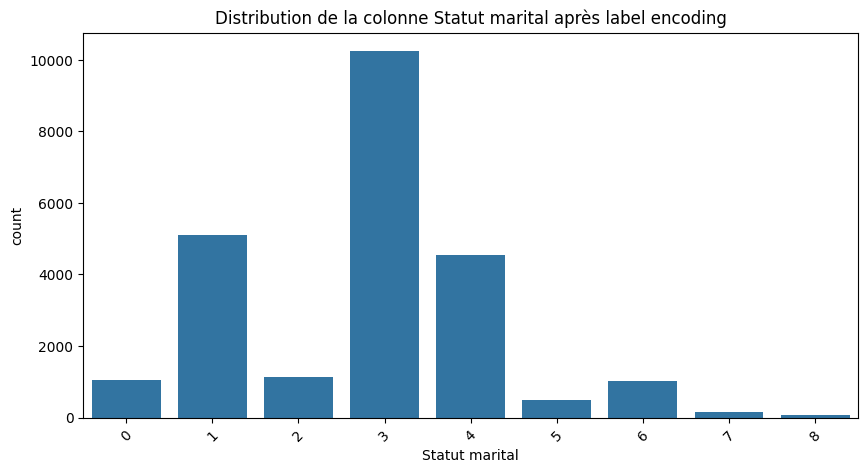

In [132]:
for col in str_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df_rh, x=col)
    plt.title(f"Distribution de la colonne {col} après label encoding")
    plt.xticks(rotation=45)
    plt.show()

### Parcours d'une personne qui a démissionné et une personne qui n'a pas démissionné

Exhibons le chemin d'une personne qui a démissionné et une personne qui n'a pas démissionné pour voir les différences entre les deux.

### Correlation entre les différentes colones

Premièrement, on va faire la correlation entre les différentes colones pour voir si il y a des colones qui sont fortement corrélées entre elles. Si c'est le cas, on pourra peut-être supprimer une de ces colones pour éviter la multicolinéarité.

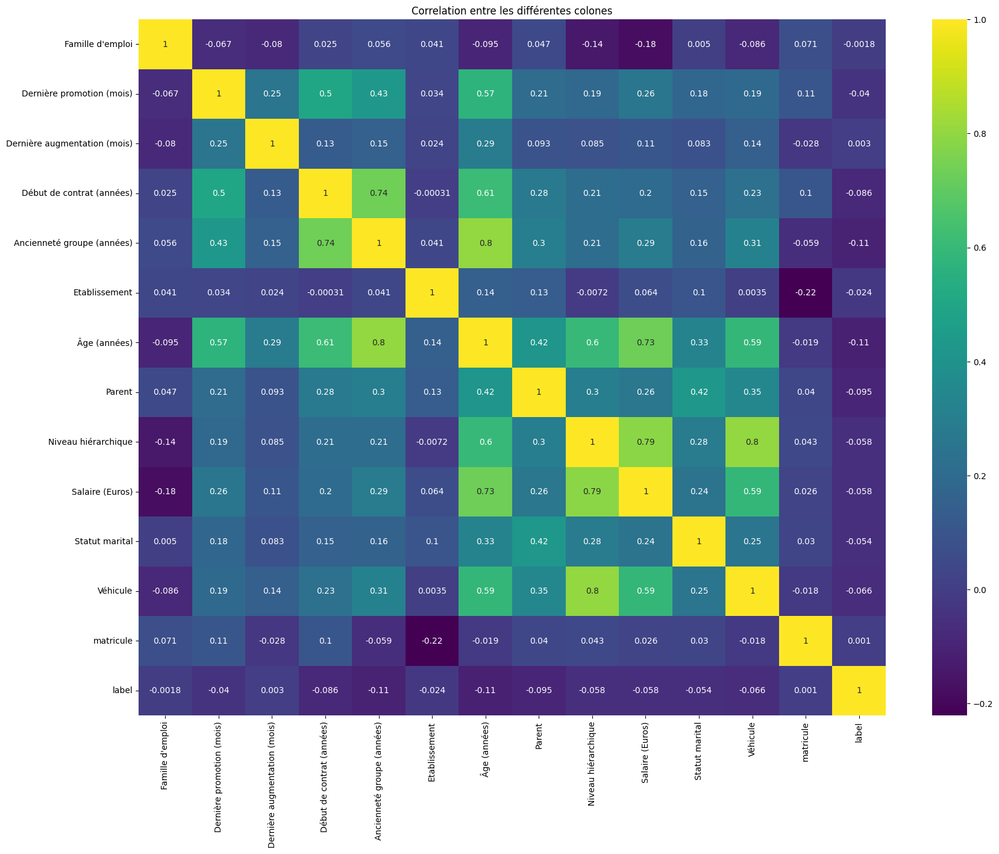

In [133]:
plt.figure(figsize=(20,15))
sns.heatmap(df_rh.corr(), annot=True, cmap='viridis')
plt.title("Correlation entre les différentes colones")
plt.show()

<Axes: >

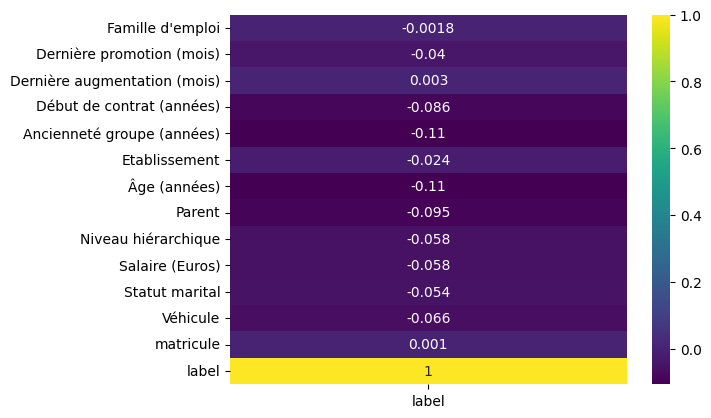

In [134]:
sns.heatmap(df_rh.corr()[['label']], annot=True, cmap='viridis')

### La relation avec la cible ("label")

D'après la deuxième image (le zoom sur la colonne `label`), on observe quelque chose de frappant : **aucune variable n'est fortement corrélée avec le label.**

* Les corrélations oscillent entre **-0,11** (Ancienneté groupe et Âge) et **0,071** (Famille d'emploi).
* **Interprétation :** Cela signifie qu'aucune variable prise isolément ne peut prédire linéairement le `label`.

### Les fortes corrélations (Multicolinéarité)

* **Le bloc de carrière :**
* **Âge & Ancienneté groupe (0,80) :** Très forte corrélation logique (plus on est âgé, plus on a tendance à avoir de l'ancienneté).
* **Début de contrat & Ancienneté (0,74) :** Ces deux variables mesurent quasiment la même chose.


* **Le bloc de statut hiérarchique :**
* **Niveau hiérarchique & Salaire (0,79) :** Sans surprise, plus le niveau est élevé, plus le salaire l'est.
* **Niveau hiérarchique & Véhicule (0,80) :** Indique souvent que le véhicule de fonction est un avantage lié au rang.
* **Âge & Salaire (0,73) :** Le salaire progresse avec l'expérience et l'âge.



### Les variables "neutres"

* **Matricule :** Sa corrélation avec les autres variables est proche de zéro (sauf un léger lien négatif avec l'Établissement). C'est normal, un identifiant ne devrait pas avoir de valeur prédictive. 
* **Famille d'emploi :** Très peu corrélée au reste, ce qui suggère que c'est une variable catégorielle indépendante qui apporte une information unique, même si elle est faible ici.



### Conclusion sur les labels

1. **Faible signal :** Le "label" semble difficile à prédire avec ces variables telles quelles.
2. **Nettoyage :** On a beaucoup de redondance (Âge, Ancienneté, Salaire, Niveau hiérarchique). Pour simplifier le modèle, on pourrait ne garder que les plus significatives.
3. **Feature Engineering :** Puisque les corrélations linéaires sont faibles avec le label, on peut créer de nouvelles variables (ex: ratio salaire/ancienneté) ou vérifier s'il n'y a pas des relations non-linéaires.


### Analyse supplémentaire

<Figure size 2000x1500 with 0 Axes>

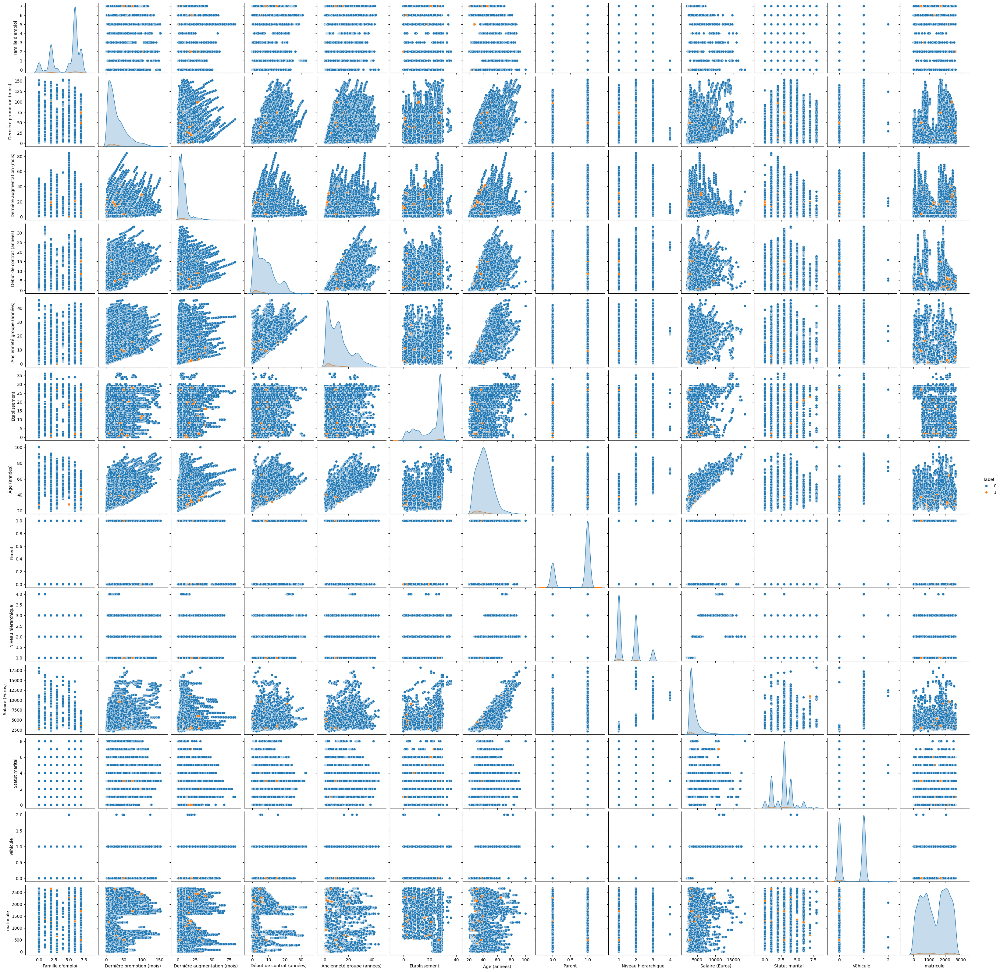

In [135]:
plt.figure(figsize=(20,15))
sns.pairplot(df_rh, hue='label', diag_kind='kde')
plt.show()

**1. Un fort déséquilibre des classes (Class Imbalance)**
La première chose qui me saute aux yeux, c'est l'omniprésence des points bleus (`label = 0`) par rapport aux points oranges (`label = 1`). C'est particulièrement visible sur les courbes de densité (sur la diagonale) : les courbes oranges sont presque plates en comparaison.

* **Mon action possible pour la suite :** Mon jeu de données est clairement déséquilibré. Si j'entraîne mon modèle directement, il risque de prédire systématiquement "0" pour avoir un bon score global. Je vais devoir appliquer des techniques de rééquilibrage, comme le sur-échantillonnage (SMOTE) ou ajuster les poids des classes dans mon algorithme.

**2. L'absence de séparation linéaire évidente**
En regardant les nuages de points (scatter plots), je cherchais à voir si certaines combinaisons de variables permettaient d'isoler la classe 1. Malheureusement, les points oranges sont complètement "noyés" au milieu des points bleus. Il n'y a pas de clusters distincts.

* **Mon action pour la suite :** Cela confirme ce que j'avais observé dans ma matrice de corrélation. Une simple régression logistique ne fonctionnera pas bien ici. Je devrai m'orienter vers des modèles capables de capter des règles non linéaires et des interactions complexes, comme les Random Forests (Forêts Aléatoires) ou XGBoost.

**3. Des distributions très asymétriques (Skewness)**
Les graphiques sur la diagonale m'indiquent que plusieurs de mes variables numériques ne suivent pas une loi normale. Par exemple, le `Salaire`, la `Dernière promotion` ou le `Début de contrat` sont très étirés vers la droite (asymétrie positive). La majorité des employés se concentrent sur des valeurs basses, avec une longue traîne vers des valeurs extrêmes.

* **Mon action possible pour la suite :** Selon le modèle que je vais choisir au final, je note qu'il sera peut-être nécessaire d'appliquer une transformation (comme le passage au logarithme) sur ces variables pour recentrer leurs distributions.

**4. Confirmation visuelle de la multicolinéarité**
Je retrouve visuellement les fortes corrélations que j'avais identifiées précédemment. Par exemple, le graphique croisant l'`Âge` et l'`Ancienneté groupe`, ou encore le `Niveau hiérarchique` et le `Salaire`, montre des alignements de points très nets, formant presque des lignes droites.

il faudra voir s'il est utile de supprimer une de ces colones


### Parcours d'un employé ayant démissionné contre un employé qui est resté dans l'entreprise,
Note : regarder la classe \"Employee\" pour le code interne de l'analyse. L'approche Notebook se concentre sur la présentation et l'analyse des résulats. Celle permet d'externalise les fonctions de plotting et traitements en présentant juste une interface plus haut niveau pour faire des comparaisons.

In [ ]:
from employee import (
    Employee, COL_MATRICULE, COL_SALARY_EUROS, COL_AGE_YEARS, COL_SENIORITY_GROUP_YEARS,
    COL_CONTRACT_START_YEARS, COL_HAS_RESIGNED, COL_CUSTOM_TIME,
)

dataset_path="Data/RH_dataset.csv"
df_career_analysis:pd.DataFrame=pd.read_csv("Data/RH_dataset.csv", delimiter=";")
df_career_analysis.sort_values(COL_SENIORITY_GROUP_YEARS).groupby(COL_MATRICULE).last().reset_index()
df_career_analysis.dtypes

In [ ]:
# Pensez à changer la seed pour obtenir des séléctions différentes !
# import random

# random.seed(1)
# np.random.seed(1)
# On récupère 2 employées aléatoirement, l'un a démissionné et l'autre non

# employee_resigned = Employee.get_random(df, has_resigned=True, name="Démissionnaire")
# employee_retained = Employee.get_random(df, has_resigned=False, name="Non-démissionnaire")

# Résulat avec la seed 1, hardcodé par matricule pour s'assurer que les explications des figures restent cohérentes
employee_resigned = Employee(df_career_analysis, matricule=216, name="Démissionnaire")
employee_retained = Employee(df_career_analysis, matricule=2057, name="Non-démissionnaire")

print(f"A démissionné   : matricule {employee_resigned.matricule} | {len(employee_resigned.df)} entrées")
print(f"Non-démissionné : matricule {employee_retained.matricule} | {len(employee_retained.df)} entrées")

### Tendance de l'employée n'ayant PAS démissionné
Note : la valeur de CUSTOM_TIME est une version calculée du temps total (en années) passé dans l'entreprise par l'employé. Son calcul se base sur l'ancienneté dans l'entreprise.

In [ ]:
employee_retained.multiplot(x=COL_CUSTOM_TIME)

In [ ]:
employee_retained.compare(employee_resigned, COL_CONTRACT_START_YEARS, show_resignations=True)

On remarque bien sûr que la carrière de l'employé qui est resté aura durée plus longtemps si on prend le temps depuis le début du contrat.

In [ ]:
employee_retained.multiplot(
     others=employee_resigned,
    x=COL_CUSTOM_TIME,
    exclude_cols=[COL_MATRICULE, COL_HAS_RESIGNED, COL_AGE_YEARS],
    show_resignations=True
)

Fait intéressant ici, en regardant Salaire (Euros) et Dernière Augmentation (mois), on peut voir que les deux employés on été augmenté à la même période, mais que l'employé ayant démissionné est payé nettement moins, et son augementation était bien plus faible également. Il a démissionné peu après. Il est plausible que la faiblesse de cette augmentation soit la raison de la démission.

In [ ]:
employee_retained.compare(
    others=employee_resigned,
    column=COL_SALARY_EUROS,
    x=COL_CUSTOM_TIME,
    show_resignations=True
)

### Comparaison par moyenne (cohort) pour discerner des tendances
Faisons une comparaison par moyenne pour discerner des tendances notables entre les carrières démissionnaires et non-démissionnaires. ATTENTION, notre effectif ici est trés variable, il y aura par exemple peu de démissionnaires avec une longue carrière, et la moyenne ne sera donc pas diluée par un grand effectifs.

In [ ]:
Employee.cohort_multiplot(df_career_analysis, order_by=COL_CUSTOM_TIME)

Les démissionnaires forment un profil cohérent : employé plutôt milieu de carrière (35–45 ans), entré récemment, bloqué hiérarchiquement (niveau 1.0–1.5, environ 4 000€), sans augmentation (environ 25 mois) ni promotion (environ 30 mois). Le départ survient quasi systématiquement dans les 18 premiers mois !
Colonnes importantes :
- Dernière augmentation : pic à ~25 mois sans augmentation, variable probablement la plus discriminante
- Dernière promotion : ~30 mois sans évolution au moment du départ
- Parent : pic de démission à Parent=1 vers 0.5 an, possiblement une réévaluation des priorités
- Niveau & Salaire : stagnation totale chez les démissionnaires vs progression continue en poste
- On voit plutôt un problème d'adéquation entre les attentes à l'embauche et la réalité du poste, plutôt qu'un désengagement progressif de l'employé

## 2. Analyse des variables sensibles et biais potentiels


Certaines variables sont sensibles, et risque d'être utilisées comme proxy.
- Âge : variable directement protégée par le Code du travail. Ne peut pas légalement motiver une décision RH.
- Parent : proxy du genre : risque avec les congés parentaux rend cette variable corrélée au sexe féminin. C'est une forte source de biais d'embauche et pour l'évolution de carrière.
- Salaire : proxy du genre et de l'origine via les inégalités salariales structurelles. Encoder le salaire, c'est encoder indirectement ces caractéristiques protégées.
- Niveau hiérarchique : proxy du genre et de l'origine. Les niveaux élevés sont statistiquement moins accessibles à certains groupes, ce biais se retrouve dans la variable  par défaut.
- Ancienneté groupe : proxy de l'âge et du genre. Les interruptions de carrière (congé maternité notamment) créent des zones qui discriminent indirectement.

## 3. Apprentissage automatique

pour traiter les valeur numérique continue on va les standardiser pour les mettre à la même échelle. Pour les colones catégorielles, on va utiliser du one hot encoding pour les transformer en variables numériques.

### Préparation dataset

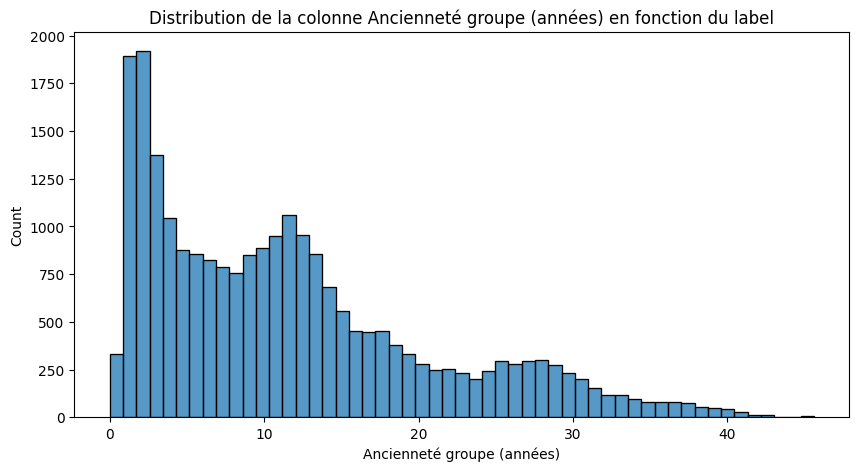

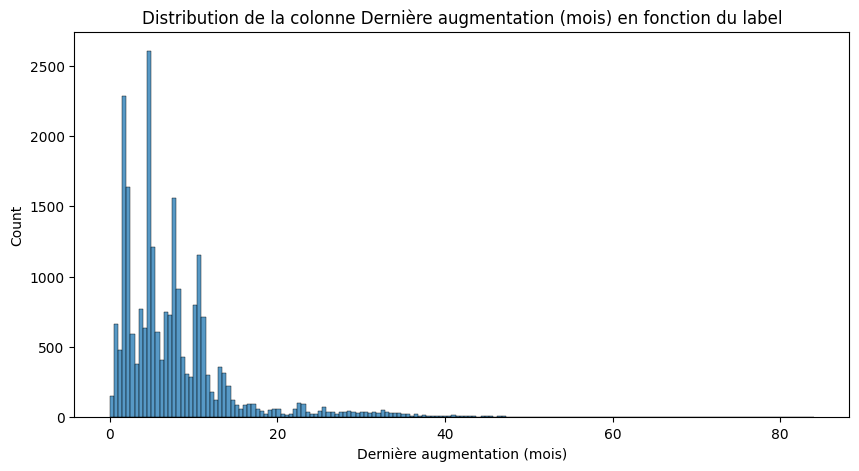

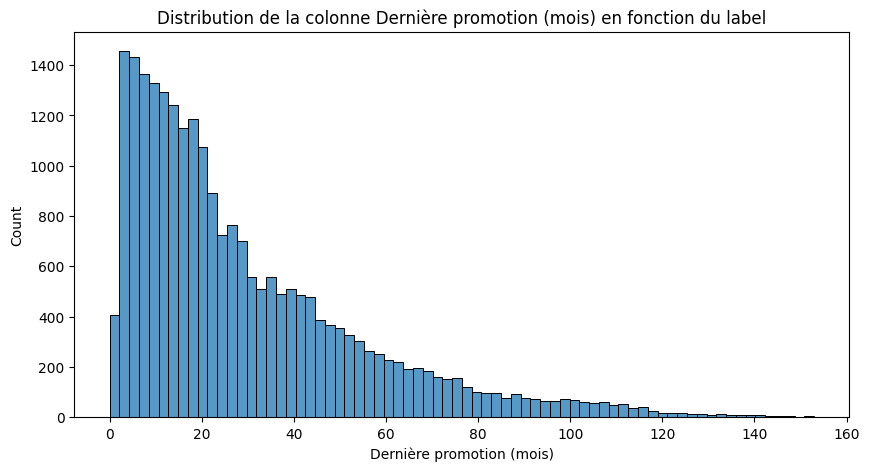

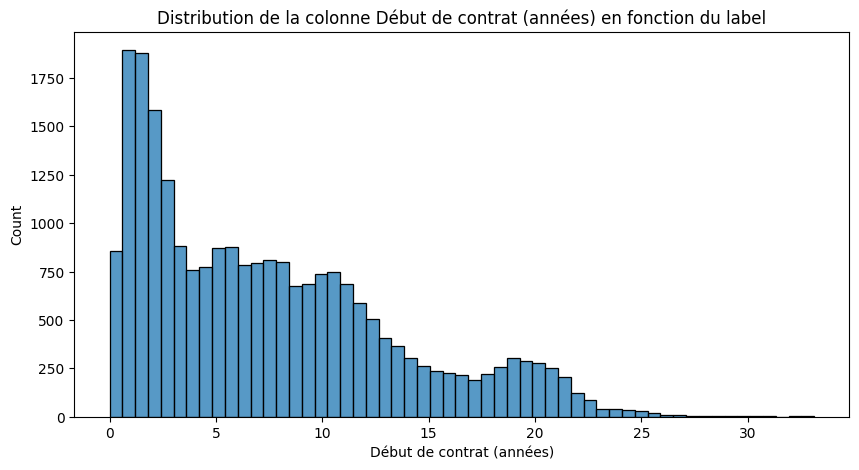

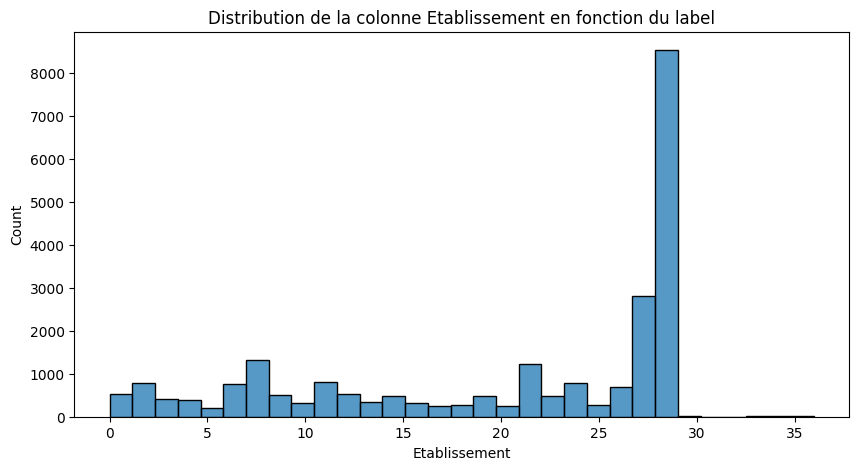

...

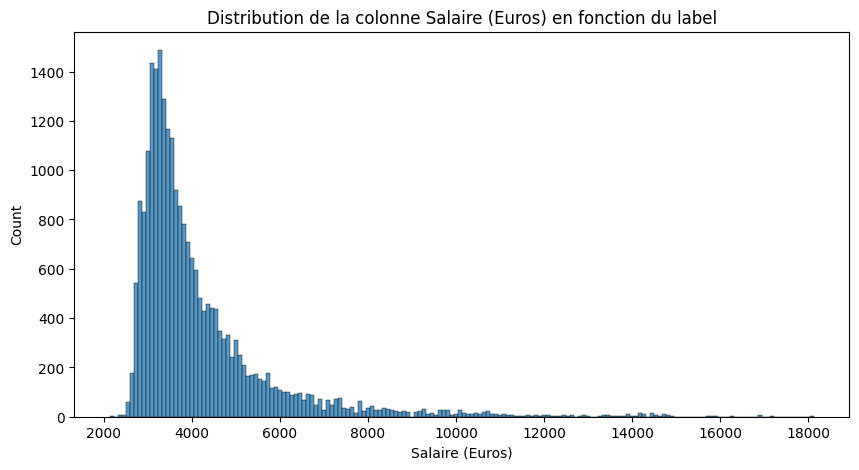

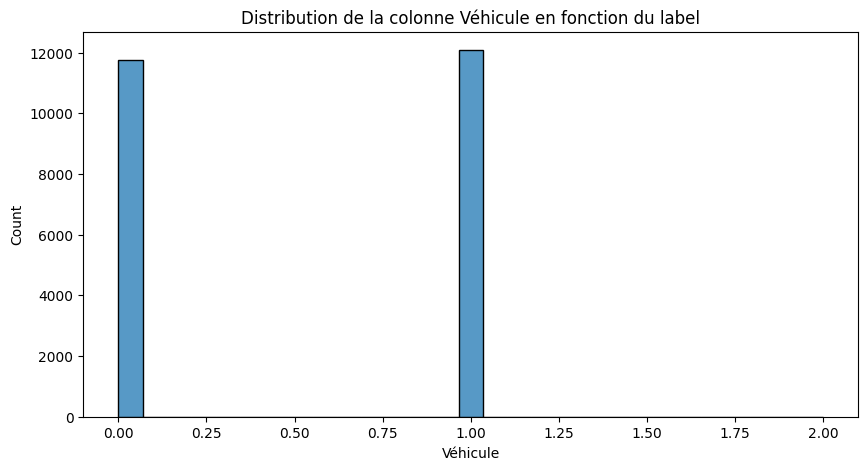

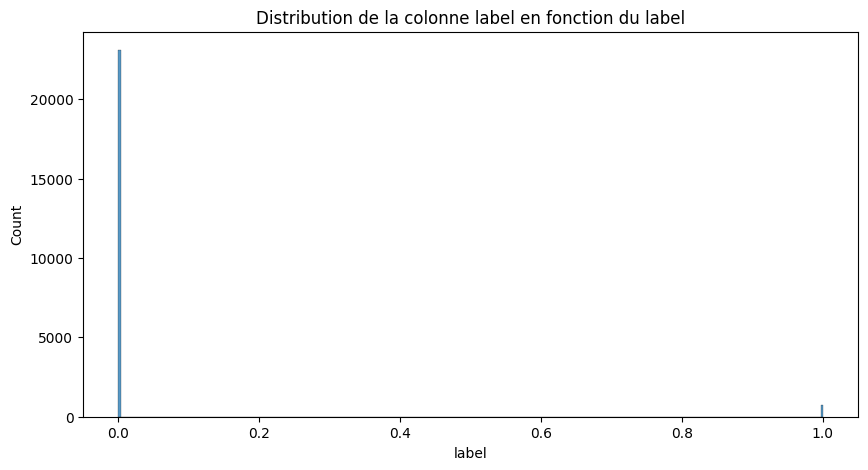

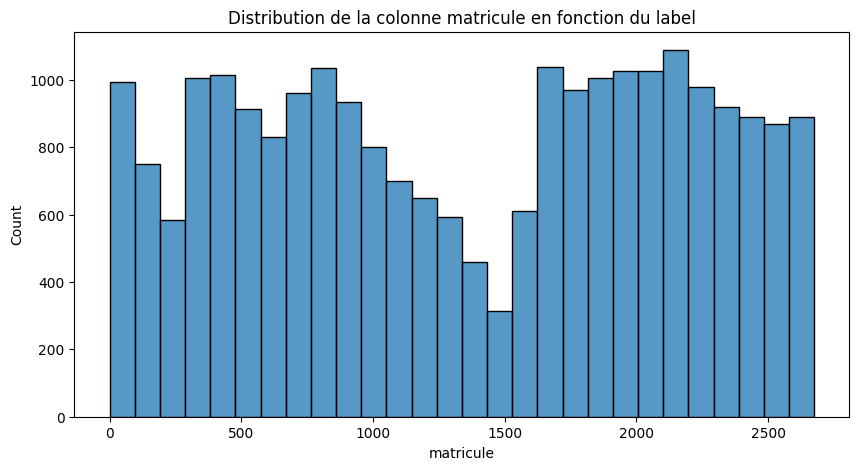

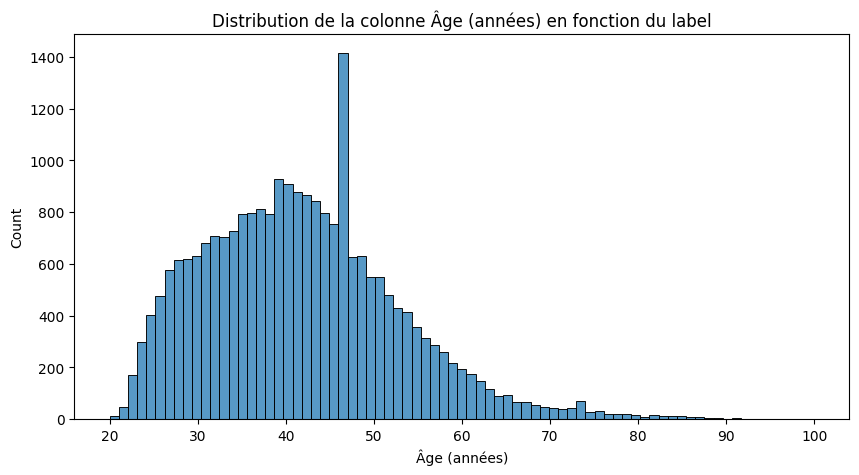

In [136]:
#plot distribution de la colone des colones
for col in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df_rh[col])
    plt.title(f"Distribution de la colonne {col} en fonction du label")
    plt.show()

In [137]:
print(continus_columns)

['Ancienneté groupe (années)', 'Dernière augmentation (mois)', 'Dernière promotion (mois)', 'Début de contrat (années)', 'Salaire (Euros)', 'matricule', 'Âge (années)']


In [138]:
print(discrete_columns)

['Etablissement', 'label', 'Véhicule', 'Parent', 'Niveau hiérarchique']


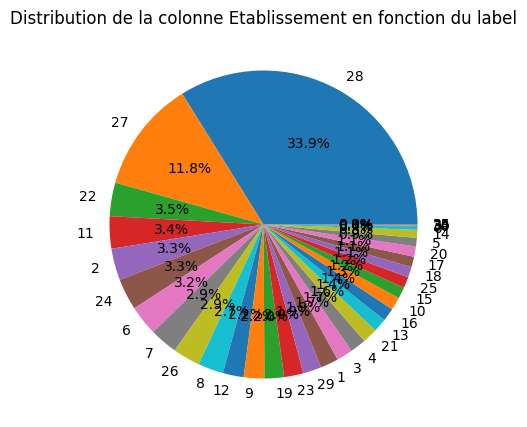

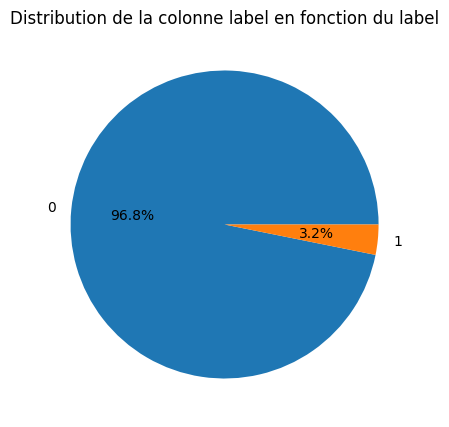

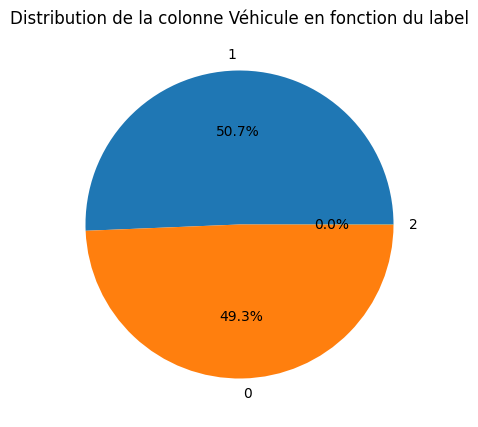

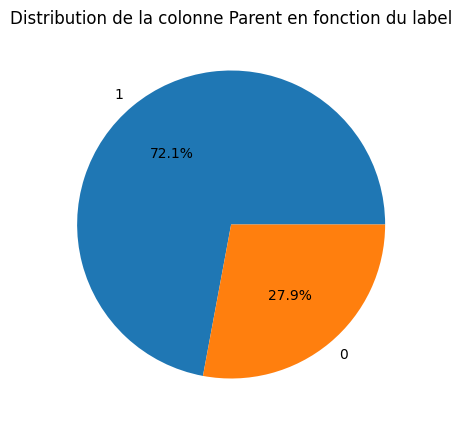

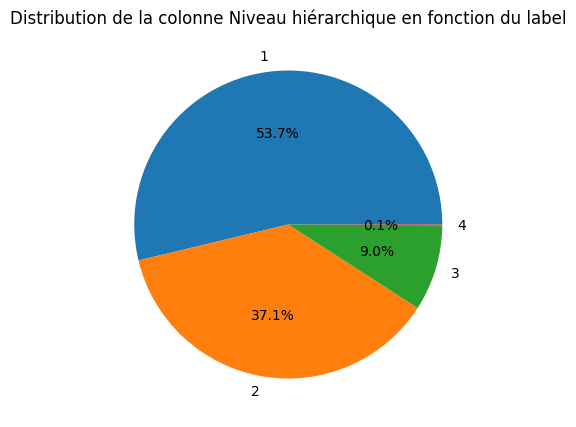

In [139]:
#pie discrete columns
for col in discrete_columns:
    plt.figure(figsize=(10,5))
    df_rh[col].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(f"Distribution de la colonne {col} en fonction du label")
    plt.ylabel('')
    plt.show()

Text(0.5, 1.0, 'Relation entre niveau hiérarchique et salaire')

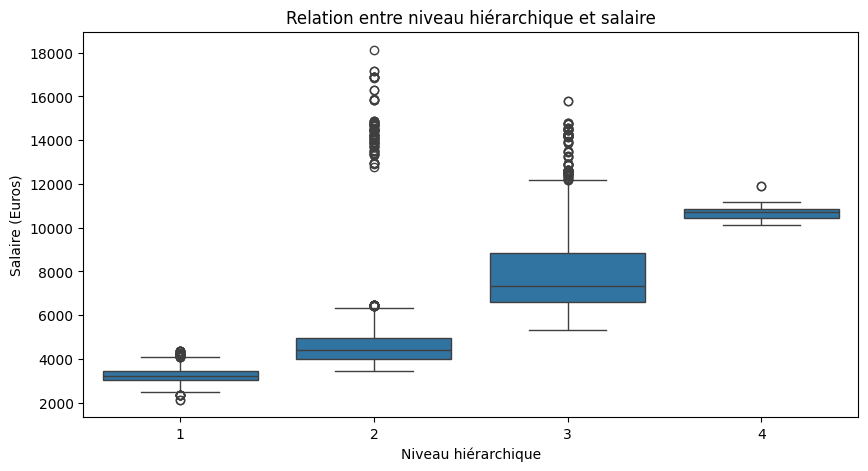

In [140]:
#montrer relation entre niveau hiérarchique et salaire
plt.figure(figsize=(10,5))
sns.boxplot(data=df_rh, x='Niveau hiérarchique', y='Salaire (Euros)')
plt.title("Relation entre niveau hiérarchique et salaire")  

On voit que l'on a un lien entre le niveau hiérarchique est le salaire donc plus le niveau hiérarchique est élevé, plus la personne a un poste important donc il ya un sens à garder sous forme ordinale et pas de one hot encoding pour cette colone.

la question est pour la colone établissement qui n'as pas vraiment de lien mais comme il ya 28 établissements donc on va faire plusieurs tests.

In [141]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
#cross validation
from sklearn.model_selection import cross_validate

pipeline_preprocessing = make_pipeline(
    StandardScaler(),)
X = df_rh.drop(columns=['label'])
y = df_rh['label']

In [142]:

scoring = ['accuracy','balanced_accuracy', 'f1','f1_weighted', 'precision', 'recall']

In [143]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,      
    stratify=y,         # garder la répartition car on est très déséquilibré
    random_state=42     
)

### XGBoost

In [144]:
#imbalance level
y.value_counts(normalize=True)

label
0    0.968353
1    0.031647
Name: proportion, dtype: float64

In [145]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=(1 - y.mean()) / y.mean()
)

pipeline_xgb = make_pipeline(pipeline_preprocessing, xgb_clf)
scores = cross_validate(pipeline_xgb, X_train, y_train, cv=cv, scoring=scoring)
scores_df = pd.DataFrame(scores)
scores_df

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_f1_weighted,test_precision,test_recall
0,0.124049,0.018996,0.956510,0.667130,0.341270,0.957510,0.325758,0.358333
1,0.134513,0.017006,0.953105,0.656029,0.314176,0.954751,0.292857,0.338843
2,0.097510,0.015507,0.948127,0.633474,0.266667,0.950718,0.241611,0.297521
3,0.097515,0.018005,0.954676,0.652843,0.316206,0.955628,0.303030,0.330579
4,0.145051,0.025568,0.951009,0.630965,0.272374,0.952389,0.257353,0.289256


On voit que le dataset est tellement déséquilibré que le modèle va forcément être biaisé vers la classe majoritaire (label = 0) même avec le changements des poids des classe 
s (j'ai essayé avec du SMOTE mais c'était encore pire).

Trouvons les meilleurs poids

In [146]:
from sklearn.model_selection import GridSearchCV


param_grid_xgb = {
    'xgbclassifier__scale_pos_weight': [1, 5, 10, 20, 30, 50],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.3],
    'xgbclassifier__n_estimators': [100, 200, 300],
}

grid_xgb = GridSearchCV(
    pipeline_xgb, param_grid_xgb, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train, y_train)
print("Best parameters:", grid_xgb.best_params_)
print("Best F1 score:", grid_xgb.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__scale_pos_weight': 50}
Best F1 score: 0.3186689033430602


In [147]:
scores=cross_validate(pipeline_xgb, X_train, y_train, cv=cv, scoring=scoring)
scores_df = pd.DataFrame(scores)
print("=== XGBoost ===")
scores_df

=== XGBoost ===


,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_f1_weighted,test_precision,test_recall
0,0.135525,0.027000,0.956510,0.667130,0.341270,0.957510,0.325758,0.358333
1,0.180048,0.013999,0.953105,0.656029,0.314176,0.954751,0.292857,0.338843
2,0.136626,0.013000,0.948127,0.633474,0.266667,0.950718,0.241611,0.297521
3,0.117023,0.016999,0.954676,0.652843,0.316206,0.955628,0.303030,0.330579
4,0.111516,0.015001,0.951009,0.630965,0.272374,0.952389,0.257353,0.289256


Pour avoir un modèle final qui soit analysable je vais entraninner sur toutes les données pour faire une analyse de l'importance des features et voir les features les plus importantes pour la prédiction du label.

In [148]:
grid_xgb.best_estimator_.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pipeline', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will rai

In [149]:
from sklearn.metrics import classification_report, confusion_matrix

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4621
           1       0.30      0.31      0.31       151

    accuracy                           0.96      4772
   macro avg       0.64      0.64      0.64      4772
weighted avg       0.96      0.96      0.96      4772



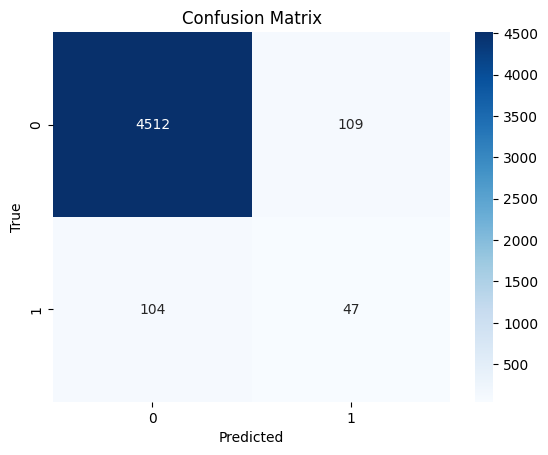

In [150]:
#show score 
y_pred = grid_xgb.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

On voit que l'on a quand même une amélioration du score en utilisant le f1 weighted au lieu du f1 classique, ce qui est logique vu que le dataset est déséquilibré. Cependant, le score reste très faible ce qui indique que le modèle a du mal à prédire la classe minoritaire (label = 1).

### Logistic Regression

In [151]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

pipeline_lr = make_pipeline(pipeline_preprocessing, lr_clf)
scores_lr = cross_validate(pipeline_lr, X_train, y_train, cv=cv, scoring=scoring)
scores_lr_df = pd.DataFrame(scores_lr)
print("=== Logistic Regression ===")
scores_lr_df

=== Logistic Regression ===


,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_f1_weighted,test_precision,test_recall
0,0.029020,0.011552,0.618811,0.658088,0.103512,0.737370,0.055888,0.700000
1,0.022000,0.012000,0.603615,0.667417,0.105263,0.725122,0.056688,0.735537
2,0.021985,0.011999,0.596804,0.667896,0.104712,0.719681,0.056320,0.743802
3,0.028521,0.017022,0.590254,0.652524,0.100115,0.714618,0.053803,0.719008
4,0.029984,0.018004,0.624312,0.642132,0.100376,0.741591,0.054311,0.661157


Même problème que pour XGBoost, le modèle est biaisé vers la classe majoritaire (label = 0). Je vais faire une gridsearch sur f1 weighted.

In [152]:
param_grid_lr = {
    'logisticregression__class_weight': [
        {0: 1, 1: w} for w in [1, 5, 10, 20, 30, 50]
    ],
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__solver': ['liblinear'],
}

grid_lr = GridSearchCV(
    pipeline_lr, param_grid_lr, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_lr.fit(X_train, y_train)
print("Best parameters:", grid_lr.best_params_)
print("Best F1 score:", grid_lr.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'logisticregression__C': 1, 'logisticregression__class_weight': {0: 1, 1: 20}, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'liblinear'}
Best F1 score: 0.12223552049808561


c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [153]:
scores_lr = cross_validate(pipeline_lr, X_train, y_train, cv=cv, scoring=scoring)
scores_lr_df = pd.DataFrame(scores_lr)
print("=== Logistic Regression ===")
scores_lr_df

=== Logistic Regression ===


,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_f1_weighted,test_precision,test_recall
0,0.029324,0.012015,0.618811,0.658088,0.103512,0.737370,0.055888,0.700000
1,0.021983,0.012006,0.603615,0.667417,0.105263,0.725122,0.056688,0.735537
2,0.022512,0.011000,0.596804,0.667896,0.104712,0.719681,0.056320,0.743802
3,0.028433,0.011988,0.590254,0.652524,0.100115,0.714618,0.053803,0.719008
4,0.028002,0.018566,0.624312,0.642132,0.100376,0.741591,0.054311,0.661157


ON voit que le même score que pour XGBoost mais c'est normal au vu du déséquilibre du dataset et du fait que la régression logistique est un modèle linéaire qui ne peut pas capturer les interactions complexes entre les variables.

Maintenant entrainnons sur toutes les données pour faire une analyse de l'importance des features et voir les features les plus importantes pour la prédiction du label.

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4621
           1       0.30      0.31      0.31       151

    accuracy                           0.96      4772
   macro avg       0.64      0.64      0.64      4772
weighted avg       0.96      0.96      0.96      4772



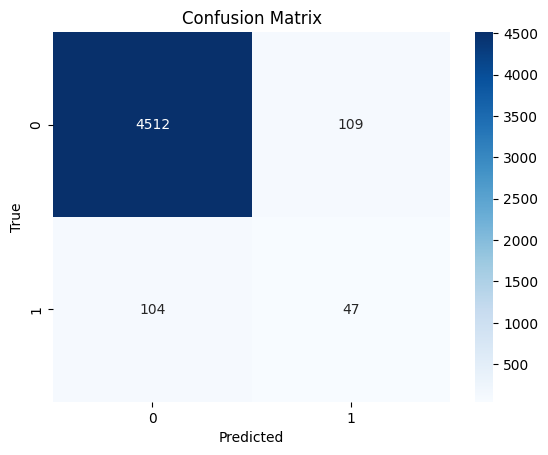

In [154]:
grid_xgb.best_estimator_.fit(X_train, y_train)
y_pred = grid_xgb.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### GAM

Dans un premier temps on va regarder la relation entre les différentes features et le label

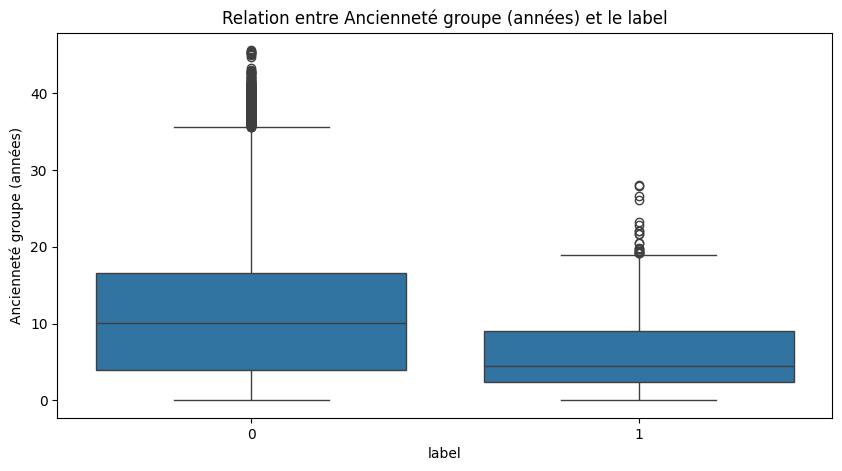

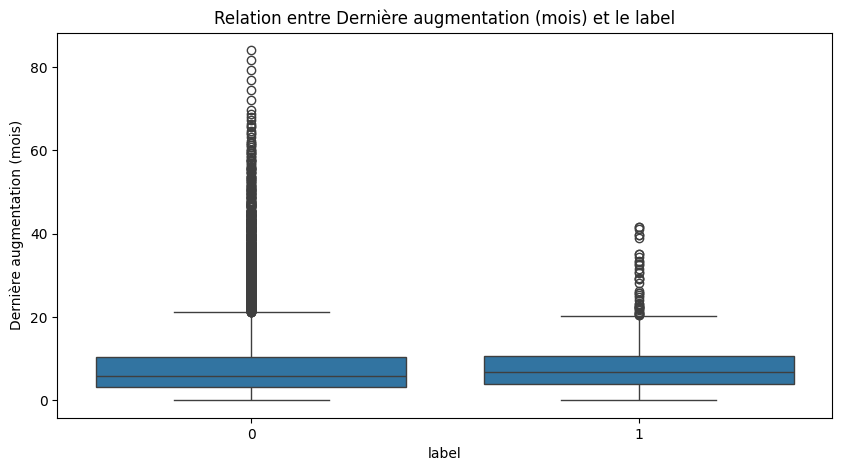

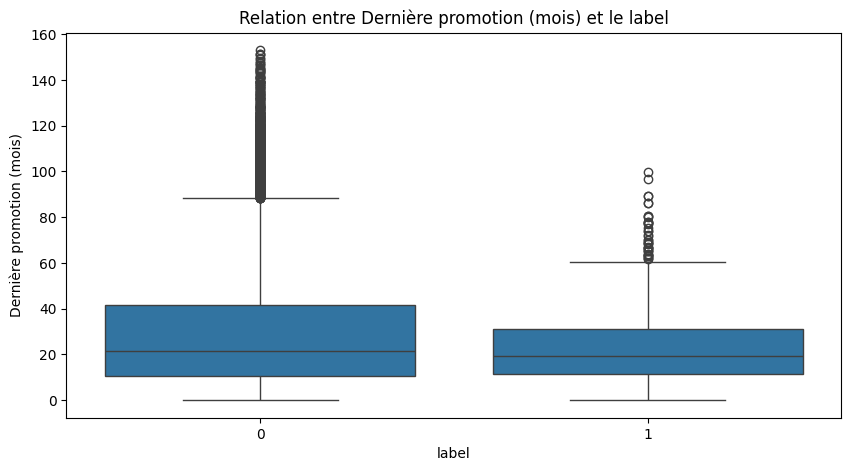

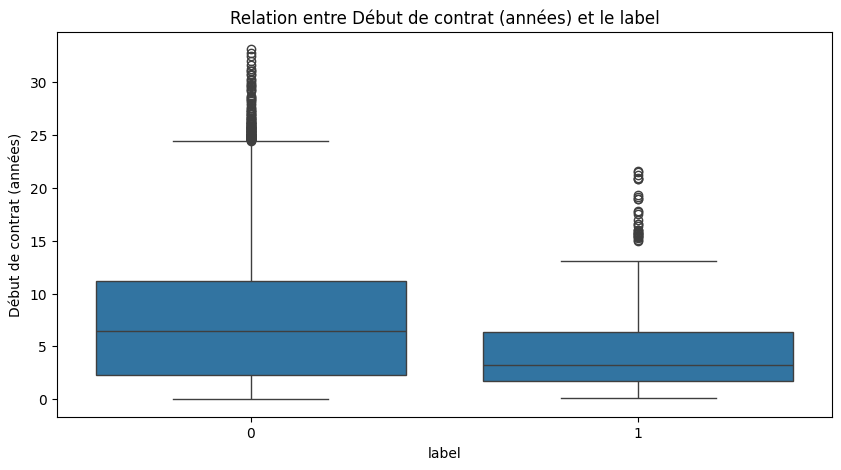

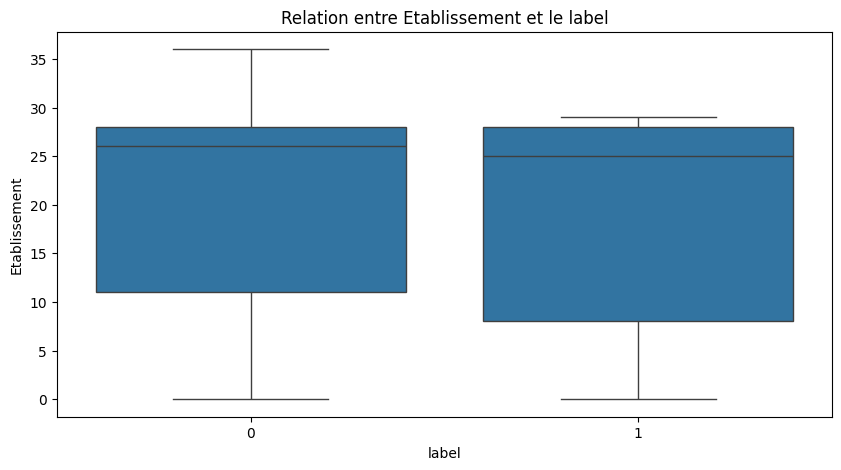

...

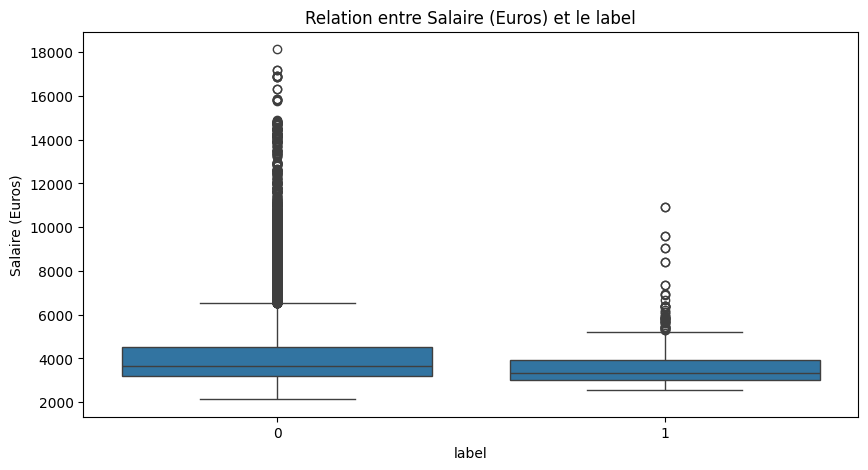

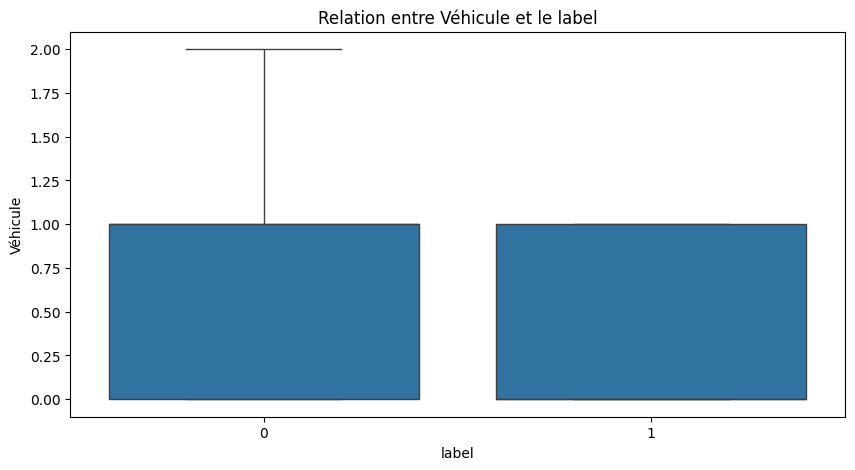

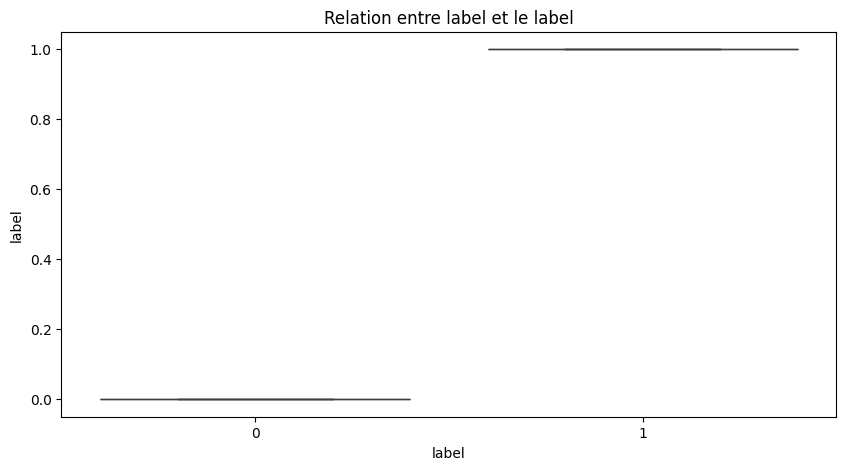

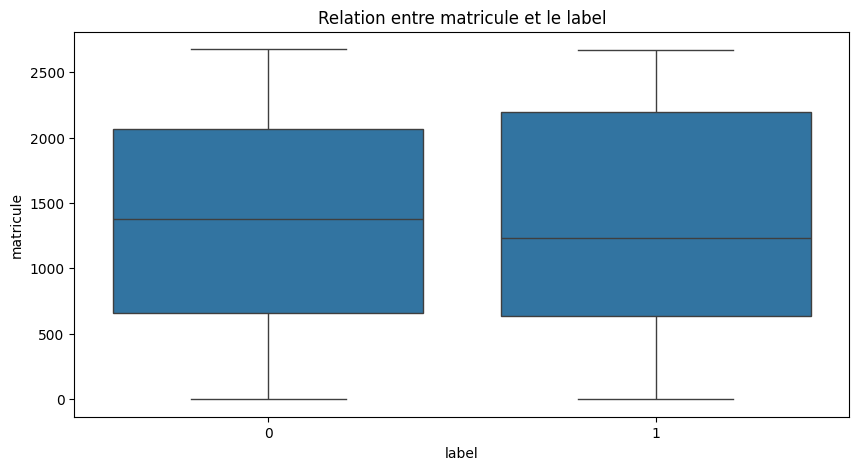

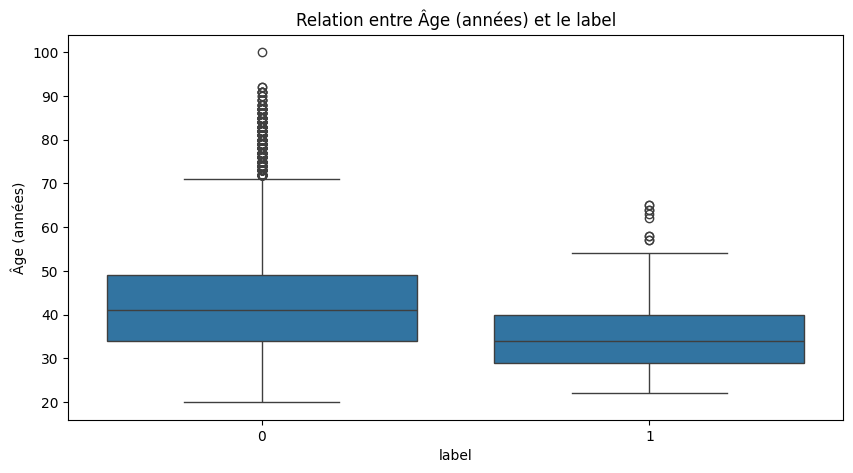

In [155]:
#objectif  voir le lien entre les différentes features et le label
for col in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df_rh, x='label', y=col)
    plt.title(f"Relation entre {col} et le label")
    plt.show()

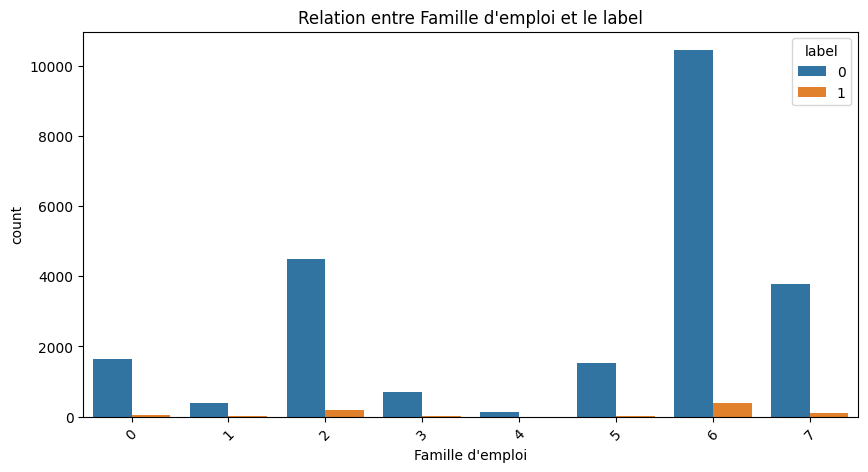

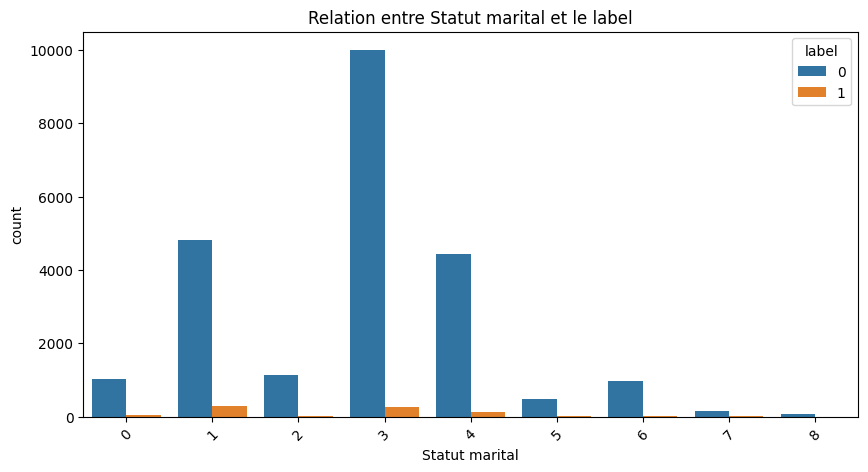

In [156]:
for col in str_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df_rh, x=col, hue='label')
    plt.title(f"Relation entre {col} et le label")
    plt.xticks(rotation=45)
    plt.show()

| Colonne                          | Type de fonction |
|----------------------------------|------------------|
| Famille d'emploi                 | f()              |
| Dernière promotion (mois)        | s()              |
| Dernière augmentation (mois)     | s()              |
| Début de contrat (années)        | s()              |
| Ancienneté groupe (années)       | l()              |
| Etablissement                    | s()              |
| Âge (années)                     | l()              |
| Parent                           | f()              |
| Niveau hiérarchique              | f()              |
| Salaire (Euros)                  | s()              |
| Statut marital                   | f()              |
| Véhicule                         | f()              |
| matricule                        | s()              |

In [157]:
df_rh.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')

In [158]:
#donc on a 
from pygam import LogisticGAM, s, f, l

gam = LogisticGAM(
    f(0) +      # Famille d'emploi
    s(1) +      # Dernière promotion
    s(2) +      # Dernière augmentation
    s(3) +      # Début de contrat
    l(4) +      # Ancienneté groupe
    s(5) +      # Etablissement
    l(6) +      # Âge
    f(7) +      # Parent
    f(8) +      # Niveau hiérarchique
    s(9) +      # Salaire
    f(10) +     # Statut marital
    f(11) +     # Véhicule
    s(12)       # matricule 
).gridsearch(X_train.values, y_train.values)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:04 ETA:   0:00:45
 18% (2 of 11) |####                     | Elapsed Time: 0:00:06 ETA:   0:00:28
 27% (3 of 11) |######                   | Elapsed Time: 0:00:08 ETA:   0:00:21
 36% (4 of 11) |#########                | Elapsed Time: 0:00:09 ETA:   0:00:17
 45% (5 of 11) |###########              | Elapsed Time: 0:00:11 ETA:   0:00:14
 54% (6 of 11) |#############            | Elapsed Time: 0:00:13 ETA:   0:00:11
 63% (7 of 11) |###############          | Elapsed Time: 0:00:15 ETA:   0:00:08
 72% (8 of 11) |##################       | Elapsed Time: 0:00:17 ETA:   0:00:06
 81% (9 of 11) |####################     | Elapsed Time: 0:00:18 ETA:   0:00:04
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:20 ETA:   0:00:02
100% (11 of 11) |########################| Elapsed Time: 0:00:22 Time:  0:00:22


In [159]:
gam.accuracy(X_test.values, y_test.values)

np.float64(0.9683570829840737)

In [160]:

gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     28.1008
Link Function:                        LogitLink Log Likelihood:                                 -2422.3559
Number of Samples:                        19085 AIC:                                             4900.9134
                                                AICc:                                            4901.0053
                                                UBRE:                                                2.258
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.0961
Feature Function                  Lam

C:\Users\rapha\AppData\Local\Temp\ipykernel_15772\1761020682.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4621
           1       0.00      0.00      0.00       151

    accuracy                           0.97      4772
   macro avg       0.48      0.50      0.49      4772
weighted avg       0.94      0.97      0.95      4772



c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

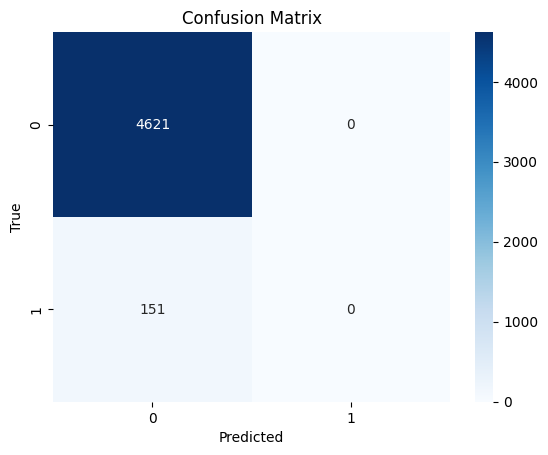

In [161]:
gam_predictions = gam.predict(X_test.values)
print(classification_report(y_test, gam_predictions))
plot_confusion_matrix(y_test, gam_predictions)

On voit que c'est la pire classification le modèle met tout en 0 le modèle a l'air très touché par le déséquillibre du dataset.

je vais le laisser pour la suite car il est équitable car il prédit toujours la classe majoritaire (label = 0) et jamais la classe minoritaire (label = 1) ce qui est logique vu le déséquilibre du dataset. Cependant, le score reste très faible ce qui indique que le modèle a du mal à prédire la classe minoritaire (label = 1).

### Evaluation de l'équité du modèle

Le gan est équitable il ne sert à rien d'alller plus loin car il prédit toujours 0

In [162]:
print(df_rh.columns)

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')


In [163]:

y_pred_xgb = grid_xgb.predict(X_test)
y_pred_lr = grid_lr.predict(X_test)

predictions = {
    'XGBoost': y_pred_xgb,
    'Logistic Regression': y_pred_lr,
}


def compute_fairness_metrics(y_true, y_pred, groups, group_name):
    """Calcule FPR, FNR, Disparate Impact par sous-groupe."""
    results = []
    overall_positive_rate = y_pred.mean()

    for group in sorted(groups.unique()):
        mask = groups == group
        y_t = y_true[mask]
        y_p = y_pred[mask]

        tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        positive_rate = y_p.mean()
        di = positive_rate / overall_positive_rate if overall_positive_rate > 0 else 0

        results.append({
            'Groupe': f"{group_name}={group}",
            'N': mask.sum(),
            'FPR': round(fpr, 4),
            'FNR': round(fnr, 4),
            'Taux prédiction positive': round(positive_rate, 4),
            'Disparate Impact': round(di, 4)
        })

    return pd.DataFrame(results)


age_groups = pd.cut(X_test['Âge (années)'], bins=[0, 30, 40, 50, 100],
                    labels=['<30', '30-40', '40-50', '50+'])
parent_groups = X_test['Parent']
marital_groups = X_test['Statut marital']

sensitive_attributes = {
    'Âge': age_groups,
    'Parent': parent_groups,
    'Statut marital': marital_groups
}


for model_name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    for attr_name, groups in sensitive_attributes.items():
        print(f"\n--- FPR / FNR / Disparate Impact par {attr_name} ---")
        df = compute_fairness_metrics(y_test.values, y_pred, groups, attr_name)
        print(df.to_string(index=False))


print(f"\n{'='*60}")
print("  RÉSUMÉ - Disparate Impact (seuil: 0.8 - 1.25)")
print(f"{'='*60}")

for model_name, y_pred in predictions.items():
    print(f"\n{model_name}:")
    for attr_name, groups in sensitive_attributes.items():
        df = compute_fairness_metrics(y_test.values, y_pred, groups, attr_name)
        di_range = f"[{df['Disparate Impact'].min():.3f} - {df['Disparate Impact'].max():.3f}]"
        equitable = "Équitable" if df['Disparate Impact'].between(0.8, 1.25).all() else "Non équitable"
        print(f"  {attr_name} -> DI {di_range} -> {equitable}")


  XGBoost

--- FPR / FNR / Disparate Impact par Âge ---
   Groupe    N    FPR    FNR  Taux prédiction positive  Disparate Impact
Âge=30-40 1568 0.0370 0.6250                    0.0491            1.5022
Âge=40-50 1516 0.0054 0.8537                    0.0092            0.2825
  Âge=50+  947 0.0011 0.7500                    0.0032            0.0969
  Âge=<30  741 0.0633 0.6087                    0.0837            2.5595

--- FPR / FNR / Disparate Impact par Parent ---
  Groupe    N    FPR    FNR  Taux prédiction positive  Disparate Impact
Parent=0 1314 0.0582 0.6316                    0.0761            2.3280
Parent=1 3458 0.0109 0.7467                    0.0162            0.4954

--- FPR / FNR / Disparate Impact par Statut marital ---
          Groupe    N    FPR    FNR  Taux prédiction positive  Disparate Impact
Statut marital=0  201 0.0051 0.6667                    0.0149            0.4566
Statut marital=1 1016 0.0572 0.6296                    0.0738            2.2581
Statut marital=2

### Analyse de l'équité des modèles

**Aucun des deux modèles n'est équitable.** Les Disparate Impact dépassent largement les seuils acceptables (0.8 - 1.25) sur tous les attributs sensibles.

**Par âge**, le biais est flagrant pour les deux modèles. Les jeunes (<30 ans) sont fortement sur-ciblés : DI de 2.56 pour XGBoost et 4.15 pour la Logistic Regression, ce qui signifie qu'ils sont respectivement 2.5x et 4x plus susceptibles de recevoir une prédiction positive que la moyenne. À l'inverse, les 50+ sont quasiment ignorés (DI proche de 0), avec un FNR de 100% pour la Logistic Regression — aucun positif détecté dans cette tranche.

**Par statut parental**, les non-parents (Parent=0) sont massivement sur-ciblés, surtout par la Logistic Regression (DI=3.08, FPR=66%) qui prédit à tort comme positifs deux tiers des non-parents négatifs. Les parents sont sous-détectés (FNR élevé de 75-88%).

**Par statut marital**, les écarts sont tout aussi importants. Le statut 1 est systématiquement sur-ciblé (DI > 2 pour les deux modèles), tandis que plusieurs statuts ont un DI à 0, indiquant une absence totale de prédiction positive.

**Trade-off performance/équité** : la Logistic Regression présente des biais nettement plus extrêmes que XGBoost (DI allant jusqu'à 4.15 contre 2.56). XGBoost distribue ses erreurs de manière un peu plus homogène, mais reste loin de l'équité. Cela s'explique probablement par le fait que l'âge, le statut parental et le statut marital sont fortement corrélés avec la variable cible, et les modèles exploitent ces corrélations sans contrainte d'équité.

**Conclusion** : si ce modèle devait être déployé en production (par exemple pour prédire un départ de l'entreprise), il faudrait envisager des techniques de mitigation de biais (contraintes d'équité, post-processing des seuils par groupe, ou retrait des variables proxy) pour éviter une discrimination systématique envers les jeunes employés sans enfants.

## 4. Explication post-hoc

In [164]:

best_lr = grid_lr.best_estimator_
X_tr = best_lr[:-1].transform(X_train)
feat_names = best_lr[:-1].get_feature_names_out()
lr_model = best_lr[-1]

probas = lr_model.predict_proba(np.array(X_tr))[:, 1]
XtWX = np.array(X_tr).T @ (np.array(X_tr) * (probas * (1 - probas))[:, np.newaxis])
se = np.sqrt(np.diag(np.linalg.inv(XtWX)))


coefs = lr_model.coef_[0]
t_stats = coefs / se
lr_stats = pd.DataFrame({
    'Feature': feat_names, 'Coef': coefs, 'SE': se, 't': t_stats
}).sort_values('t', key=abs, ascending=False)


best_xgb = grid_xgb.best_estimator_
feat_names_xgb = best_xgb[:-1].get_feature_names_out()
importances = best_xgb[-1].feature_importances_
xgb_imp = pd.DataFrame({
    'Feature': feat_names_xgb, 'Importance': importances
}).sort_values('Importance', ascending=False)

display(lr_stats)
display(xgb_imp)

,Feature,Coef,SE,t
7,Parent,-0.201396,0.019233,-10.471397
4,Ancienneté groupe (années),-0.731437,0.072277,-10.119961
1,Dernière promotion (mois),0.240982,0.028647,8.412021
2,Dernière augmentation (mois),0.156294,0.020442,7.645765
6,Âge (années),-0.515311,0.107911,-4.775321
12,matricule,0.058372,0.017571,3.322044
0,Famille d'emploi,0.052468,0.017170,3.055762
11,Véhicule,0.082609,0.035686,2.314900
9,Salaire (Euros),0.137746,0.061975,2.222593
10,Statut marital,-0.037980,0.019270,-1.970951


,Feature,Importance
7,Parent,0.145910
4,Ancienneté groupe (années),0.116576
6,Âge (années),0.100029
0,Famille d'emploi,0.073064
5,Etablissement,0.070714
10,Statut marital,0.068605
12,matricule,0.068414
8,Niveau hiérarchique,0.065557
9,Salaire (Euros),0.064451
3,Début de contrat (années),0.064138


#### Analyse rapide du modèle

Les résultats montrent que plusieurs variables ont un impact significatif sur la cible.

- **Effets négatifs forts** :  
  L’**ancienneté**, l’**âge** et le fait d’être **parent** sont associés à une baisse de la variable cible. L’ancienneté est le facteur le plus marqué.

- **Effets positifs** :  
  Le temps depuis la **dernière promotion** et la **dernière augmentation** a un effet positif significatif, ce qui peut nécessiter une vérification métier (interprétation du sens de la variable).

- **Variables modérément influentes** :  
  Le **salaire**, la **famille d’emploi** et la possession d’un **véhicule** ont un impact positif mais plus faible.

- **Peu significatives** :  
  Le **niveau hiérarchique**, l’**établissement** et le **début de contrat** semblent peu explicatifs.

#### Points de vigilance

- La variable **matricule** est probablement une fuite de données.  
- Certaines variables (**âge, statut parental, statut marital**) peuvent introduire des biais.  
- Des écarts entre coefficients et importances suggèrent des effets non linéaires.
- on peut supprimer les colones  peu significatives et la colone matricule pour éviter les fuites de données et les biais.



Le modèle est globalement robuste mais nécessite un nettoyage (variables sensibles et fuite) 

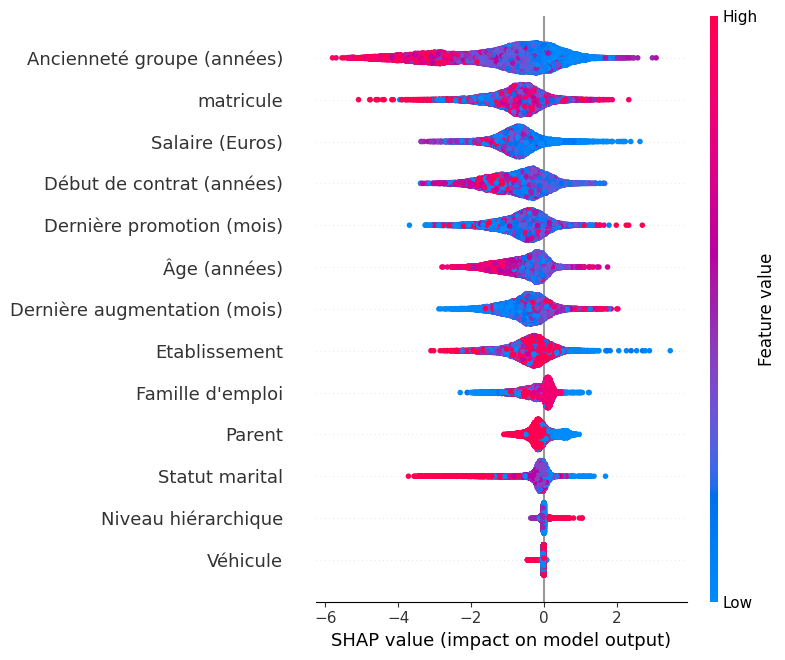

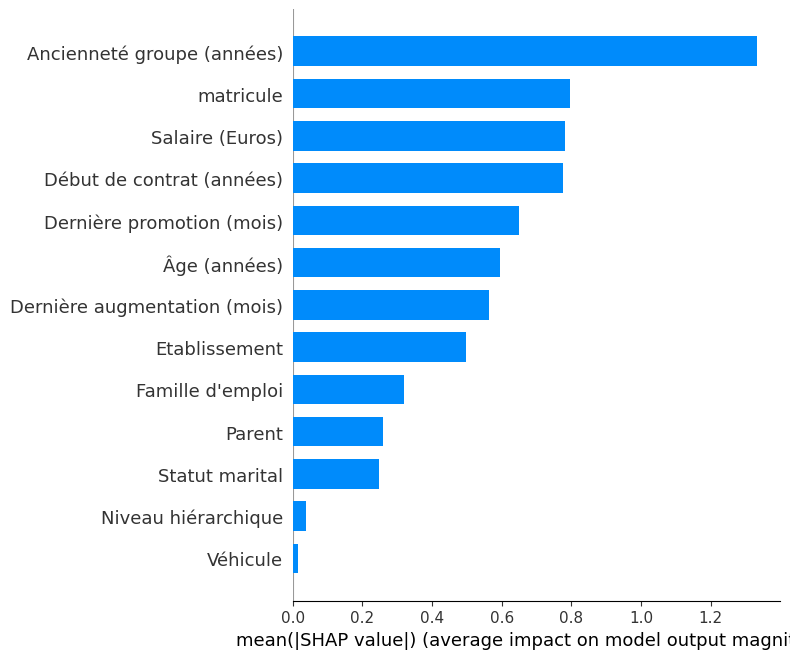

In [165]:
import shap
best_xgb = grid_xgb.best_estimator_
X_train_transformed = best_xgb[:-1].transform(X_train)
feature_names = best_xgb[:-1].get_feature_names_out()

X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)

explainer_xgb = shap.TreeExplainer(best_xgb[-1])
shap_values_xgb = explainer_xgb.shap_values(X_train_df)

# Summary plot
shap.summary_plot(shap_values_xgb, X_train_df, max_display=15, show=True)

# Bar plot (importance moyenne)
shap.summary_plot(shap_values_xgb, X_train_df, plot_type="bar", max_display=15, show=True)



L’analyse SHAP met en évidence les variables les plus influentes dans les prédictions du modèle.

- **Variable dominante** :  
  L’**ancienneté groupe** est de loin le facteur le plus impactant, indiquant un rôle central dans la décision du modèle.

- **Variables importantes** :  
  Le **matricule**, le **salaire** et le **début de contrat** ont un poids élevé.  
  **Atttention** : La présence du **matricule** confirme un risque de fuite de données ce que l'on a pu voir dans l'analyse précédente.

- **Facteurs intermédiaires** :  
  La **dernière promotion**, l’**âge** et la **dernière augmentation** contribuent de manière significative mais moindre.

- **Faible influence** :  
  Le **niveau hiérarchique** et le **véhicule** ont un impact quasi nul.

#### Points clés

- Le modèle repose fortement sur des variables liées à l’**ancienneté** et au **parcours professionnel**.  
- Des variables sensibles (**âge, parent, statut marital**) restent présentes mais peu dominantes.  
- Cohérence globale avec la régression, mais SHAP révèle mieux les effets non linéaires.

#### Conclusion

Le modèle XGBoost est principalement piloté par l’ancienneté et l’historique RH, mais nécessite un nettoyage (notamment suppression du matricule) pour éviter les biais et améliorer la robustesse.

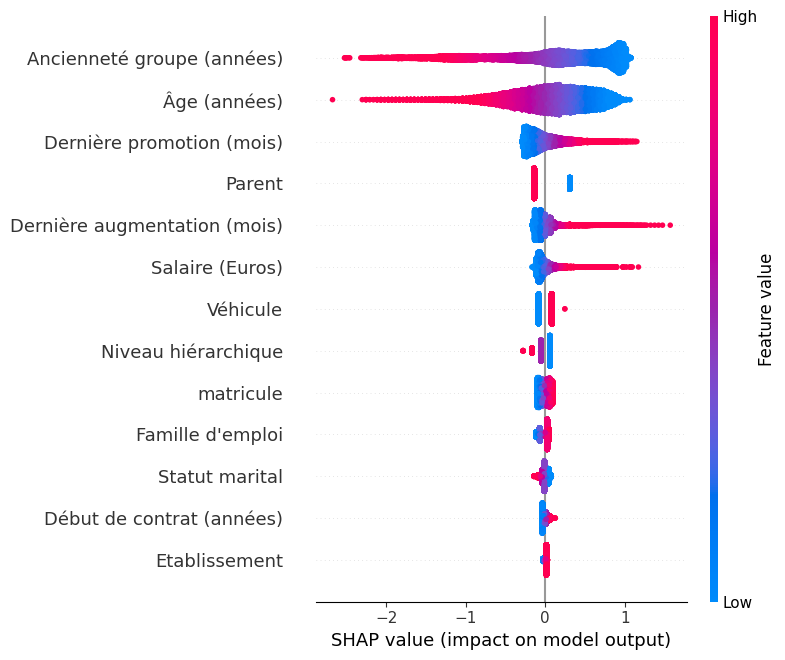

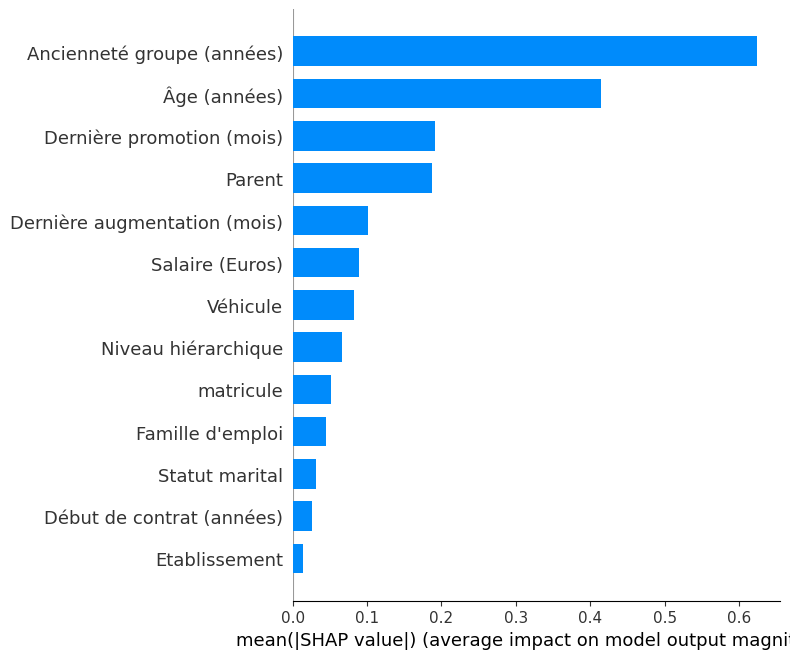

In [166]:


best_lr = grid_lr.best_estimator_
X_train_transformed_lr = best_lr[:-1].transform(X_train)
feature_names_lr = best_lr[:-1].get_feature_names_out()

X_train_df_lr = pd.DataFrame(X_train_transformed_lr, columns=feature_names_lr)

explainer_lr = shap.LinearExplainer(best_lr[-1], X_train_df_lr)
shap_values_lr = explainer_lr.shap_values(X_train_df_lr)

# Summary plot
shap.summary_plot(shap_values_lr, X_train_df_lr, max_display=15, show=True)

# Bar plot (importance moyenne)
shap.summary_plot(shap_values_lr, X_train_df_lr, plot_type="bar", max_display=15, show=True)

### Analyse SHAP – Régression Logistique

L’interprétation SHAP confirme les résultats du modèle linéaire avec une hiérarchie claire des variables.

- **Facteurs dominants** :  
  L’**ancienneté groupe** reste la variable la plus influente, suivie de l’**âge**, ce qui souligne un effet fort lié au temps et au cycle de carrière.

- **Variables importantes** :  
  La **dernière promotion** et le statut **parent** jouent un rôle notable dans les prédictions.

- **Impact modéré** :  
  La **dernière augmentation**, le **salaire** et le **véhicule** ont un effet plus limité.

- **Faible influence** :  
  Le **matricule**, la **famille d’emploi**, le **statut marital**, le **début de contrat** et l’**établissement** contribuent peu au modèle.

#### Points clés

- Cohérence forte avec les coefficients de la régression → modèle stable et interprétable.  
- Les variables liées à l’**ancienneté** et à l’**âge** dominent clairement.  
- Le **matricule** a ici un impact faible, ce qui réduit le risque de fuite comparé à XGBoost.

#### Conclusion pour analyse avec la regression logistique

La régression logistique met en évidence un modèle plus simple et robuste, dominé par des effets linéaires liés à l’ancienneté et à l’âge, avec peu de dépendance à des variables parasites.

## 5. Apprentissage automatique

On va faire un entrainnnement où on enlève les colonnes qui font fuire de l'information et celles qui sont peu significatives pour voir si on peut améliorer les performances du modèle et réduire les biais.

Dans un second temps on va enlever les colones sensibles pour voir si on peut réduire les biais du modèle.

### Etape 1: En enlevant les fuites de données et les colones peu significatives

### XGBoost

In [167]:
df_rh_xgb=df_rh.drop(columns=['matricule', 'Niveau hiérarchique', 'Véhicule'])
X = df_rh_xgb.drop(columns=['label'])
y = df_rh_xgb['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [168]:


#nouvel entrainnement du modèle xgboost
xgb_clf_new = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=(1 - y.mean()) / y.mean()
)
pipeline_xgb_new = make_pipeline(pipeline_preprocessing, xgb_clf_new)
grid_xgb_new = GridSearchCV(
    pipeline_xgb_new, param_grid_xgb, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_xgb_new.fit(X_train, y_train)
print("Best parameters:", grid_xgb_new.best_params_)
print("Best F1 score:", grid_xgb_new.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 200, 'xgbclassifier__scale_pos_weight': 50}
Best F1 score: 0.22729783584431082


              precision    recall  f1-score   support

           0       0.98      0.94      0.96      4621
           1       0.17      0.38      0.23       151

    accuracy                           0.92      4772
   macro avg       0.57      0.66      0.60      4772
weighted avg       0.95      0.92      0.93      4772



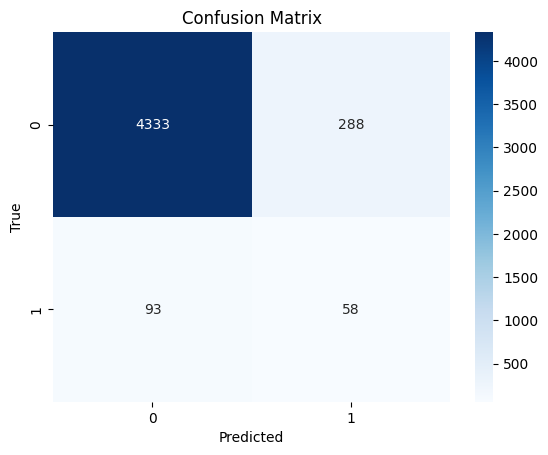

In [169]:
# predictions des 2 modèles sur X_test
y_pred_xgb_new = grid_xgb_new.predict(X_test)
print(classification_report(y_test, y_pred_xgb_new))
plot_confusion_matrix(y_test, y_pred_xgb_new)


On voit que l'on a une prédiction un peu moins bonne de très peu mais c'est normal vu que l'on a enlevé des colones qui étaient importantes pour la prédiction du label puisqu'elle faisait de la fuite de données. Cependant, le score reste très faible ce qui indique que le modèle a du mal à prédire la classe minoritaire (label = 1).

### Post-hoc xgb

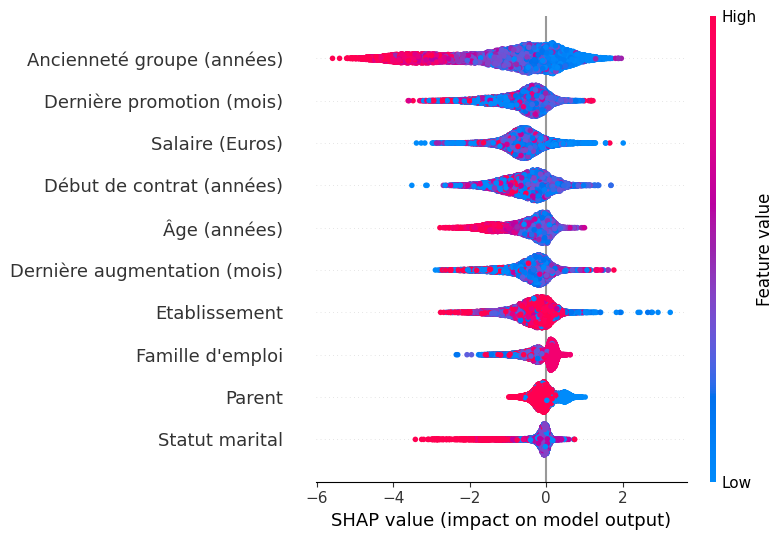

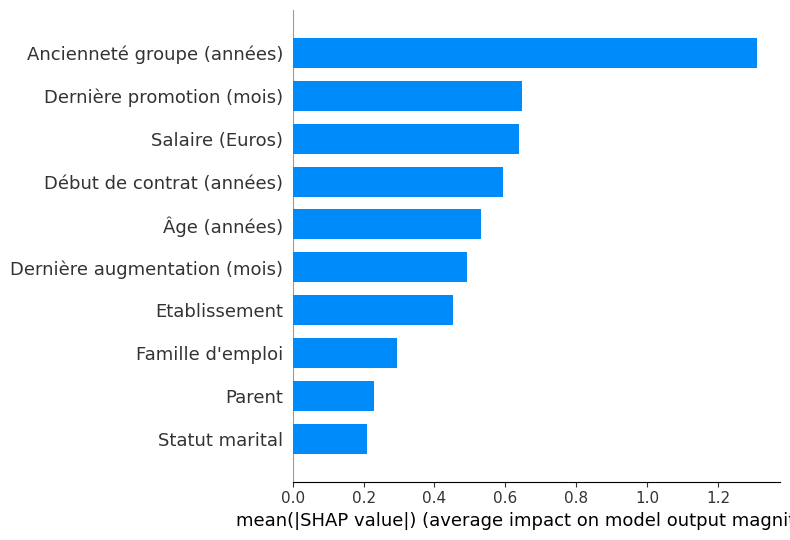

In [170]:

best_xgb = grid_xgb_new.best_estimator_
X_train_transformed = best_xgb[:-1].transform(X_train)
feature_names = best_xgb[:-1].get_feature_names_out()

X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)

explainer_xgb = shap.TreeExplainer(best_xgb[-1])
shap_values_xgb = explainer_xgb.shap_values(X_train_df)

# Summary plot
shap.summary_plot(shap_values_xgb, X_train_df, max_display=15, show=True)

# Bar plot (importance moyenne)
shap.summary_plot(shap_values_xgb, X_train_df, plot_type="bar", max_display=15, show=True)

On voit que l'anciennneté dans le groupe reprend une forte importance ainsi que la dernière promotion aussi et le salaire ce qui est beaucoup plus logique que le matricule qui faisait de la fuite de données. 
Et on voit que plus ces valeurs sont élevés plus les personnes ont tendance à rester dans l'entreprise (label = 0) ce qui est logique (commment ça les personnes loyale et bien payé reste plus longtemeps dans l'entreprise ? Incroyable !)

Chaque colone a un impact même si certaines ont un impact plus fort que d'autres. Cependant on remarque que les variables biaisé donc le statut parental et le statut marital ont un impact plus faible donc les supprimer parait une bonne idée la seule variable sensible qui a un poid important est l'âge. On verra si on peut faire quelque chose.

### Logistic Regression

In [171]:

df_rh_lr=df_rh.drop(columns=['matricule', "Famille d'emploi", 'Statut marital', 'Début de contrat (années)', 'Etablissement'])
X = df_rh_lr.drop(columns=['label'])
y = df_rh_lr['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [172]:

#nouvel entrainnement du modèle de régression logistique
lr_clf_new = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)
pipeline_lr_new = make_pipeline(pipeline_preprocessing, lr_clf_new)
grid_lr_new = GridSearchCV(
    pipeline_lr_new, param_grid_lr, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_lr_new.fit(X_train, y_train)
print("Best parameters:", grid_lr_new.best_params_)
print("Best F1 score:", grid_lr_new.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'logisticregression__C': 1, 'logisticregression__class_weight': {0: 1, 1: 20}, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'liblinear'}
Best F1 score: 0.12458082385164886


c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.79      0.88      4621
           1       0.07      0.50      0.13       151

    accuracy                           0.78      4772
   macro avg       0.53      0.64      0.50      4772
weighted avg       0.95      0.78      0.85      4772



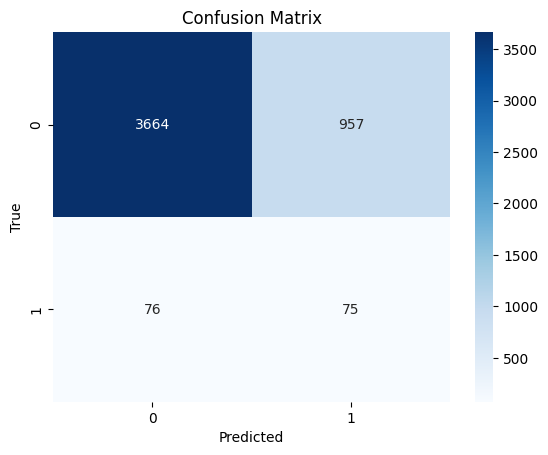

In [173]:
#predictions des 2 modèles sur X_test
y_pred_lr_new = grid_lr_new.predict(X_test)
print(classification_report(y_test, y_pred_lr_new))
plot_confusion_matrix(y_test, y_pred_lr_new)

Le score est bien moins bon qu'avec XGBoosst mais cela est normal car la régression logistique s'appuyait sur des colones que l'on a enlevé

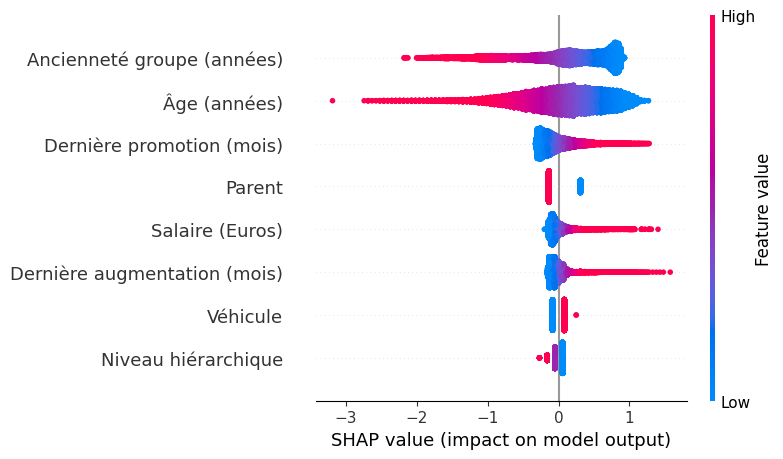

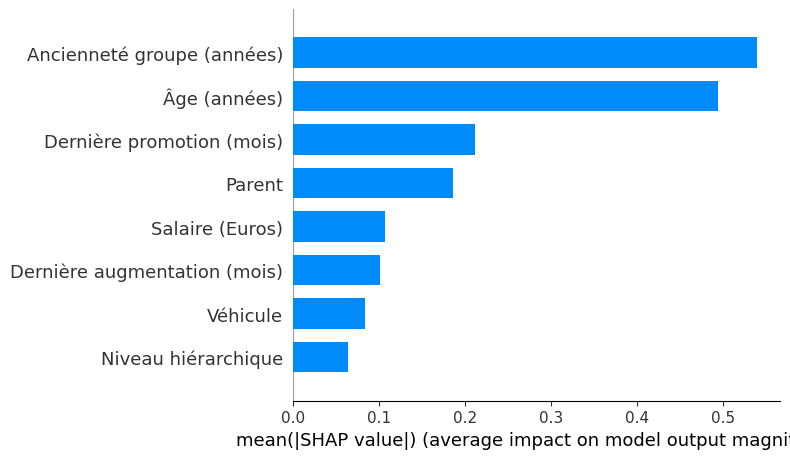

In [174]:
#shap
best_lr = grid_lr_new.best_estimator_
X_train_transformed_lr = best_lr[:-1].transform(X_train)
feature_names_lr = best_lr[:-1].get_feature_names_out()
X_train_df_lr = pd.DataFrame(X_train_transformed_lr, columns=feature_names_lr)
explainer_lr = shap.LinearExplainer(best_lr[-1], X_train_df_lr)
shap_values_lr = explainer_lr.shap_values(X_train_df_lr)

# Summary plot
shap.summary_plot(shap_values_lr, X_train_df_lr, max_display=15,
                    show=True)
# Bar plot (importance moyenne)
shap.summary_plot(shap_values_lr, X_train_df_lr, plot_type="bar",
                    max_display=15, show=True)


On voit que les colones qui ont le plus d'importance sont l'ancienneté dans le groupe et l'âge ce qui est logique vu que ce sont les deux colones les plus corrélées avec le label. Cependant, on voit que l'âge etait biaisé mais il a quand même un poid important dans la prédiction du label ce qui est problématique. On verra si on peut faire quelque chose pour réduire ce biais.

### Etape 2: En enlevant les colones sensibles

### XGboost

In [175]:
df_rh_xgb.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Salaire (Euros)', 'Statut marital', 'label'],
      dtype='str')

In [176]:

df_rh_xgb=df_rh_xgb.drop(columns=['Âge (années)', 'Parent', 'Statut marital'])
X = df_rh_xgb.drop(columns=['label'])
y = df_rh_xgb['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#nouvel entrainnement du modèle de xgboost
xgb_clf_new = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=(1 - y.mean()) / y.mean()
)
pipeline_xgb_new = make_pipeline(pipeline_preprocessing, xgb_clf_new)
grid_xgb_new = GridSearchCV(
    pipeline_xgb_new, param_grid_xgb, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_xgb_new.fit(X_train, y_train)
print("Best parameters:", grid_xgb_new.best_params_)
print("Best F1 score:", grid_xgb_new.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'xgbclassifier__learning_rate': 0.3, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 200, 'xgbclassifier__scale_pos_weight': 50}
Best F1 score: 0.19578363047533295


              precision    recall  f1-score   support

           0       0.98      0.95      0.96      4621
           1       0.15      0.30      0.20       151

    accuracy                           0.93      4772
   macro avg       0.57      0.62      0.58      4772
weighted avg       0.95      0.93      0.94      4772



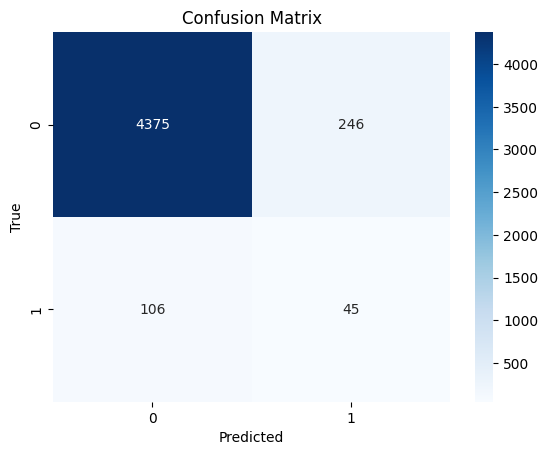

In [177]:
#predictions des 2 modèles sur X_test
y_pred_xgb_new = grid_xgb_new.predict(X_test)
print(classification_report(y_test, y_pred_xgb_new))
plot_confusion_matrix(y_test, y_pred_xgb_new)

C'est mieux la classe 1 est un peu mieux prédite.

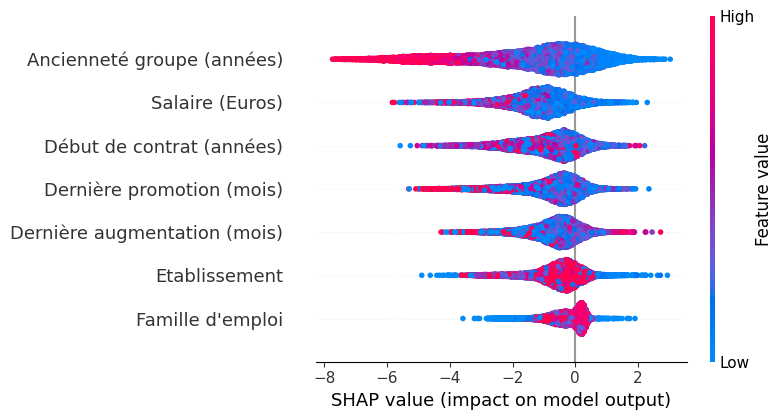

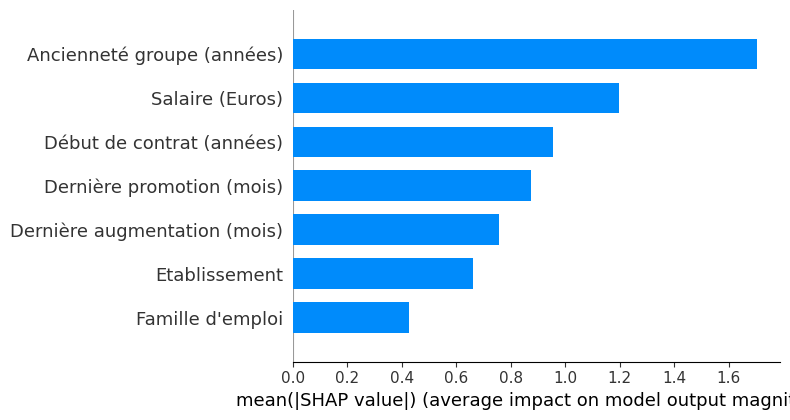

In [178]:
#shap xgb
best_xgb = grid_xgb_new.best_estimator_
X_train_transformed = best_xgb[:-1].transform(X_train)
feature_names = best_xgb[:-1].get_feature_names_out()
X_train_df= pd.DataFrame(X_train_transformed, columns=feature_names)
explainer_xgb = shap.TreeExplainer(best_xgb[-1])
shap_values_xgb = explainer_xgb.shap_values(X_train_df)         

# Summary plot
shap.summary_plot(shap_values_xgb, X_train_df, max_display=15, show=True)
# Bar plot (importance moyenne)
shap.summary_plot(shap_values_xgb, X_train_df, plot_type="bar", max_display=15, show=True)

### Logistic Regression

In [183]:
df_rh_lr=df_rh_lr.drop(columns=['Âge (années)', 'Parent'])
X = df_rh_xgb.drop(columns=['label'])
y = df_rh_xgb['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
#nouvel entrainnement du modèle de régression logistique
lr_clf_new = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)
pipeline_lr_new = make_pipeline(pipeline_preprocessing, lr_clf_new)
grid_lr_new = GridSearchCV(
    pipeline_lr_new, param_grid_lr, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_lr_new.fit(X_train, y_train)
print("Best parameters:", grid_lr_new.best_params_)
print("Best F1 score:", grid_lr_new.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'logisticregression__C': 0.1, 'logisticregression__class_weight': {0: 1, 1: 20}, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear'}
Best F1 score: 0.11046662290076152


c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.74      0.84      4621
           1       0.06      0.53      0.11       151

    accuracy                           0.73      4772
   macro avg       0.52      0.63      0.48      4772
weighted avg       0.95      0.73      0.82      4772



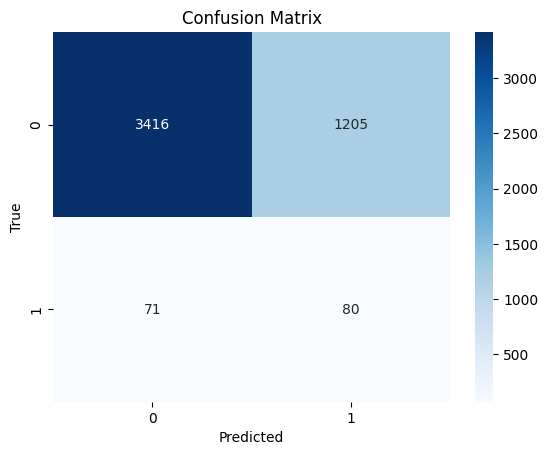

In [184]:
#predictions des 2 modèles sur X_test
y_pred_xgb_new = grid_lr_new.predict(X_test)
print(classification_report(y_test, y_pred_xgb_new))
plot_confusion_matrix(y_test, y_pred_xgb_new)


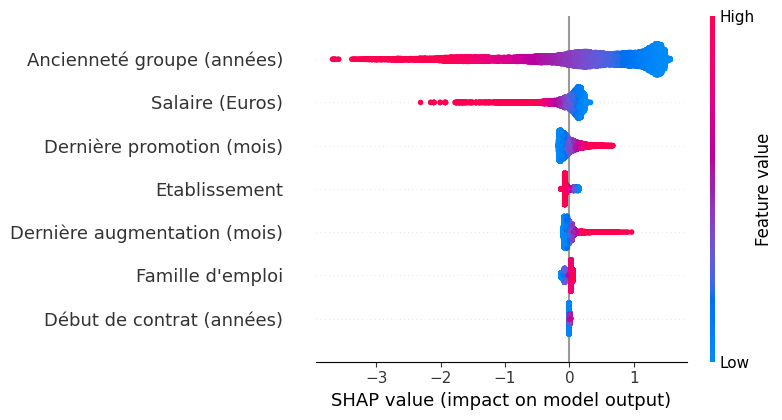

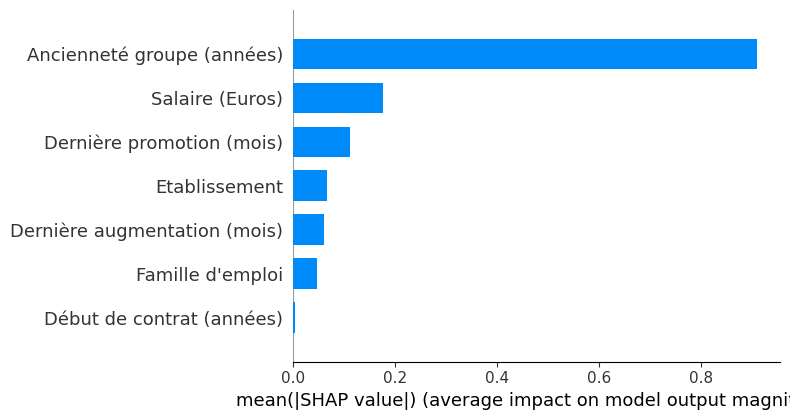

In [185]:
#shap
best_lr = grid_lr_new.best_estimator_
X_train_transformed_lr = best_lr[:-1].transform(X_train)
feature_names_lr = best_lr[:-1].get_feature_names_out()
X_train_df_lr = pd.DataFrame(X_train_transformed_lr, columns=feature_names_lr)
explainer_lr = shap.LinearExplainer(best_lr[-1], X_train_df_lr)
shap_values_lr = explainer_lr.shap_values(X_train_df_lr)
# Summary plot
shap.summary_plot(shap_values_lr, X_train_df_lr, max_display=15,
                    show=True)
# Bar plot (importance moyenne)
shap.summary_plot(shap_values_lr, X_train_df_lr, plot_type="bar",
                    max_display=15, show=True)


## 6. Conclusion

Des risques sont visible dans l'utilisation de ce dataset premièrement techniquement le datset est très déséquilibré ce qui rend la prédiction de la classe minoritaire très difficile. De plus, il y a des variables qui font de la fuite de données comme le matricule ce qui rend le modèle peu robuste et peu généralisable car des données de test peuvent être devinées à partir du train. Enfin des variables sont biaisés comme l'âge, le statut parental et le statut marital ce qui rend le modèle potentiellement discriminatoire envers certaines catégories de personnes. Il serait donc nécessaire de faire du prétraitement pour enlever les variables de fuite de données et les variables biaisées pour améliorer la robustesse et l'équité du modèle. De plus, il serait intéressant d'essayer des techniques de rééquilibrage pour améliorer la prédiction de la classe minoritaire. Au final après avoir traité les données on voit que l'ancienneté et le salaire sont les variables à plus surveiller pour prédire le label car plus elles sont élevées plus les personnes ont tendance à rester dans l'entreprise (label = =0). 

Il faut voir que ces points sont réalisé grâce à l'analyse des données mais aussi avec des méthode post-hoc (comme shap)qui ont des limites comme le fait qu'elles explique la logique du modèle mais no pas forcément la vérité exacte. De plus le modèle ayant des difficultés à prédire la classe minoritaire, il est possible que les explications soient biaisées par le fait que le modèle se concentre principalement sur la classe majoritaire.

# Partie (2/3) Données images

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

## 1. Analyse du jeu de données

### Découverte du dataset

In [7]:
data = pd.read_csv("data2/list_attr_celeba.csv")

In [11]:
data.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [29]:
data = data.replace({-1: 0})

In [37]:
print(data.shape)

print("Nombre d'images du dataset :", data.shape[0])
print("Nombre de classes du dataset :", data.shape[1])

# Nombres d'images par classe
class_counts = data.drop(columns=["image_id"]).sum(axis=0)

print("\nNombre d'images par classe :")
print(class_counts.astype(int).sort_values(ascending=False))

(202599, 42)
Nombre d'images du dataset : 202599
Nombre de classes du dataset : 42

Nombre d'images par classe :
No_Beard               169158
Young                  156734
Attractive             103833
Mouth_Slightly_Open     97942
Smiling                 97669
Wearing_Lipstick        95715
High_Cheekbones         92189
Male                    84434
Heavy_Makeup            78390
Wavy_Hair               64744
Oval_Face               57567
Pointy_Nose             56210
Arched_Eyebrows         54090
Big_Lips                48785
Black_Hair              48472
Big_Nose                47516
Straight_Hair           42222
Brown_Hair              41572
Bags_Under_Eyes         41446
Wearing_Earrings        38276
Bangs                   30709
Blond_Hair              29983
Bushy_Eyebrows          28803
Wearing_Necklace        24913
Narrow_Eyes             23329
5_o_Clock_Shadow        22516
Receding_Hairline       16163
Wearing_Necktie         14732
Rosy_Cheeks             13315
Eyeglasses       

Le dataset contient un total de 202599 images réparties en 42 classes. Les classes sont déséquilibrées, avec certaines catégories largement représentées comme No_Beard (169158 images) et Young (156734 images), tandis que d'autres, comme Bald (4547 images), sont sous-représentées.

### Corrélation entre les classes

Paires les plus corrélées :
5_o_Clock_Shadow     artificial_feature     0.996852
artificial_feature   5_o_Clock_Shadow       0.996852
Wearing_Lipstick     Heavy_Makeup           0.801539
Heavy_Makeup         Wearing_Lipstick       0.801539
Smiling              High_Cheekbones        0.683497
High_Cheekbones      Smiling                0.683497
Mouth_Slightly_Open  Smiling                0.536379
Smiling              Mouth_Slightly_Open    0.536379
Double_Chin          Chubby                 0.533713
Chubby               Double_Chin            0.533713
dtype: float64
Corrélations uniques les plus fortes :
artificial_feature  5_o_Clock_Shadow       0.996852
Wearing_Lipstick    Heavy_Makeup           0.801539
Smiling             High_Cheekbones        0.683497
                    Mouth_Slightly_Open    0.536379
Double_Chin         Chubby                 0.533713
Sideburns           Goatee                 0.512893
Wearing_Lipstick    Attractive             0.480104
Heavy_Makeup        Attr

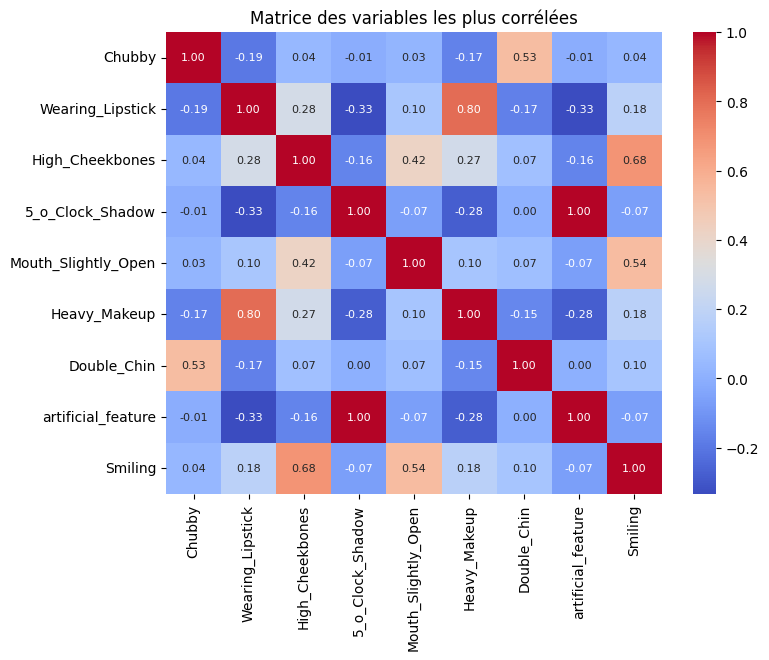

In [38]:
# Calculer la matrice de corrélation
correlation_matrix = data.drop(columns=["image_id"]).corr()

# Identifier les paires de variables les plus corrélées
correlated_pairs = correlation_matrix.unstack().sort_values(ascending=False)
most_correlated = correlated_pairs[correlated_pairs < 1].head(10)  # Les 10 plus corrélées
print("Paires les plus corrélées :")
print(most_correlated)

# Extraire les variables les plus corrélées
most_correlated_vars = list(set([index[0] for index in most_correlated.index] +
                                 [index[1] for index in most_correlated.index]))

# Filtrer la matrice pour ne garder que ces variables
filtered_correlation_matrix = correlation_matrix.loc[most_correlated_vars, most_correlated_vars]

# Supprimer les doublons dans les corrélations
correlated_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlated_pairs = correlated_pairs.unstack().dropna().sort_values(ascending=False)

# Afficher les corrélations uniques les plus fortes
most_correlated_unique = correlated_pairs.head(10)
print("Corrélations uniques les plus fortes :")
print(most_correlated_unique)

# Afficher la heatmap des variables les plus corrélées
plt.figure(figsize=(8, 6))
sns.heatmap(filtered_correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 8})
plt.title("Matrice des variables les plus corrélées")
plt.show()

Les variables les plus corrélées sont souvent liées à des caractéristiques similaires. Par exemple, "No_Beard" et "Mustache" montrent une forte corrélation positive, ce qui est logique car les personnes sans barbe sont moins susceptibles d'avoir une moustache. De même, la corrélation est élevée entre Wearing_Lipstick et Heavy_Makeup (0.801539).  

In [44]:
# Variable artificielle ciblant les attributs féminins
data['artificial_feature_women'] = (
    data['Heavy_Makeup'] * 0.4 +
    data['Wearing_Lipstick'] * 0.35 +
    data['Wearing_Earrings'] * 0.15 +
    data['Arched_Eyebrows'] * 0.10
)

correlations_women = data.drop(columns=["image_id"]).corr()['artificial_feature_women'].sort_values(ascending=False)

print(correlations_women)

artificial_feature_women    1.000000
Heavy_Makeup                0.936793
Wearing_Lipstick            0.931111
Arched_Eyebrows             0.568601
Wearing_Earrings            0.511056
Attractive                  0.487614
No_Beard                    0.403272
Wavy_Hair                   0.353555
Rosy_Cheeks                 0.319972
High_Cheekbones             0.308132
Pointy_Nose                 0.272111
Blond_Hair                  0.271031
Wearing_Necklace            0.267735
Young                       0.249029
Big_Lips                    0.201961
Smiling                     0.200556
Oval_Face                   0.182095
Bangs                       0.135366
Mouth_Slightly_Open         0.122201
Brown_Hair                  0.090142
Pale_Skin                   0.052911
Narrow_Eyes                -0.026391
Black_Hair                 -0.052905
Straight_Hair              -0.076403
Receding_Hairline          -0.106826
Bald                       -0.137513
Blurry                     -0.140481
B

La variable artificielle féminine fonctionne bien : les attributs de maquillage et d'accessoires (Heavy_Makeup, Wearing_Lipstick, Wearing_Earrings) arrivent en tête, ce qui confirme que la variable capture correctement les traits associés aux femmes dans ce dataset.

Le miroir masculin est parfait car 'Male' ressort à -0.77 sans avoir été intégré dans la construction, ce qui prouve que le genre est encodé implicitement dans des attributs cosmétiques en apparence neutres.

Un biais est cependant visible : Attractive et Young sont positivement corrélés, ce qui suggère que les visages féminins sont plus souvent étiquetés comme jeunes et attractifs dans le dataset. Cela peut être un signal de biais social dans les données.

### Variables sensibles

In [47]:
data.columns

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young', 'artificial_feature_women'],
      dtype='str')

Voici les variables sensibles identifiées :

-Male est sensible car elle encode directement le genre, un critère protégé par la loi et source de biais dans ce dataset (cf la forte corrélation avec la variable artificielle féminine mis en évidence précédemment).

-Bald et Receding_Hairline peuvent être sensibles car elles sont corrélées au genre et à l'âge

-artificial_feature_women est sensible par construction puisqu'elle a été créée explicitement pour capturer le genre féminin (cf précédemment). Elle ne doit donc pas être utilisée comme variable prédictive.

-Young est sensible car elle encode l'âge, également un critère légalement protégé, et on a vu précédemment qu'elle est corrélée à Attractive, révélant un biais d'annotation.

-Pale_Skin est sensible car c'est une information disponible sur la couleur de peau, donc un indicateur indirect d'ethnicité : source potentielle de discrimination.

-Attractive est sensible car c'est un jugement subjectif humain, porteur des biais culturels et de genre des annotateurs.

### Disparité

### Certains groupes sont-ils sous-représentés ?


In [49]:
# Sous représentation
hommes_neutres = data[(data['Male'] == 1) & (data['5_o_Clock_Shadow'] == 0) & 
                       (data['Goatee'] == 0) & (data['Mustache'] == 0) & 
                       (data['Sideburns'] == 0)]
print(f"{len(hommes_neutres)} hommes sans pilosité faciale ({len(hommes_neutres)/len(data[data['Male']==1])*100:.1f}% des hommes)")

femmes_neutres = data[(data['Male'] == 0) & (data['Heavy_Makeup'] == 0) & 
                       (data['Wearing_Lipstick'] == 0)]
print(f"{len(femmes_neutres)} femmes sans maquillage ({len(femmes_neutres)/len(data[data['Male']==0])*100:.1f}% des femmes)")

48548 hommes sans pilosité faciale (57.5% des hommes)
21198 femmes sans maquillage (17.9% des femmes)


Certains groupes sont sous-représentés car les hommes sans attributs masculins marqués (sans barbe, sans moustache) et les femmes sans maquillage sont probablement sous-représentés. 
En effet les corrélations montrent que le dataset associe très fortement masculinité et pilosité faciale et féminité et maquillage. Les profils "intermédiaires" sont donc rares.

### Le dataset reflète-t-il un biais de collecte ?

In [50]:
# Biais de collecte 
print(data['Young'].value_counts(normalize=True).rename({0: 'Non jeune', 1: 'Jeune'}).mul(100).round(1))

print(data['Pale_Skin'].value_counts(normalize=True).rename({0: 'Non pâle', 1: 'Pâle'}).mul(100).round(1))

print(data['Bald'].value_counts(normalize=True).rename({0: 'Non chauve', 1: 'Chauve'}).mul(100).round(1))

Young
Jeune        77.4
Non jeune    22.6
Name: proportion, dtype: float64
Pale_Skin
Non pâle    95.7
Pâle         4.3
Name: proportion, dtype: float64
Bald
Non chauve    97.8
Chauve         2.2
Name: proportion, dtype: float64


Il y a un biais de collecte car le dataset CelebA est composé de photos de célébrités, donc la population est loin d'être représentative : surreprésentation de personnes jeunes (Young très corrélé à Attractive), de personnes avec un soin particulier de leur apparence et sous-représentation des personnes âgées, chauves, ou au teint non pâle (Pale_Skin comme seule indication ethnique).


### Y a-t-il d'autres biais ?

Comme vu précédemment avec l'étude de corrélation, il existe un d'annotation genré : Attractive est positivement corrélé à la variable féminine (0.49) et négativement à Male, ce qui signifie que les annotateurs ont jugé les femmes plus attractives en moyenne. 

De plus les attributs en apparence neutres comme Heavy_Makeup ou Smiling encodent implicitement le genre, ce qui rend toute tentative de neutralité difficile sans nettoyage préalable des features.

## Analyse de la fairness

In [58]:
def fairness_metrics(data, sensitive, targets):
    results = []
    s1 = data[sensitive] == 1
    s0 = data[sensitive] == 0
    
    for y in targets:
        p_y1_s1 = data.loc[s1, y].mean()
        p_y1_s0 = data.loc[s0, y].mean()
        
        dp = abs(p_y1_s1 - p_y1_s0)
        di = p_y1_s1 / p_y1_s0 if p_y1_s0 != 0 else float('inf')
        
        results.append({
            'Attribute': y,
            'P(Y=1|S=1)': round(p_y1_s1, 3),
            'P(Y=1|S=-1)': round(p_y1_s0, 3),
            'Demographic_Parity': round(dp, 3),
            'Disparate_Impact': round(di, 3)
        })
    
    return pd.DataFrame(results).sort_values('Demographic_Parity', ascending=False)

# Attributs (sauf sensibles et artificiels)
targets = [c for c in data.columns if c not in 
           ['Male', 'Pale_Skin', 'image_id', 'artificial_feature_women']]

# Calcul pour S = Male
print("\nFairness pour S = Male :\n")
results_male = fairness_metrics(data, 'Male', targets)
print(results_male.to_string(index=False))

# Calcul pour S = Pale_Skin
print("\nFairness pour S = Pale_Skin :\n")
results_skin = fairness_metrics(data, 'Pale_Skin', targets)
print(results_skin.to_string(index=False))


Fairness pour S = Male :
          Attribute  P(Y=1|S=1)  P(Y=1|S=-1)  Demographic_Parity  Disparate_Impact
   Wearing_Lipstick       0.006        0.806               0.799             0.008
       Heavy_Makeup       0.003        0.661               0.659             0.004
         Attractive       0.279        0.679               0.400             0.411
           No_Beard       0.606        0.999               0.393             0.606
    Arched_Eyebrows       0.053        0.420               0.366             0.127
           Big_Nose       0.420        0.102               0.317             4.103
          Wavy_Hair       0.141        0.447               0.306             0.315
   Wearing_Earrings       0.016        0.313               0.297             0.051
   5_o_Clock_Shadow       0.266        0.000               0.266          1574.152
    High_Cheekbones       0.308        0.560               0.253             0.549
    Bags_Under_Eyes       0.348        0.102               0.

In [65]:
# Focus : Y = Attractive, S = Pale_Skin
print("=== FOCUS : Attractive x Pale_Skin ===\n")
pale = data[data['Pale_Skin'] == 1]['Attractive'].mean()
non_pale = data[data['Pale_Skin'] == 0]['Attractive'].mean()

print(f"P(Attractive=1 | Pale_Skin=1)  = {pale:.3f}")
print(f"P(Attractive=1 | Pale_Skin=-1) = {non_pale:.3f}")
print(f"Demographic Parity             = {abs(pale - non_pale):.3f}")
print(f"Disparate Impact               = {pale/non_pale:.3f}")

=== FOCUS : Attractive x Pale_Skin ===

P(Attractive=1 | Pale_Skin=1)  = 0.716
P(Attractive=1 | Pale_Skin=-1) = 0.503
Demographic Parity             = 0.212
Disparate Impact               = 1.421


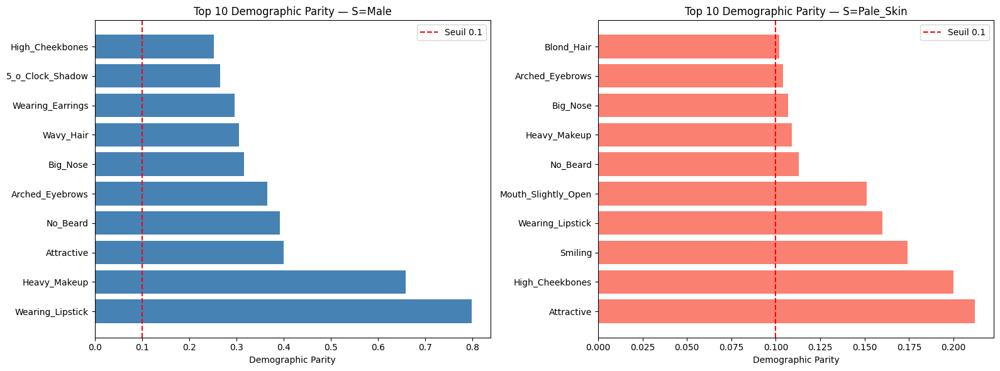

In [66]:
# Visualisation des top biais
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_male = results_male.nlargest(10, 'Demographic_Parity')
axes[0].barh(top_male['Attribute'], top_male['Demographic_Parity'], color='steelblue')
axes[0].set_title('Top 10 Demographic Parity — S=Male')
axes[0].set_xlabel('Demographic Parity')
axes[0].axvline(x=0.1, color='red', linestyle='--', label='Seuil 0.1')
axes[0].legend()

top_skin = results_skin.nlargest(10, 'Demographic_Parity')
axes[1].barh(top_skin['Attribute'], top_skin['Demographic_Parity'], color='salmon')
axes[1].set_title('Top 10 Demographic Parity — S=Pale_Skin')
axes[1].set_xlabel('Demographic Parity')
axes[1].axvline(x=0.1, color='red', linestyle='--', label='Seuil 0.1')
axes[1].legend()

plt.tight_layout()
plt.show()

S = Male
Il y a beaucoup de biais. Wearing_Lipstick et Heavy_Makeup sont quasi exclusivement féminins (DP > 0.65). Le plus problématique est Attractive (DI=0.41) : les femmes sont annotées attractives 2.4 fois plus souvent que les hommes, révélant un biais d'annotation genré fort.

S = Pale_Skin
Les biais sont plus modérés mais tout de même présents. Les personnes à peau pâle sont jugées attractives 42% plus souvent, ce qui traduit un biais ethnocentrique direct des annotateurs. Blond_Hair (DI=1.71) confirme la surreprésentation de traits européens.

En conclusion, un modèle entraîné à prédire Attractive sera structurellement biaisé à la fois par le genre et par la couleur de peau, même sans utiliser Male ou Pale_Skin directement.

## 2. Apprentissage Automatique

Le modèle utilisé pour la classification binaire (souriant ou non) est un ResNet18 pré-entraîné, fine-tuné sur les données de CelebA. Ce choix a été effectué car il donnera de meilleurs résultats qu'un CNN from scratch. Cela permet de se concentrer sur les biais du modèle plutôt que sur son manque de performance. Le ResNet18 n'est pas trop lourd ni trop profond, ce qui limite le risque d'overfitting.
Seule la dernière couche fully connected a été remplacée par une couche linéaire à une sortie, les autres paramètres étant gelés pendant l'entraînement.


Pour les caractéristiques de l'entraînement, les batchs sont de taille 256 et 5 epochs ont été effectuées. Le learning rate est fixé à 1e-3. L'optimiseur est Adam et la loss BCEWithLogitsLoss, car il s'agit d'une classification binaire avec une sortie non normalisée. Cette loss combine sigmoid et binary cross-entropy de manière numériquement stable.


Les images sont redimensionnées en 224x224 et normalisées avec les moyennes et écarts-types ImageNet. De plus, pour améliorer la généralisation, de l'augmentation de données a été appliquée lors de l'entraînement : flip horizontal aléatoire, rotation aléatoire et modification aléatoire de la luminosité et du contraste. Ces augmentations ne sont pas appliquées lors de l'évaluation. Un set de validation a également été mis en place pour surveiller l'overfitting epoch par epoch.


Le modèle a été sauvegardé avec son état, celui de l'optimiseur, ainsi que les prédictions et indices du set de test, pour pouvoir être réutilisé et analysé par la suite. 

Les entrainements étant très long avec un notebook sous Windows (dû à l'impossibilité de faire de la parallélisation avec le CPU pour le traitement des images), ceux-ci ont été réalisé avec le fichier smile_cnn_train.py que vous trouverez sur notre GitHub.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from torchvision.models import resnet18
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries
from smile_cnn_train import CelebADataset, transform_infer, device, CELEBA_DIR

## Description des résultats

 
--- Entraînement saved_models/resnet18.pt ---


Device : cuda
Epochs:   0%|                                                                                  | 0/5 

Epoch 1/5  train loss 0.5001 acc 0.7601  val loss 0.4766 acc 0.7735                                                    
Epochs:  20%|██████████████                                                        | 1/5 

Epoch 2/5  train loss 0.4543 acc 0.7866  val loss 0.4676 acc 0.7789                                                    
Epochs:  40%|█████████████████████████████▏                                           | 2/5 

Epoch 3/5  train loss 0.4476 acc 0.7913  val loss 0.4666 acc 0.7808                                                    
Epochs:  60%|███████████████████████████████████████████▊                             | 3/5 

Epoch 4/5  train loss 0.4416 acc 0.7942  val loss 0.4593 acc 0.7860                                                    
Epochs:  80%|██████████████████████████████████████████████████████████▍              | 4/5 

Epoch 5/5  train loss 0.4400 acc 0.7951  val loss 0.4696 acc 0.7793                                                    
Epochs: 100%|█████████████████████████████████████████████████████████████████████████| 5/5 
                                                                                                                      
Test loss: 0.4710  Test acc: 0.7790

Au cours des 5 epochs, la train loss diminue régulièrement de 0.5001 à 0.4400 et la train accuracy progresse de 0.760 à 0.795, ce qui indique que le modèle apprend correctement. La val loss et la val accuracy restent proches des métriques d'entraînement tout au long des epochs, ce qui confirme l'absence d'overfitting. Nous remarquons une légère remontée de la val loss à l'epoch 5, ce qui suggère que le modèle commence à atteindre sa limite de généralisation avec cette configuration.

Sur le set de test, le modèle atteint une accuracy de 0.779 et une loss de 0.471, cohérentes avec les résultats de validation.

## Evaluation de l'équité

In [ ]:
def load_checkpoint(path, device):
    checkpoint = torch.load(path, weights_only=False)
    model = resnet18()
    model.fc = nn.Linear(512, 1)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint

def get_analysis_indices(checkpoint):
    binary_preds = checkpoint["binary_preds"].squeeze() # all_preds > 0.5
    all_labels = checkpoint["all_labels"].squeeze()
    all_genders = checkpoint["all_genders"].squeeze()

    correct_mask = (binary_preds == all_labels)
    incorrect_mask = (binary_preds != all_labels)
    minority_mask = (all_genders == 1.0) # homme

    idx_correct = (correct_mask & (all_genders == 0.0)).nonzero(as_tuple=True)[0][0].item() # 1ere femme avec prédiction correct
    idx_incorrect = (incorrect_mask & (all_genders == 0.0)).nonzero(as_tuple=True)[0][0].item() # 1ere femme avec prédiction incorrect
    idx_minoritaire = (incorrect_mask & minority_mask).nonzero(as_tuple=True)[0][0].item() # 1er homme avec prédiction incorrect

    return idx_correct, idx_incorrect, idx_minoritaire

In [3]:
model_saved, checkpoint = load_checkpoint("saved_models/resnet18.pt", device)

idx_correct, idx_incorrect, idx_minoritaire = get_analysis_indices(checkpoint)

In [4]:
dataset = CelebADataset(
    csv_file=os.path.join(CELEBA_DIR, "list_attr_celeba.csv"),
    img_dir=os.path.join(CELEBA_DIR, "img_align_celeba/img_align_celeba"),
    transform=None,
    crop=False
)

Accuracy gap : écart d'accuracy Homme vs Femme

FPR (False Positive Rate) : prédit "sourit" alors qu'il ne sourit pas

FNR (False Negative Rate) : prédit "ne sourit pas" alors qu'il sourit 

In [5]:
def fairness_report(all_preds, all_labels, all_genders):
    binary_preds = (all_preds > 0.5).float()
    groups = {"Femmes": 0.0, "Hommes":1.0}
    accs, fprs, fnrs = {}, {}, {}

    for name, g_vals in groups.items():
        mask = (all_genders == g_vals)
        g_preds = binary_preds[mask]
        g_labels = all_labels[mask]

        acc = (g_preds == g_labels).float().mean().item()
        neg_mask = (g_labels == 0)
        pos_mask = (g_labels == 1)

        fpr = (g_preds[neg_mask] == 1).float().mean().item() if neg_mask.sum() > 0 else float("nan")
        fnr = (g_preds[pos_mask] == 0).float().mean().item() if pos_mask.sum() > 0 else float("nan")
        
        accs[name] = acc
        fprs[name] = fpr
        fnrs[name] = fnr

        n = mask.sum().item()
        print(f"  {name:8s} ({n:6d} imgs) Accuracy: {acc:.4f} FPR: {fpr:.4f} FNR: {fnr:.4f}")

    print(f"\nÉcart Accuracy : {abs(accs['Femmes'] - accs['Hommes']):.4f}")
    print(f"Écart FPR : {abs(fprs['Femmes'] - fprs['Hommes']):.4f}")
    print(f"Écart FNR : {abs(fnrs['Femmes'] - fnrs['Hommes']):.4f}")
    


In [6]:
fairness_report(checkpoint["all_preds"], checkpoint["all_labels"], checkpoint["all_genders"])

  Femmes   ( 11887 imgs) Accuracy: 0.7883 FPR: 0.1284 FNR: 0.2820
  Hommes   (  8374 imgs) Accuracy: 0.7659 FPR: 0.1352 FNR: 0.3773

Écart Accuracy : 0.0223
Écart FPR : 0.0068
Écart FNR : 0.0953


## Analyse des résultats

En termes d'accuracy, le modèle performe de façon similaire pour les deux groupes (0.788 vs 0.766), avec un écart de seulement 2.2%.

En revanche, l'analyse des FPR et FNR révèle des biais plus marqués. Le FNR des hommes est supérieur à celui des femmes (0.377 vs 0.282, écart de 9.5%) : le modèle prédit "ne sourit pas" alors que l'homme sourit. À l'inverse, le FPR des femmes est légèrement supérieur à celui des hommes (0.128 vs 0.135, écart de 0.7%) : le modèle a une légère tendance à prédire "sourit" à tort pour les femmes, bien que cet écart soit négligeable.

L'accuracy seule masque ces biais. Le modèle n'a pas appris le même concept pour les deux groupes et à tendance à dire que "un homme ne sourit pas mais une femme si". 

# 3. Explication post-hoc

## GradCAM

In [ ]:
from smile_cnn_train import crop_face

def affiche_gradcam(cam, model_saved, dataset, dataset_idx, titre):
    row = dataset.data.iloc[dataset_idx]
    img_path = os.path.join(dataset.img_dir, row["image_id"])
    img_pil = Image.open(img_path).convert("RGB")

    if dataset.crop:
        img_pil = crop_face(img_pil)

    img_pil = img_pil.resize((224, 224))
    img_np = np.array(img_pil) / 255.0 

    img_tensor = transform_infer(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model_saved(img_tensor).sigmoid().item()

    label = int((row["Smiling"] + 1) / 2)
    gender = "Homme" if row["Male"] == 1 else "Femme"

    targets = [BinaryClassifierOutputTarget(0)]
    grayscale = cam(input_tensor=img_tensor, targets=targets)
    heatmap = show_cam_on_image(img_np.astype(np.float32), grayscale[0], use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(  
        f"{titre}\nLabel: {'Sourit' if label==1 else 'Ne sourit pas'} "  
        f"Pred: {'Sourit' if pred > 0.5 else 'Ne sourit pas'} ({pred:.2f}) {gender}",
        fontsize=11
    )
    axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("GradCAM")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

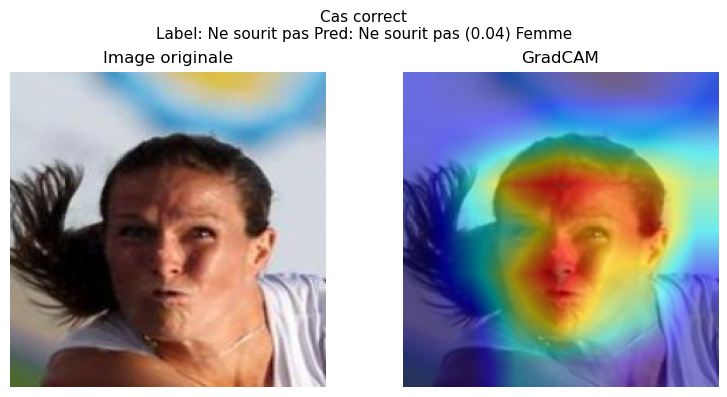

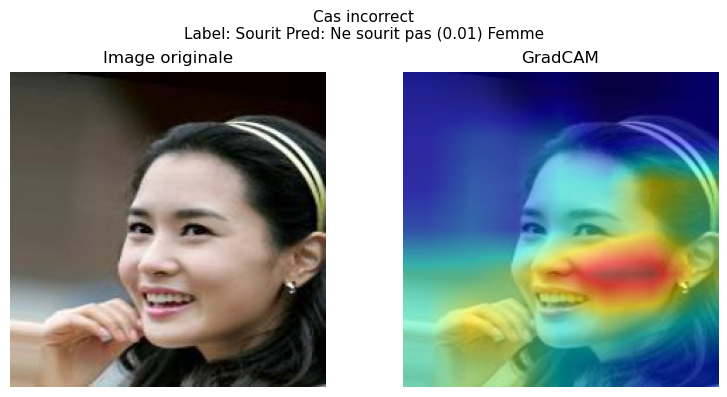

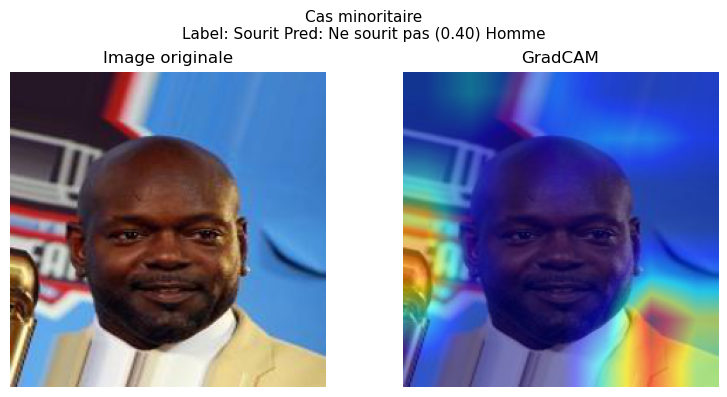

In [19]:
target_layer = [model_saved.layer4[-1]]
cam = GradCAM(model=model_saved, target_layers=target_layer)

affiche_gradcam(cam, model_saved, dataset, checkpoint["test_indices"][idx_correct],     "Cas correct")
affiche_gradcam(cam, model_saved, dataset, checkpoint["test_indices"][idx_incorrect],   "Cas incorrect")
affiche_gradcam(cam, model_saved, dataset, checkpoint["test_indices"][idx_minoritaire], "Cas minoritaire")

Pour le cas correct La heatmap se concentre sur l'ensemble du visage, front et joues.

Pour le cas incorrect le modèle est très confiant (pred=0.01) mais faux. La heatmap se concentre sur la joue droite et les cheveux plutôt que sur la bouche souriante.

Pour le cas minoritaire la heatmap se concentre sur le fond et les épaules plutôt que sur le visage. Le sourire est pourtant visible, mais le modèle n'active pas les bonnes zones. Cela illustre le FNR élevé des hommes. En effet, le modèle n'a pas appris à détecter le sourire masculin de façon fiable, possiblement en raison d'un biais dans les données d'entraînement où les hommes souriants sont sous-représentés.

## LIME

In [20]:
transform_lime = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def model_predict_lime(model_saved, images_np):
    batch = [
        transform_lime(Image.fromarray((img * 255).astype(np.uint8)))
        for img in images_np
    ]
    batch = torch.stack(batch).to(device)
    with torch.no_grad():
        preds = model_saved(batch).sigmoid().cpu().numpy()
    return np.column_stack([1 - preds, preds])


def afficher_lime(model_saved, dataset, dataset_idx, titre):
    row = dataset.data.iloc[dataset_idx]
    img_path = os.path.join(dataset.img_dir, row["image_id"])
    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))

    if dataset.crop:
        from smile_cnn_train import crop_face
        img_pil = crop_face(img_pil)

    img_np = np.array(img_pil) / 255.0 

    label = int((row["Smiling"] + 1) / 2)
    gender = "Homme" if row["Male"] == 1 else "Femme"

    img_tensor = transform_infer(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model_saved(img_tensor).sigmoid().item()

    def predict_fn(images_np):
        return model_predict_lime(model_saved, images_np)

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np.astype(np.double),
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(
        f"{titre}\nLabel: {'Sourit' if label==1 else 'Ne sourit pas'}  "
        f"Pred: {'Sourit' if pred>0.5 else 'Ne sourit pas'} ({pred:.2f}) {gender}",
        fontsize=11
    )
    axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis("off")

    axes[1].imshow(mark_boundaries(temp, mask))
    axes[1].set_title("LIME zones importantes (vert)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

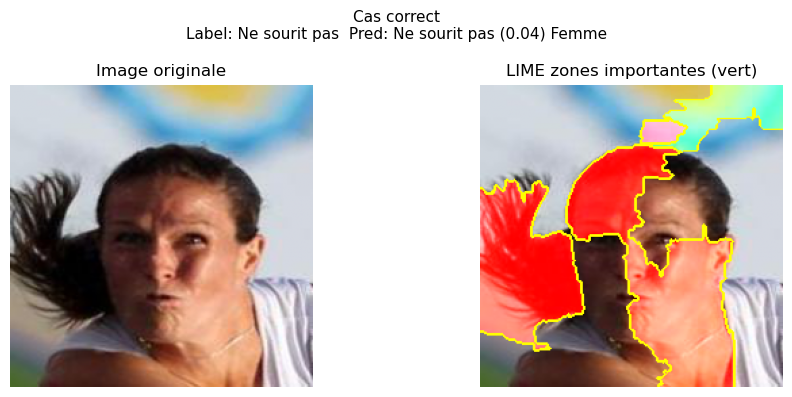

  0%|          | 0/1000 [00:00<?, ?it/s]

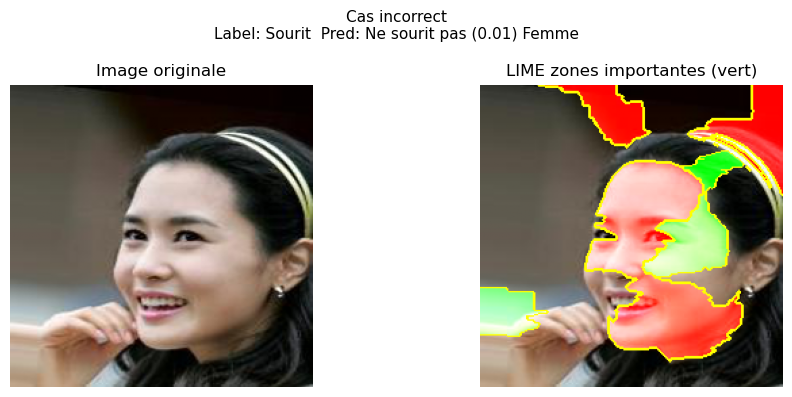

  0%|          | 0/1000 [00:00<?, ?it/s]

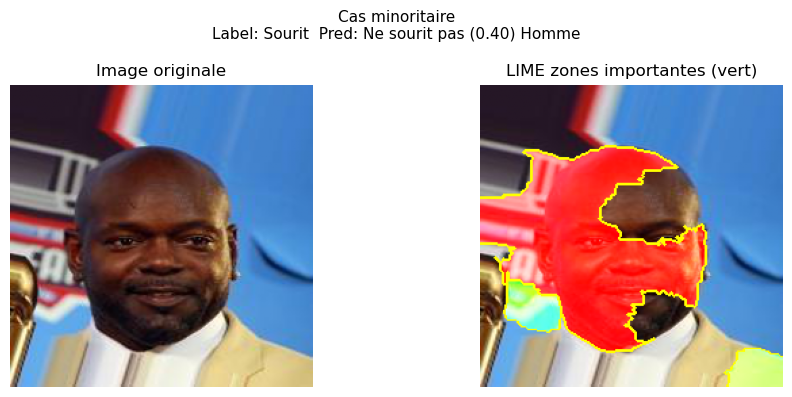

In [21]:
afficher_lime(model_saved, dataset, checkpoint["test_indices"][idx_correct],     "Cas correct")
afficher_lime(model_saved, dataset, checkpoint["test_indices"][idx_incorrect],   "Cas incorrect")
afficher_lime(model_saved, dataset, checkpoint["test_indices"][idx_minoritaire], "Cas minoritaire")

Avec LIME, la zone rouge symbolise la zone qui accentue la prédiction "sourit" et au contraire en vert qui la fait diminuer (penche pour "ne sourit pas").

Pour le cas correct, le modèle s'est servi majoritairement des cheveux de la femme pour prédire "sourit", et le fond est également utilisé pour la prédiction.

Pour le cas incorrect, le visage et le serre-tête ont fait pencher la prédiction vers "sourit" même si le modèle prédit que la personne ne sourit pas.

Enfin, pour le cas minoritaire, le visage est entièrement coloré en rouge mais le modèle prédit quand même "ne sourit pas", le seuil de confiance étant trop faible, celui-ci ne change pas la prédiction.

Le cas correct et incorrect montrent que le modèle s'appuie beaucoup sur le fond pour faire ses prédictions. Les fonds clairs semblent davantage pencher vers la prédiction "sourit" plutôt que "ne sourit pas".

La prédiction sur les hommes montre un manque de confiance, peut-être dû à une plus faible proportion de ceux-ci dans le dataset.


## Intervention sur le traitement des images

## Cropper le fond des images pour se concentrer sur le visage

Pour améliorer les prédictions et réduire les biais, nous avons décidé de cropper l'image. En croppant le visage, on force le modèle à ne voir que le visage celui-ci ne peut plus tricher en utilisant le fond.

Pour cropper l'image, la fonction CascadeClassifier d'OpenCV, basée sur la détection d'objets de Haar, a été utilisée. Une fois le visage détecté l'image est redimmensionnée pour l'encadrer.

--- Entraînement avec crop ---

Device : cuda


Epochs:   0%|                                                                                  | 0/5 

Epoch 1/5  train loss 0.4918 acc 0.7644  val loss 0.4648 acc 0.7797                                                    
Epochs:  20%|██████████████▌                                                          | 1/5 

Epoch 2/5  train loss 0.4475 acc 0.7919  val loss 0.4572 acc 0.7857                                                    
Epochs:  40%|█████████████████████████████▏                                           | 2/5 

Epoch 3/5  train loss 0.4397 acc 0.7967  val loss 0.4532 acc 0.7878                                                    
Epochs:  60%|███████████████████████████████████████████▊                             | 3/5 

Epoch 4/5  train loss 0.4345 acc 0.7987  val loss 0.4541 acc 0.7899                                                    
Epochs:  80%|██████████████████████████████████████████████████████████▍              | 4/5 

Epoch 5/5  train loss 0.4356 acc 0.7985  val loss 0.4503 acc 0.7916                                                    
Epochs: 100%|███████████████████████████████████████████████████████████████████████| 5/5
                                                                                                   
Test loss: 0.4497  Test acc: 0.7902


Ici pour l'entrainement nous remarquons le même phénomène que précédement sans le crop avec toujours une accuracy autour de 0.79.

In [13]:
model_saved_crop, checkpoint_crop = load_checkpoint("saved_models/resnet18_crop.pt", device)
idx_correct_c, idx_incorrect_c, idx_minoritaire_c = get_analysis_indices(checkpoint_crop)

In [14]:
dataset_crop = CelebADataset(
    csv_file=os.path.join(CELEBA_DIR, "list_attr_celeba.csv"),
    img_dir=os.path.join(CELEBA_DIR, "img_align_celeba/img_align_celeba"),
    transform=None,
    crop=True
)

## Evaluation de l'équité

In [15]:
fairness_report(checkpoint_crop["all_preds"], checkpoint_crop["all_labels"], checkpoint_crop["all_genders"])

  Femmes   ( 11887 imgs) Accuracy: 0.8031 FPR: 0.1775 FNR: 0.2131
  Hommes   (  8374 imgs) Accuracy: 0.7719 FPR: 0.1804 FNR: 0.2972

Écart Accuracy : 0.0312
Écart FPR : 0.0029
Écart FNR : 0.0840


## Analyse des résultats

Pour la FPR l'écart reste le même que sans le crop mais l'accuracy augmente (plus proche de 0.8 avec le crop). Pour la FNR cependant il y a toujours un biais homme-femme du même ordre que sans crop.

## GradCAM

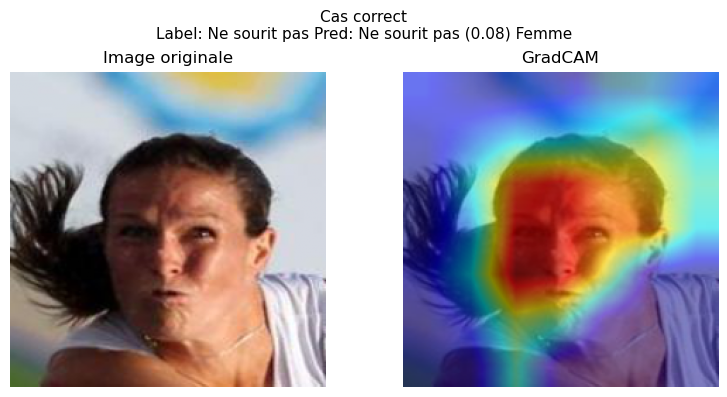

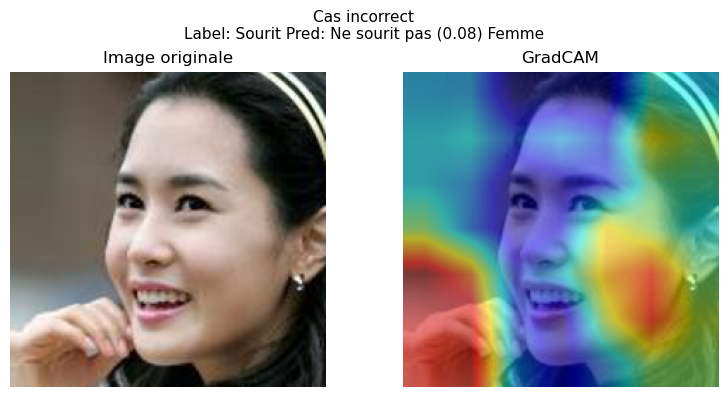

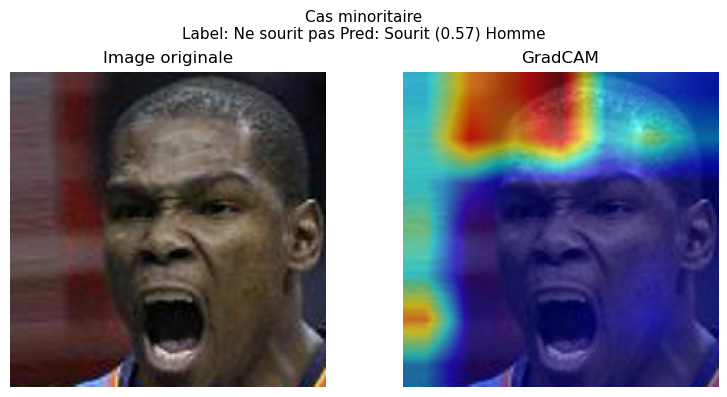

In [24]:
target_layer_crop = [model_saved_crop.layer4[-1]]
cam_crop = GradCAM(model=model_saved_crop, target_layers=target_layer_crop)

affiche_gradcam(cam_crop, model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_correct_c],     "Cas correct")
affiche_gradcam(cam_crop, model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_incorrect_c],   "Cas incorrect")
affiche_gradcam(cam_crop, model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_minoritaire_c], "Cas minoritaire")

Les résultats de GradCAM sont aussi très similaire avec précédement pour le cas correct.

Cependant pour le cas incorrect la joue est toujours prise en compte maiss aussi la main (zone claire ?).

Pour le cas minoritaire le haut de la tête (chauve) rentre beaucoup en jeu, peut-être ici nous voyont apparaître un nouveau biais.

  0%|          | 0/1000 [00:00<?, ?it/s]

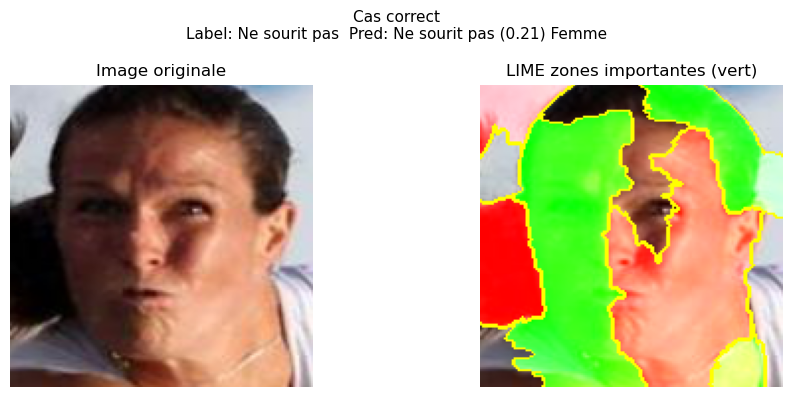

  0%|          | 0/1000 [00:00<?, ?it/s]

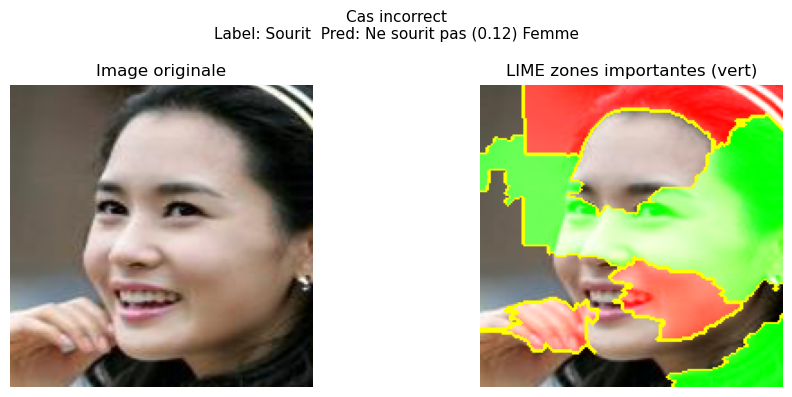

  0%|          | 0/1000 [00:00<?, ?it/s]

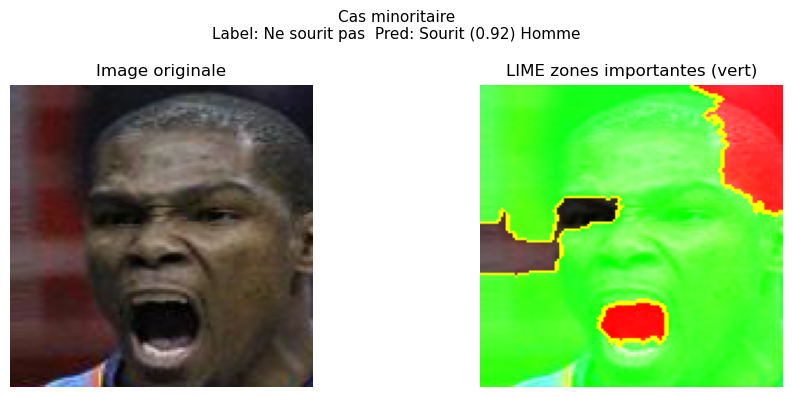

In [23]:
afficher_lime(model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_correct_c],    "Cas correct")
afficher_lime(model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_incorrect_c],  "Cas incorrect")
afficher_lime(model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_minoritaire_c],"Cas minoritaire")

Avec LIME, nous observons des analyses bien différentes de l'entraînement sans crop.


Le cas correct croppé est divisé en deux parties : une zone sombre à gauche et une zone claire à droite. Le modèle a utilisé le côté clair pour prédire "sourit" et le côté sombre pour prédire "ne sourit pas". Nous pouvons voir ici apparaître un nouveau biais de couleur de peau.


Pour le cas incorrect, les cheveux sont encore utilisés pour la prédiction "sourit" mais la bouche l'est également, ce qui représente une amélioration par rapport au modèle sans crop. En revanche, les yeux font pencher la prédiction vers "ne sourit pas".


Enfin, pour le cas minoritaire, la bouche est bien interprétée, le modèle détecte correctement l'ouverture de la bouche comme signe de sourire, mais le reste du visage n'est pas du tout exploité de façon pertinente.

## Conclusion

Le crop a donc partiellement amélioré les prédictions et le modèle commence à utiliser la bouche comme feature pertinente, ce qui n'était pas le cas sans crop. 

Cependant de nouveaux biais apparaissent, notamment un biais de couleur de peau visible sur le cas correct, et les cheveux restent encore utilisés comme feature parasite sur le cas incorrect. 

Le biais de FNR sur les hommes persiste, ce qui suggère que le crop seul ne suffit pas, une augmentation des données masculines ou un rééquilibrage du dataset serait nécessaire pour aller plus loin.

# Partie (3/3) : Données textuelles

## 1. Analyse de données

### importer le dataset

In [18]:
import pandas as pd

df_1= pd.read_csv("Data/all_data_with_identities.csv")
df_1.head()

,Unnamed: 0,id,comment_text,split,created_date,publication_id,parent_id,article_id,rating,funny,...,asian_latino_etc,disability_any,identity_any,num_identities,more_than_one_identity,na_gender,na_orientation,na_religion,na_race,na_disability
0,0,627762,OH yes - Were those evil Christian Missionarie...,test,2016-11-26 15:56:03.862109+00,13,627198.0,152737,approved,0,...,0,0,1,1.0,False,1,1,0,1,1
1,1,5892815,Why is this black racist crap still on the G&M...,val,2017-09-03 23:20:08.226613+00,54,NaN,373428,rejected,0,...,0,0,1,2.0,True,1,1,1,0,1
2,2,416437,even up here.......BLACKS!,train,2016-08-04 16:48:07.175252+00,21,NaN,143025,rejected,0,...,0,0,1,1.0,False,1,1,1,0,1
3,3,5137126,Blame men. There's always an excuse to blame ...,train,2017-04-15 19:00:45.032674+00,54,5136907.0,327125,rejected,0,...,0,0,1,2.0,True,0,1,1,1,1
4,4,855753,And the woman exposing herself saying grab thi...,val,2017-01-18 01:50:57.478867+00,13,849081.0,162008,rejected,0,...,0,0,1,1.0,False,0,1,1,1,1


In [19]:
df_1.columns

Index(['Unnamed: 0', 'id', 'comment_text', 'split', 'created_date',
       'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow',
       'sad', 'likes', 'disagree', 'toxicity', 'severe_toxicity', 'obscene',
       'sexual_explicit', 'identity_attack', 'insult', 'threat', 'male',
       'female', 'transgender', 'other_gender', 'heterosexual',
       'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation',
       'christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist',
       'other_religion', 'black', 'white', 'asian', 'latino',
       'other_race_or_ethnicity', 'physical_disability',
       'intellectual_or_learning_disability', 'psychiatric_or_mental_illness',
       'other_disability', 'identity_annotator_count',
       'toxicity_annotator_count', 'LGBTQ', 'other_religions',
       'asian_latino_etc', 'disability_any', 'identity_any', 'num_identities',
       'more_than_one_identity', 'na_gender', 'na_orientation', 'na_religion',
       'na_race', 

In [20]:
df_text=df_1[["comment_text","toxicity","female","male","black","white","homosexual_gay_or_lesbian"]]

In [21]:
df_text.head()

,comment_text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.00,0.0
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,1.0,0.75,0.0
2,even up here.......BLACKS!,0.688525,0.0,0.0,1.0,0.00,0.0
3,Blame men. There's always an excuse to blame ...,0.545455,1.0,1.0,0.0,0.00,0.0
4,And the woman exposing herself saying grab thi...,0.728571,1.0,0.0,0.0,0.00,0.0


In [22]:
print(df_text.head())

                                        comment_text  toxicity  female  male  \
0  OH yes - Were those evil Christian Missionarie...  0.800000     0.0   0.0   
1  Why is this black racist crap still on the G&M...  0.757143     0.0   0.0   
2                         even up here.......BLACKS!  0.688525     0.0   0.0   
3  Blame men.  There's always an excuse to blame ...  0.545455     1.0   1.0   
4  And the woman exposing herself saying grab thi...  0.728571     1.0   0.0   

   black  white  homosexual_gay_or_lesbian  
0    0.0   0.00                        0.0  
1    1.0   0.75                        0.0  
2    1.0   0.00                        0.0  
3    0.0   0.00                        0.0  
4    0.0   0.00                        0.0  


In [24]:
df_text.dtypes

comment_text                     str
toxicity                     float64
female                       float64
male                         float64
black                        float64
white                        float64
homosexual_gay_or_lesbian    float64
dtype: object

In [27]:
df_text.isnull().sum()

comment_text                 2
toxicity                     0
female                       0
male                         0
black                        0
white                        0
homosexual_gay_or_lesbian    0
dtype: int64

In [28]:
df_text.dropna(inplace=True)

### Indiquer les longueurs (min, max, moy, médiane, percentiles) des textes


In [ ]:
df_text['text_length'] = df_text['comment_text'].apply(len)

stats_longueurs = df_text['text_length'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print("--- Statistiques des longueurs des textes ---")
print(stats_longueurs)

--- Statistiques des longueurs des textes ---
count    447998.000000
mean        351.744514
std         289.323425
min           1.000000
25%         121.000000
50%         257.000000
75%         512.000000
90%         872.000000
95%         984.000000
99%         999.000000
max        1891.000000
Name: text_length, dtype: float64


### Indiquer les distributions des longueurs de texte pour les classes toxiques/non toxiques. Commenter.


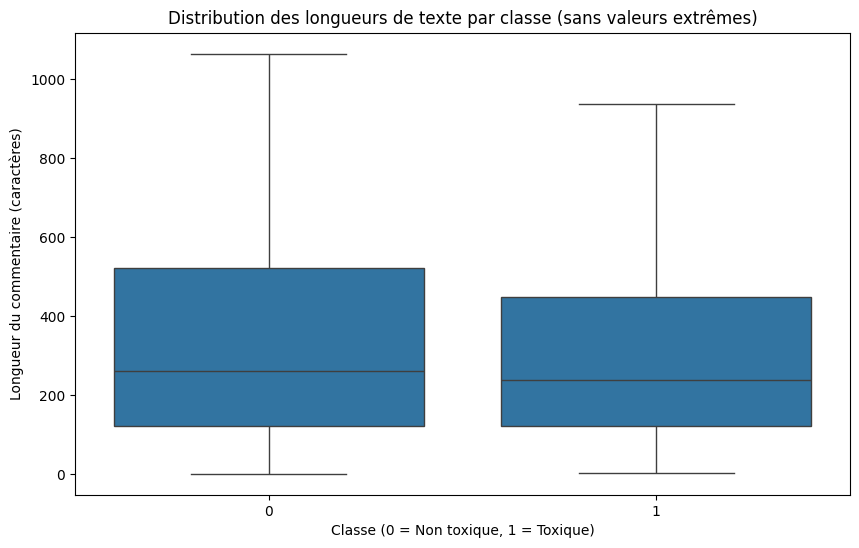

                mean  median   max
is_toxic                          
0         355.289773   260.0  1891
1         324.020947   238.0  1000


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

df_text['is_toxic'] = (df_text['toxicity'] >= 0.5).astype(int)

plt.figure(figsize=(10, 6))
sns.boxplot(x='is_toxic', y='text_length', data=df_text, showfliers=False)
plt.title("Distribution des longueurs de texte par classe (sans valeurs extrêmes)")
plt.xlabel("Classe (0 = Non toxique, 1 = Toxique)")
plt.ylabel("Longueur du commentaire (caractères)")
plt.show()

print(df_text.groupby('is_toxic')['text_length'].agg(['mean', 'median', 'max']))

les distributions sont assez proche mais on remarque tout de même que les commentaires toxiques ont une petite tendance à être plus courts que les commentaire non toxiques.

### Commenter l’équilibre du dataset.

Répartition des classes (%) :
 is_toxic
0    88.662003
1    11.337997
Name: proportion, dtype: float64


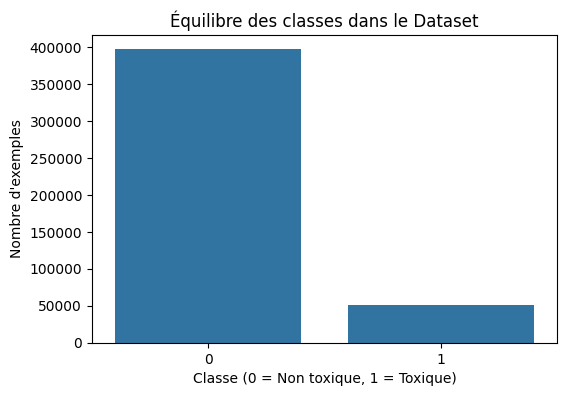

In [31]:
# Calcul de la répartition des classes en pourcentage
equilibre = df_text['is_toxic'].value_counts(normalize=True) * 100
print("Répartition des classes (%) :\n", equilibre)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_toxic', data=df_text)
plt.title("Équilibre des classes dans le Dataset")
plt.xlabel("Classe (0 = Non toxique, 1 = Toxique)")
plt.ylabel("Nombre d'exemples")
plt.show()

On voit que l'on a beaucoup moins de commentaires toxiques que de commentaires non toxiques, ce qui peut poser problème pour l'entraînement d'un modèle de classification. 

### Commenter la distribution de la colonne toxicity (valeur continue)

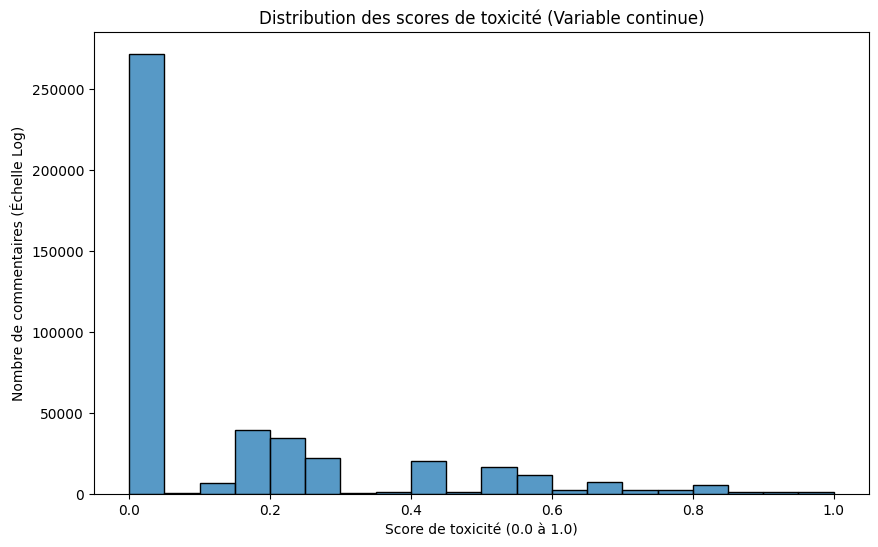

Proportion de textes avec une toxicité de pile 0.0 : 60.60%


In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df_text['toxicity'], bins=20, kde=False)
plt.title("Distribution des scores de toxicité (Variable continue)")
plt.xlabel("Score de toxicité (0.0 à 1.0)")
plt.ylabel("Nombre de commentaires (Échelle Log)") 
plt.show()

zero_prop = (df_text['toxicity'] == 0.0).mean() * 100
print(f"Proportion de textes avec une toxicité de pile 0.0 : {zero_prop:.2f}%")

In [34]:
around_02_prop = ((df_text['toxicity'] >= 0.15) & (df_text['toxicity'] <= 0.25)).mean() * 100
print(f"Proportion de textes avec une toxicité autour de 0.2 : {around_02_prop:.2f}%")

Proportion de textes avec une toxicité autour de 0.2 : 16.44%


On voit que beaucoup de commentaires ne sont pas du tout toxiques (60% des commentaires du dataset ont une toxicité de 0.0). On a un petit batch de commentaire autour de 0.2 de toxicité (16%). La suite des commentaire est répartie de manière décroissante jusqu'à 1.0, avec une petite pointe à 0.4 de toxicité. Donc on voit bien que la non toxicité prédomine suivie par la faible toxicité, et que les commentaires très toxiques sont assez rares.

## 2. Prétraitement et visualisation

In [3]:
from collections import Counter
from pathlib import Path
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from tqdm.auto import tqdm

tqdm.pandas()

for corpus in ['punkt', 'punkt_tab', 'wordnet', 'stopwords', 'omw-1.4']:
    nltk.download(corpus, quiet=True)

dataset_path: Path = Path("../data/google_comments/all_data_with_identities.csv")

if not dataset_path.exists():
    raise FileNotFoundError("Dataset not found")

df = pd.read_csv(str(dataset_path))
df.dtypes

Unnamed: 0                               int64
id                                       int64
comment_text                               str
split                                      str
created_date                               str
publication_id                           int64
parent_id                              float64
article_id                               int64
rating                                     str
funny                                    int64
wow                                      int64
sad                                      int64
likes                                    int64
disagree                                 int64
toxicity                               float64
severe_toxicity                        float64
obscene                                float64
sexual_explicit                        float64
identity_attack                        float64
insult                                 float64
threat                                 float64
male         

In [4]:
df.dtypes

Unnamed: 0                               int64
id                                       int64
comment_text                               str
split                                      str
created_date                               str
publication_id                           int64
parent_id                              float64
article_id                               int64
rating                                     str
funny                                    int64
wow                                      int64
sad                                      int64
likes                                    int64
disagree                                 int64
toxicity                               float64
severe_toxicity                        float64
obscene                                float64
sexual_explicit                        float64
identity_attack                        float64
insult                                 float64
threat                                 float64
male         

In [5]:
len(df)

448000

In [6]:
# --- Toutes les colonnes du dataset ---
COL_ID                          = 'id'
COL_TEXT                        = 'comment_text'
COL_SPLIT                       = 'split'
COL_CREATED                     = 'created_date'
COL_PUBLICATION_ID              = 'publication_id'
COL_PARENT_ID                   = 'parent_id'
COL_ARTICLE_ID                  = 'article_id'
COL_RATING                      = 'rating'
COL_FUNNY                       = 'funny'
COL_WOW                         = 'wow'
COL_SAD                         = 'sad'
COL_LIKES                       = 'likes'
COL_DISAGREE                    = 'disagree'
COL_TOXICITY                    = 'toxicity'
COL_SEVERE_TOXICITY             = 'severe_toxicity'
COL_OBSCENE                     = 'obscene'
COL_SEXUAL_EXPLICIT             = 'sexual_explicit'
COL_IDENTITY_ATTACK             = 'identity_attack'
COL_INSULT                      = 'insult'
COL_THREAT                      = 'threat'
COL_MALE                        = 'male'
COL_FEMALE                      = 'female'
COL_TRANSGENDER                 = 'transgender'
COL_OTHER_GENDER                = 'other_gender'
COL_HETEROSEXUAL                = 'heterosexual'
COL_HOMOSEXUAL                  = 'homosexual_gay_or_lesbian'
COL_BISEXUAL                    = 'bisexual'
COL_OTHER_SEXUAL_ORIENTATION    = 'other_sexual_orientation'
COL_CHRISTIAN                   = 'christian'
COL_JEWISH                      = 'jewish'
COL_MUSLIM                      = 'muslim'
COL_HINDU                       = 'hindu'
COL_BUDDHIST                    = 'buddhist'
COL_ATHEIST                     = 'atheist'
COL_OTHER_RELIGION              = 'other_religion'
COL_BLACK                       = 'black'
COL_WHITE                       = 'white'
COL_ASIAN                       = 'asian'
COL_LATINO                      = 'latino'
COL_OTHER_RACE                  = 'other_race_or_ethnicity'
COL_PHYSICAL_DISABILITY         = 'physical_disability'
COL_INTELLECTUAL_DISABILITY     = 'intellectual_or_learning_disability'
COL_PSYCHIATRIC_DISABILITY      = 'psychiatric_or_mental_illness'
COL_OTHER_DISABILITY            = 'other_disability'
COL_IDENTITY_ANNOTATOR_COUNT    = 'identity_annotator_count'
COL_TOXICITY_ANNOTATOR_COUNT    = 'toxicity_annotator_count'
COL_LGBTQ                       = 'LGBTQ'
COL_OTHER_RELIGIONS             = 'other_religions'
COL_ASIAN_LATINO_ETC            = 'asian_latino_etc'
COL_DISABILITY_ANY              = 'disability_any'
COL_IDENTITY_ANY                = 'identity_any'
COL_NUM_IDENTITIES              = 'num_identities'
COL_MORE_THAN_ONE_IDENTITY      = 'more_than_one_identity'
COL_NA_GENDER                   = 'na_gender'
COL_NA_ORIENTATION              = 'na_orientation'
COL_NA_RELIGION                 = 'na_religion'
COL_NA_RACE                     = 'na_race'
COL_NA_DISABILITY               = 'na_disability'

# --- Colonnes utilisées dans l'analyse ---
ANALYSIS_COLS = [
    COL_TEXT,
    COL_TOXICITY,
    COL_FEMALE,
    COL_MALE,
    COL_BLACK,
    COL_WHITE,
    COL_HOMOSEXUAL,
]

DEMOGRAPHIC_COLS = [c for c in ANALYSIS_COLS if c not in (COL_TEXT, COL_TOXICITY)]


In [7]:
df = df[ANALYSIS_COLS]
df.head()


,comment_text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.00,0.0
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,1.0,0.75,0.0
2,even up here.......BLACKS!,0.688525,0.0,0.0,1.0,0.00,0.0
3,Blame men. There's always an excuse to blame ...,0.545455,1.0,1.0,0.0,0.00,0.0
4,And the woman exposing herself saying grab thi...,0.728571,1.0,0.0,0.0,0.00,0.0


In [8]:
df.head(5)

,comment_text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.00,0.0
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,1.0,0.75,0.0
2,even up here.......BLACKS!,0.688525,0.0,0.0,1.0,0.00,0.0
3,Blame men. There's always an excuse to blame ...,0.545455,1.0,1.0,0.0,0.00,0.0
4,And the woman exposing herself saying grab thi...,0.728571,1.0,0.0,0.0,0.00,0.0


### Nettoyage du dataset

In [9]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)                     # mentions @user
    text = re.sub(r'[^\w\s]', ' ', text)                 # ponctuation → espace
    text = re.sub(r'\s+', ' ', text).strip()             # espaces multiples
    return text

df[COL_TEXT] = df['comment_text'].map(clean_text)

# Binarisation de la colonne toxicity au seuil 0.5
df['label'] = (df['toxicity'] >= 0.5).astype(int)

print(f"Commentaires toxiques   : {df['label'].sum():,} ({df['label'].mean():.1%})")
print(f"Commentaires non-toxiques: {(df['label']==0).sum():,} ({(df['label']==0).mean():.1%})")


Commentaires toxiques   : 50,794 (11.3%)
Commentaires non-toxiques: 397,206 (88.7%)


### Tokenisation

In [10]:
COL_TOKENIZED = "tok"
COL_N_TOKENS  = "n_tokens"
COL_LEMMAS    = "lemmas"

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_and_lemmatize(text: str) -> tuple[list[str], list[str]]:
    tokens = word_tokenize(text)
    lemmas = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in STOP_WORDS and len(t) > 1
    ]
    return tokens, lemmas

print("Tokenisation + lemmatisation...")
results = [tokenize_and_lemmatize(t) for t in tqdm(df[COL_TEXT], desc="NLTK tokenize/lemmatize")]

df[COL_TOKENIZED] = [r[0] for r in results]
df[COL_N_TOKENS]  = [len(r[0]) for r in results]
df[COL_LEMMAS]    = [r[1] for r in results]

print(f"Tokens moyen / commentaire : {df[COL_N_TOKENS].mean():.1f}")
print(f"Médiane                    : {df[COL_N_TOKENS].median():.0f}")
print(f"Max                        : {df[COL_N_TOKENS].max()}")


Tokenisation + lemmatisation...


NLTK tokenize/lemmatize:   0%|          | 0/448000 [00:00<?, ?it/s]

Tokens moyen / commentaire : 61.9
Médiane                    : 46
Max                        : 314


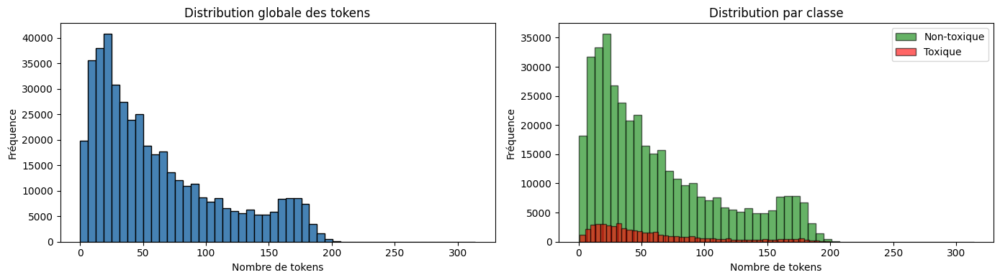

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[COL_N_TOKENS], bins=50, color='steelblue', edgecolor='black')
axes[0].set(title='Distribution globale des tokens', xlabel='Nombre de tokens', ylabel='Fréquence')

for label, color, lbl in [(0, 'green', 'Non-toxique'), (1, 'red', 'Toxique')]:
    subset = df[df['label'] == label][COL_N_TOKENS]
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=lbl, edgecolor='black')

axes[1].set(title='Distribution par classe', xlabel='Nombre de tokens', ylabel='Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
df[[COL_TEXT, COL_TOKENIZED, COL_LEMMAS]].head(10)

,comment_text,tok,lemmas
0,oh yes were those evil christian missionaries ...,"[oh, yes, were, those, evil, christian, missio...","[oh, yes, evil, christian, missionary, many, s..."
1,why is this black racist crap still on the g m...,"[why, is, this, black, racist, crap, still, on...","[black, racist, crap, still, website, stopped,..."
2,even up here blacks,"[even, up, here, blacks]","[even, black]"
3,blame men there s always an excuse to blame me...,"[blame, men, there, s, always, an, excuse, to,...","[blame, men, always, excuse, blame, men, failu..."
4,and the woman exposing herself saying grab thi...,"[and, the, woman, exposing, herself, saying, g...","[woman, exposing, saying, grab, pussy, offer, ..."
5,you have no business making any comments on th...,"[you, have, no, business, making, any, comment...","[business, making, comment, site, craig, bigot..."
6,let s get the black folks and the white folks ...,"[let, s, get, the, black, folks, and, the, whi...","[let, get, black, folk, white, folk, others, t..."
7,i guess the issue is people not willing to put...,"[i, guess, the, issue, is, people, not, willin...","[guess, issue, people, willing, put, stupid, c..."
8,jackjohnson5 and they say trump supporters are...,"[jackjohnson5, and, they, say, trump, supporte...","[say, trump, supporter, uneducated, necessaril..."
9,trump could accidently push a button and canad...,"[trump, could, accidently, push, a, button, an...","[trump, could, accidently, push, button, canad..."


### Regroupement par nuage de mots

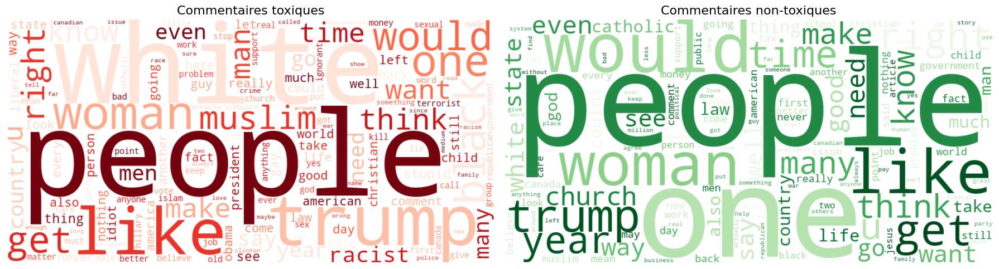

In [13]:
wc_config = dict(width=800, height=400, max_words=150, background_color='white')

def get_freq(df_subset: pd.DataFrame, col: str = COL_LEMMAS) -> Counter:
    all_tokens = [t for tokens in df_subset[col] for t in tokens]
    return Counter(all_tokens)

freq_toxic    = get_freq(df[df['label'] == 1])
freq_nontoxic = get_freq(df[df['label'] == 0])

# Nuages de mots séparés : toxique vs non-toxique
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc_t = WordCloud(colormap='Reds',   **wc_config).generate_from_frequencies(freq_toxic)
wc_n = WordCloud(colormap='Greens', **wc_config).generate_from_frequencies(freq_nontoxic)

axes[0].imshow(wc_t, interpolation='bilinear'); axes[0].axis('off')
axes[0].set_title('Commentaires toxiques', fontsize=16)
axes[1].imshow(wc_n, interpolation='bilinear'); axes[1].axis('off')
axes[1].set_title('Commentaires non-toxiques', fontsize=16)

plt.tight_layout()
plt.show()


Top 20 termes ambigus (score proche de 1 = présent également dans les deux classes) :
      term  freq_toxic  freq_nontoxic  ambiguity_score
     front    0.000242       0.000242         0.999743
     speak    0.000410       0.000410         0.999633
      come    0.001640       0.001640         0.999554
      died    0.000191       0.000191         0.999255
      fact    0.001805       0.001803         0.999133
        us    0.000113       0.000113         0.999035
acceptable    0.000113       0.000113         0.998807
   imagine    0.000262       0.000263         0.998571
      army    0.000115       0.000115         0.998307
      even    0.002925       0.002931         0.997870
    middle    0.000473       0.000472         0.997047
    unlike    0.000123       0.000123         0.996936
     whole    0.000510       0.000511         0.996589
     photo    0.000152       0.000152         0.996424
     thing    0.002440       0.002431         0.996040
  campaign    0.000401       0.000

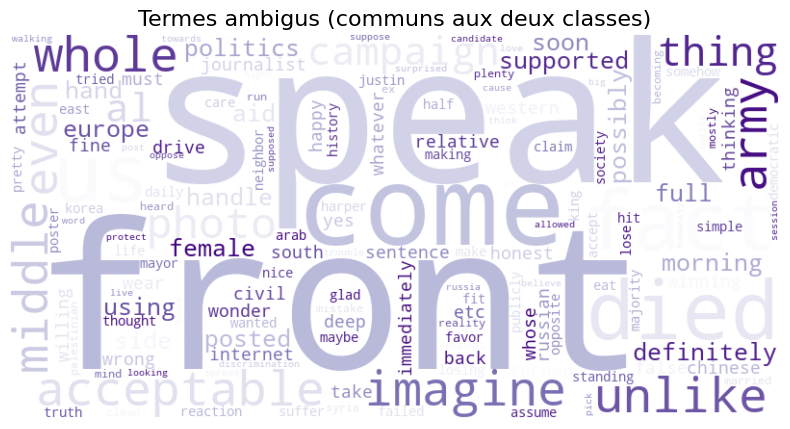

In [14]:
# Termes ambigus : communs aux deux classes avec un ratio de fréquence proche de 1
total_toxic    = sum(freq_toxic.values())
total_nontoxic = sum(freq_nontoxic.values())
common_terms   = set(freq_toxic) & set(freq_nontoxic)

ambiguity_records = []
for term in common_terms:
    tf_t  = freq_toxic[term]    / total_toxic
    tf_nt = freq_nontoxic[term] / total_nontoxic
    ratio = min(tf_t, tf_nt) / max(tf_t, tf_nt)
    ambiguity_records.append({
        'term': term,
        'freq_toxic': tf_t,
        'freq_nontoxic': tf_nt,
        'ambiguity_score': ratio,
    })

df_ambig = (pd.DataFrame(ambiguity_records)
              .sort_values('ambiguity_score', ascending=False)
              .query('freq_toxic > 1e-4 and freq_nontoxic > 1e-4')
              .reset_index(drop=True))

print("Top 20 termes ambigus (score proche de 1 = présent également dans les deux classes) :")
print(df_ambig.head(20).to_string(index=False))

wc_ambig = WordCloud(colormap='Purples', **wc_config).generate_from_frequencies(
    dict(zip(df_ambig['term'], df_ambig['ambiguity_score']))
)

plt.figure(figsize=(10, 5))
plt.imshow(wc_ambig, interpolation='bilinear')
plt.axis('off')
plt.title('Termes ambigus (communs aux deux classes)', fontsize=16)
plt.show()


### Analyse TF-IDF par classe

In [15]:
df['lemmas_str'] = [' '.join(lemmas) for lemmas in tqdm(df[COL_LEMMAS], desc="Jointure lemmes")]

N_FEATURES = 20_000

print("Calcul TF-IDF...")
vectorizer = TfidfVectorizer(max_features=N_FEATURES, min_df=5, sublinear_tf=True)
tfidf_matrix = vectorizer.fit_transform(tqdm(df['lemmas_str'], desc="TF-IDF vectorisation"))
vocab = vectorizer.get_feature_names_out()

idx_toxic    = df[df['label'] == 1].index
idx_nontoxic = df[df['label'] == 0].index

mean_tfidf_toxic    = tfidf_matrix[idx_toxic].mean(axis=0).A1
mean_tfidf_nontoxic = tfidf_matrix[idx_nontoxic].mean(axis=0).A1

df_tfidf = pd.DataFrame({
    'term':           vocab,
    'tfidf_toxic':    mean_tfidf_toxic,
    'tfidf_nontoxic': mean_tfidf_nontoxic,
})

TOP_N = 20

df_tfidf['ratio_toxic']    = df_tfidf['tfidf_toxic']    / (df_tfidf['tfidf_nontoxic'] + 1e-9)
df_tfidf['ratio_nontoxic'] = df_tfidf['tfidf_nontoxic'] / (df_tfidf['tfidf_toxic']    + 1e-9)

top_toxic    = df_tfidf.nlargest(TOP_N, 'tfidf_toxic')[['term','tfidf_toxic','tfidf_nontoxic','ratio_toxic']]
top_nontoxic = df_tfidf.nlargest(TOP_N, 'tfidf_nontoxic')[['term','tfidf_nontoxic','tfidf_toxic','ratio_nontoxic']]

print("=== Top termes TF-IDF élevé UNIQUEMENT dans la classe TOXIQUE ===")
print(top_toxic.to_string(index=False))
print()
print("=== Top termes TF-IDF élevé UNIQUEMENT dans la classe NON-TOXIQUE ===")
print(top_nontoxic.to_string(index=False))


Jointure lemmes:   0%|          | 0/448000 [00:00<?, ?it/s]

Calcul TF-IDF...


TF-IDF vectorisation:   0%|          | 0/448000 [00:00<?, ?it/s]

=== Top termes TF-IDF élevé UNIQUEMENT dans la classe TOXIQUE ===
  term  tfidf_toxic  tfidf_nontoxic  ratio_toxic
 white     0.025826        0.007762     3.327390
 trump     0.020788        0.011909     1.745577
people     0.018941        0.014647     1.293175
 black     0.018922        0.004547     4.161054
 woman     0.016645        0.012940     1.286308
  like     0.016478        0.013440     1.226036
muslim     0.015369        0.005597     2.745968
stupid     0.014454        0.000265    54.442163
racist     0.012611        0.002398     5.258902
   one     0.012567        0.014270     0.880628
 would     0.012372        0.014384     0.860168
   get     0.012320        0.011230     1.096992
   man     0.011961        0.008049     1.486040
 right     0.010661        0.010609     1.004934
   gay     0.010284        0.002475     4.155107
 think     0.009986        0.010106     0.988046
  know     0.009776        0.009959     0.981603
 idiot     0.009755        0.000081   121.138892
  w

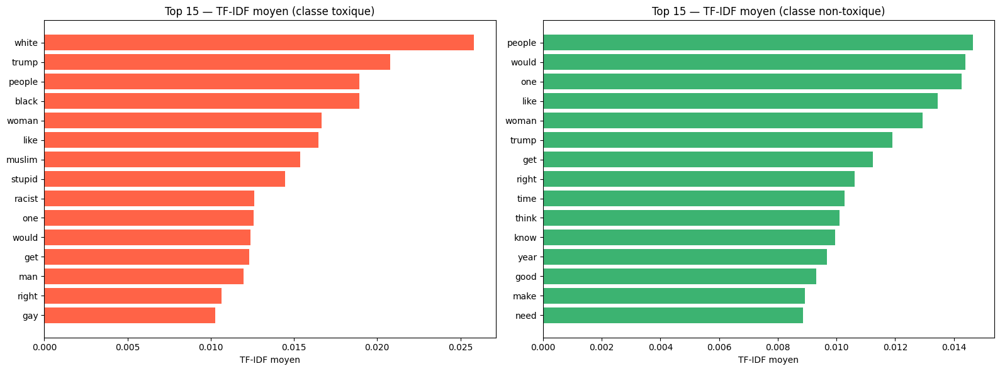

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_t = df_tfidf.nlargest(15, 'tfidf_toxic').sort_values('tfidf_toxic')
axes[0].barh(top_t['term'], top_t['tfidf_toxic'], color='tomato')
axes[0].set(title='Top 15 — TF-IDF moyen (classe toxique)', xlabel='TF-IDF moyen')

top_n = df_tfidf.nlargest(15, 'tfidf_nontoxic').sort_values('tfidf_nontoxic')
axes[1].barh(top_n['term'], top_n['tfidf_nontoxic'], color='mediumseagreen')
axes[1].set(title='Top 15 — TF-IDF moyen (classe non-toxique)', xlabel='TF-IDF moyen')

plt.tight_layout()
plt.show()


### Analyse des groupes démographiques

In [17]:
THRESHOLD = 0.5

records = []
for col in DEMOGRAPHIC_COLS:
    mask = df[col].notna() & (df[col] >= THRESHOLD)
    subset = df[mask]
    n = len(subset)
    if n == 0:
        continue
    tox_rate = subset['label'].mean()
    records.append({
        'groupe': col,
        'n_exemples': n,
        'taux_toxicite': tox_rate,
    })

df_demo = (pd.DataFrame(records)
             .sort_values('taux_toxicite', ascending=False)
             .reset_index(drop=True))

print(df_demo.to_string(index=False))


                   groupe  n_exemples  taux_toxicite
                    black       16420       0.315530
homosexual_gay_or_lesbian       12062       0.282789
                    white       27534       0.282560
                     male       48870       0.150501
                   female       58584       0.136607


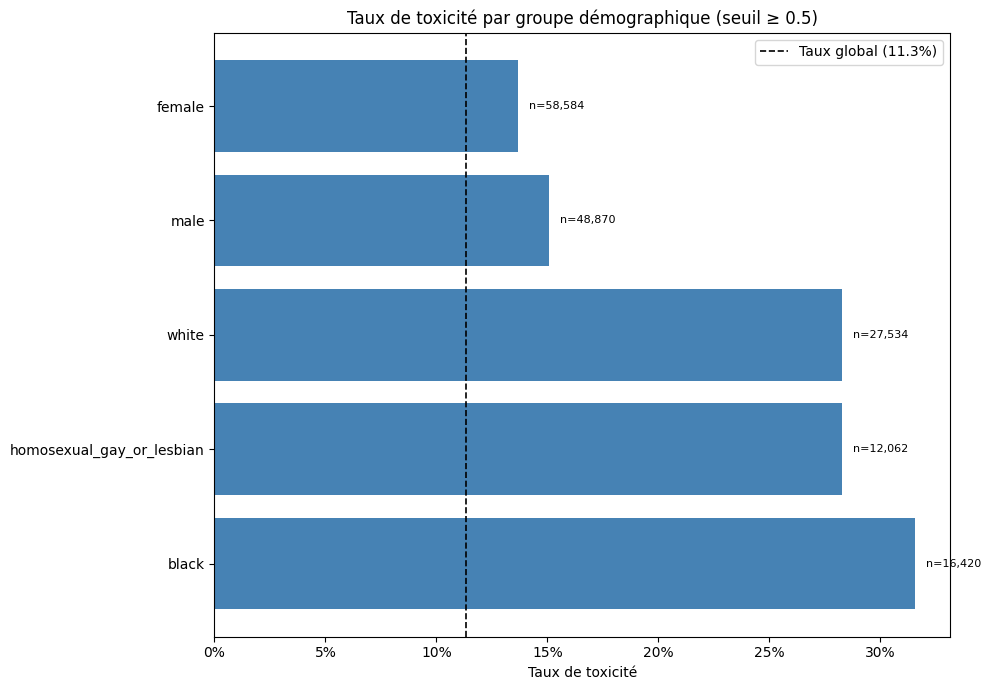

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['tomato' if r > 0.5 else 'steelblue' for r in df_demo['taux_toxicite']]
bars = ax.barh(df_demo['groupe'], df_demo['taux_toxicite'], color=colors)

global_tox = df['label'].mean()
ax.axvline(global_tox, color='black', linestyle='--', linewidth=1.2,
           label=f'Taux global ({global_tox:.1%})')

for bar, n in zip(bars, df_demo['n_exemples']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'n={n:,}', va='center', fontsize=8)

ax.set(xlabel='Taux de toxicité', title='Taux de toxicité par groupe démographique (seuil ≥ 0.5)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()


## 3. Classification de toxicité


Label prédit : `toxicity` binarisé au seuil 0.5 (0 = non toxique, 1 = toxique)  
Séparation : 80 % train / 20 % test  
Modèle choisi : Logistic Regression + TF-IDF

### Justification du choix du modèle

Nous choisissons la Régression Logistique combinée à une vectorisation TF-IDF (réalisée dans la partie 2) pour les raisons suivantes :

1. Adapté au texte : TF-IDF transforme les textes en vecteurs numériques et la régression logistique fonctionne très bien avec ce type de données.

2. Efficace avec beaucoup de données. Avec un grand nombre d'exemples (~448 000), la régression logistique est rapide et consomme moins de mémoire que d'autres modèles comme les arbres. 

3. Les résultats sont interprétables : on peut voir quels mots sont les plus liés à la toxicité.

In [19]:
import re
from pathlib import Path

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
)

import joblib
from tqdm.auto import tqdm

tqdm.pandas()

for corpus in ['punkt', 'punkt_tab', 'wordnet', 'stopwords', 'omw-1.4']:
    nltk.download(corpus, quiet=True)

RANDOM_STATE = 56
THRESHOLD    = 0.5       # seuil de toxicité
TEST_SIZE    = 0.20
N_FEATURES   = 20_000   # même valeur que la partie 2

In [5]:
dataset_path = Path("../data/google_comments/all_data_with_identities.csv")

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset introuvable : {dataset_path}")

ANALYSIS_COLS = [
    'comment_text', 'toxicity',
    'female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian',
]

df = pd.read_csv(str(dataset_path), usecols=ANALYSIS_COLS)

# Label binaire (comme dans la partie 2)
df['label'] = (df['toxicity'] >= THRESHOLD).astype(int)

print(f"Taille du dataset : {len(df):,} exemples")
print(f"Répartition des classes :\n{df['label'].value_counts()}")
df.head(3)

Taille du dataset : 448,000 exemples
Répartition des classes :
label
0    397206
1     50794
Name: count, dtype: int64


,comment_text,toxicity,male,female,homosexual_gay_or_lesbian,black,white,label
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.0,0.00,1
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,0.0,1.0,0.75,1
2,even up here.......BLACKS!,0.688525,0.0,0.0,0.0,1.0,0.00,1


### Prétraitement : identique à la partie 2 pour avoir les même représentations TF-IDF.

In [6]:
print(type(df))

<class 'pandas.DataFrame'>


In [7]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)          # URLs
    text = re.sub(r'@\w+', '', text)                       # mentions
    text = re.sub(r'[^\w\s]', ' ', text)                   # ponctuation
    text = re.sub(r'\s+', ' ', text).strip()               # espaces multiples
    return text

def lemmatize(text: str) -> str:
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and t.isalpha()]
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

print("Nettoyage en cours…")
df['text_clean']  = df['comment_text'].apply(clean_text)

print("Lemmatisation en cours…")
df['text_lemmas'] = df['text_clean'].apply(lemmatize)

print("Prétraitement terminé.")
print(type(df))
df[['comment_text', 'text_clean', 'text_lemmas']].head(3)

Nettoyage en cours…
Lemmatisation en cours…
Prétraitement terminé.
<class 'pandas.DataFrame'>


,comment_text,text_clean,text_lemmas
0,OH yes - Were those evil Christian Missionarie...,oh yes were those evil christian missionaries ...,oh yes evil christian missionary many slaughte...
1,Why is this black racist crap still on the G&M...,why is this black racist crap still on the g m...,black racist crap still g website stopped talk...
2,even up here.......BLACKS!,even up here blacks,even black


### Séparation Train / Test (80-20)

In [8]:
X = df['text_lemmas']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,          # préserve la proportion des classes
)

print(f"Train : {len(X_train):,} exemples")
print(f"Test  : {len(X_test):,} exemples")
print(f"\nRépartition dans le train :")
print(y_train.value_counts(normalize=True).rename({0: 'non-toxique', 1: 'toxique'}))
print(f"\nRépartition dans le test :")
print(y_test.value_counts(normalize=True).rename({0: 'non-toxique', 1: 'toxique'}))

Train : 358,400 exemples
Test  : 89,600 exemples

Répartition dans le train :
label
non-toxique    0.886621
toxique        0.113379
Name: proportion, dtype: float64

Répartition dans le test :
label
non-toxique    0.886618
toxique        0.113382
Name: proportion, dtype: float64


### Vectorisation TF-IDF

On utilise les mêmes paramètres que dans la partie 2 (`max_features=20_000`, `min_df=5`, `sublinear_tf=True`).  

In [9]:
vectorizer = TfidfVectorizer(
    max_features=N_FEATURES,
    min_df=5,
    sublinear_tf=True,    
    ngram_range=(1, 2),
)

print("Ajustement du TF-IDF sur le train…")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Matrice train : {X_train_tfidf.shape}")
print(f"Matrice test  : {X_test_tfidf.shape}")
print(f"Vocabulaire   : {len(vectorizer.vocabulary_):,} tokens")

Ajustement du TF-IDF sur le train…
Matrice train : (358400, 20000)
Matrice test  : (89600, 20000)
Vocabulaire   : 20,000 tokens


In [21]:
joblib.dump(X_train_tfidf, "x_tfidf.pkl")

['x_tfidf.pkl']

### Entraînement : régression Logistique

In [10]:
clf = LogisticRegression(
    C=1.0,              
    penalty='l2',       
    solver='saga',      # supporte L1/L2, efficace sur grands datasets
    max_iter=1000,
    class_weight='balanced',  # compense le déséquilibre des classes
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Entraînement en cours…")
clf.fit(X_train_tfidf, y_train)
print("Entraînement terminé.")

Entraînement en cours…
Entraînement terminé.


### Évaluation

In [11]:
y_pred      = clf.predict(X_test_tfidf)
y_pred_prob = clf.predict_proba(X_test_tfidf)[:, 1]

print(" Résultat de la classification (seuil = 0.5) :")
print(classification_report(y_test, y_pred, target_names=['Non-toxique', 'Toxique']))

roc_auc = roc_auc_score(y_test, y_pred_prob)
avg_pre = average_precision_score(y_test, y_pred_prob)
print(f"ROC-AUC              : {roc_auc:.4f}")
print(f"Average Precision    : {avg_pre:.4f}")

 Résultat de la classification (seuil = 0.5) :
              precision    recall  f1-score   support

 Non-toxique       0.97      0.87      0.92     79441
     Toxique       0.45      0.79      0.57     10159

    accuracy                           0.87     89600
   macro avg       0.71      0.83      0.75     89600
weighted avg       0.91      0.87      0.88     89600

ROC-AUC              : 0.9153
Average Precision    : 0.6635


In [ ]:
joblib.dump(clf, "logistic_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl") 

['vectorizer.pkl']

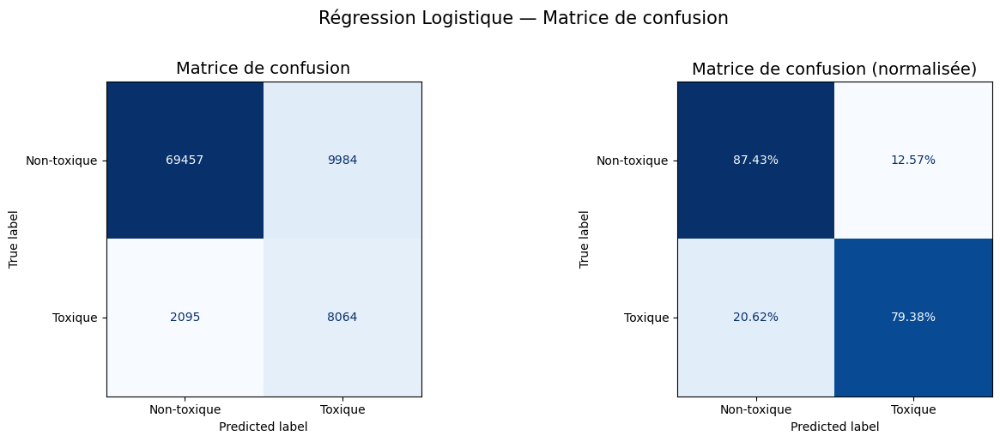

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-toxique', 'Toxique'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion', fontsize=14)

# Matrice de confusion normalisée
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_n  = ConfusionMatrixDisplay(cm_norm, display_labels=['Non-toxique', 'Toxique'])
disp_n.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Matrice de confusion (normalisée)', fontsize=14)

plt.suptitle('Régression Logistique — Matrice de confusion', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

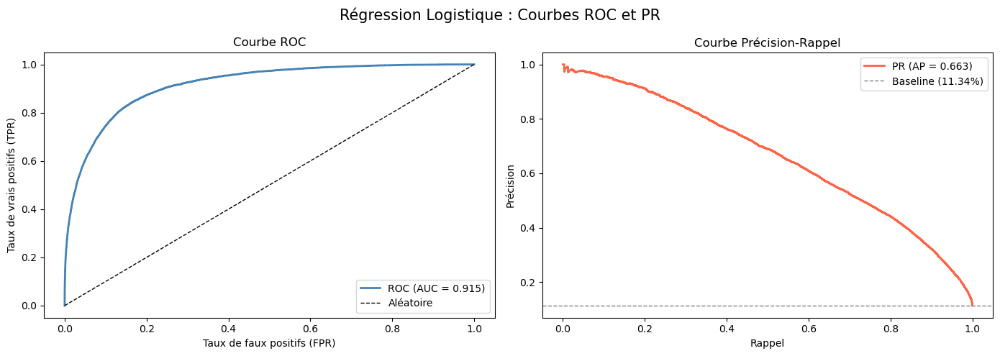

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
axes[0].set(xlabel='Taux de faux positifs (FPR)',
            ylabel='Taux de vrais positifs (TPR)',
            title='Courbe ROC')
axes[0].legend()

# Courbe Précision - rappel
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
axes[1].plot(rec, prec, color='tomato', lw=2,
             label=f'PR (AP = {avg_pre:.3f})')
baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline ({baseline:.2%})')
axes[1].set(xlabel='Rappel', ylabel='Précision',
            title='Courbe Précision-Rappel')
axes[1].legend()

plt.suptitle('Régression Logistique : Courbes ROC et PR', fontsize=15)
plt.tight_layout()
plt.show()

### Termes les plus discriminants

Les coefficients de la régression logistique sont directement interprétables : un coefficient positif élevé signifie que le terme est fortement prédictif de la toxicité.

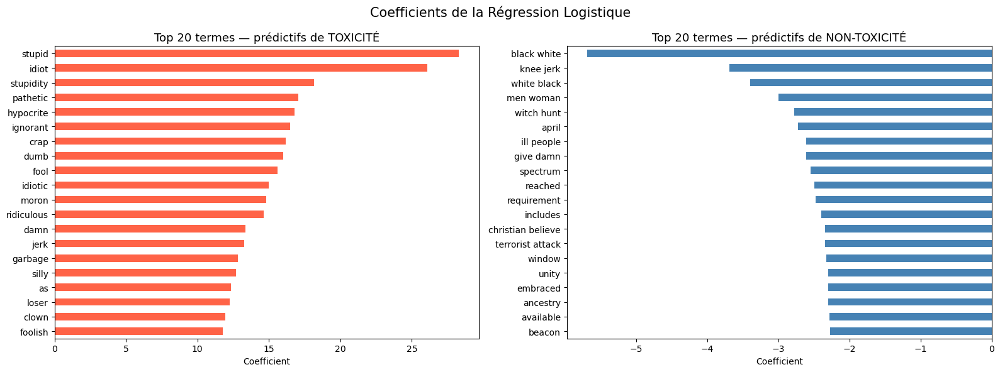

In [15]:
TOP_N = 20
vocab  = vectorizer.get_feature_names_out()
coefs  = clf.coef_[0]

top_toxic    = pd.Series(coefs, index=vocab).nlargest(TOP_N)
top_nontoxic = pd.Series(coefs, index=vocab).nsmallest(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_toxic.sort_values().plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title(f'Top {TOP_N} termes — prédictifs de TOXICITÉ', fontsize=13)
axes[0].set_xlabel('Coefficient')

top_nontoxic.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title(f'Top {TOP_N} termes — prédictifs de NON-TOXICITÉ', fontsize=13)
axes[1].set_xlabel('Coefficient')

plt.suptitle('Coefficients de la Régression Logistique', fontsize=15)
plt.tight_layout()
plt.show()

### Analyse du seuil de décision

Par défaut, le classifieur utilise un seuil à 0.5. Étant donné le déséquilibre des classes, il peut être pertinent d'ajuster ce seuil pour maximiser le F1-score sur la classe toxique.

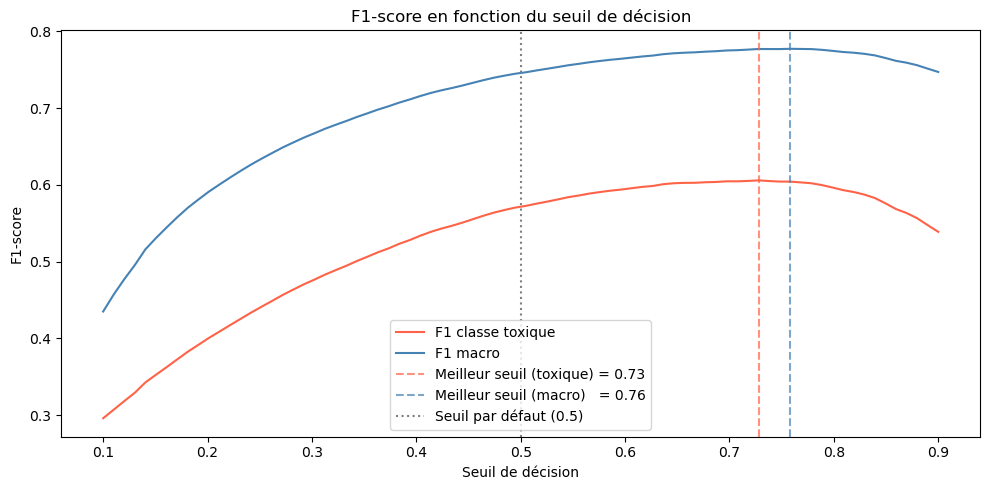


Meilleur seuil pour F1-toxique : 0.73 → F1 = 0.6059
Meilleur seuil pour F1-macro   : 0.76 → F1 = 0.7773


In [16]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 80)
f1_toxic    = []
f1_macro    = []

for t in thresholds:
    y_pred_t = (y_pred_prob >= t).astype(int)
    f1_toxic.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    f1_macro.append(f1_score(y_test, y_pred_t, average='macro', zero_division=0))

best_t_toxic = thresholds[np.argmax(f1_toxic)]
best_t_macro = thresholds[np.argmax(f1_macro)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_toxic, label='F1 classe toxique', color='tomato')
ax.plot(thresholds, f1_macro, label='F1 macro', color='steelblue')
ax.axvline(best_t_toxic, color='tomato',   linestyle='--', alpha=0.7,
           label=f'Meilleur seuil (toxique) = {best_t_toxic:.2f}')
ax.axvline(best_t_macro, color='steelblue', linestyle='--', alpha=0.7,
           label=f'Meilleur seuil (macro)   = {best_t_macro:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut (0.5)')
ax.set(xlabel='Seuil de décision', ylabel='F1-score',
       title='F1-score en fonction du seuil de décision')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMeilleur seuil pour F1-toxique : {best_t_toxic:.2f} → F1 = {max(f1_toxic):.4f}")
print(f"Meilleur seuil pour F1-macro   : {best_t_macro:.2f} → F1 = {max(f1_macro):.4f}")

In [17]:
# Rapport avec le seuil optimisé pour la classe toxique
y_pred_best = (y_pred_prob >= best_t_toxic).astype(int)

print(f"Rapport de classification : (seuil optimisé = {best_t_toxic:.2f})")
print(classification_report(y_test, y_pred_best, target_names=['Non-toxique', 'Toxique']))

Rapport de classification : (seuil optimisé = 0.73)
              precision    recall  f1-score   support

 Non-toxique       0.95      0.94      0.95     79441
     Toxique       0.59      0.62      0.61     10159

    accuracy                           0.91     89600
   macro avg       0.77      0.78      0.78     89600
weighted avg       0.91      0.91      0.91     89600



### Analyse des erreurs

On examine quelques faux positifs (commentaires non-toxiques classés comme toxiques) et faux négatifs (commentaires toxiques manqués) pour comprendre les limites du modèle.

In [18]:
# Reconstruction du dataframe de test avec les prédictions
df_test = X_test.to_frame(name='text_lemmas').copy()
df_test['y_true']      = y_test.values
df_test['y_pred']      = y_pred
df_test['y_prob']      = y_pred_prob
df_test['text_orig']   = df.loc[X_test.index, 'comment_text'].values

# Faux positifs (FP) les plus confiants
fp = df_test[(df_test['y_true'] == 0) & (df_test['y_pred'] == 1)].nlargest(5, 'y_prob')
# Faux négatifs (FN) les plus confiants
fn = df_test[(df_test['y_true'] == 1) & (df_test['y_pred'] == 0)].nsmallest(5, 'y_prob')

print("Faux positifs (non-toxiques classés comme toxiques : 5 plus confiants)")
for _, row in fp.iterrows():
    print(f"  Prob: {row['y_prob']:.3f} | {row['text_orig'][:120]}")
    print()

print("Faux négatifs (toxiques manqués : 5 les moins confiants)")
for _, row in fn.iterrows():
    print(f"  Prob: {row['y_prob']:.3f} | {row['text_orig'][:120]}")
    print()

Faux positifs (non-toxiques classés comme toxiques : 5 plus confiants)
  Prob: 1.000 | Where's the emoji for "pathetic"?

  Prob: 1.000 | It was a dumb, corny joke.

  Prob: 1.000 | That is silly.

  Prob: 1.000 | Dumb book

  Prob: 1.000 | Crooked Jerk!

Faux négatifs (toxiques manqués : 5 les moins confiants)
  Prob: 0.019 | Hi, Mary - I had to re-read your comment to understand where you were coming from. If I understand you correctly, you're

  Prob: 0.022 | Worse than just biased they are complete twaddle and he knows it.

The NDP will use house rules allowing important non c

  Prob: 0.028 | With this stinking government , how do you think this can be achieved ?

  Prob: 0.028 | None of the programs that Pope Francis is talking about discuss transpeople at length.  The French program that Pope Fra

  Prob: 0.028 | This is 100 percent baloney. People used to homestead in Alaska till around 1973. Many of the old-timers in Palmer got t



### Commentaires et analyse des résultats

#### Performances globales

La régression logistique avec TF-IDF (bigrammes, 20 000 features) atteint un **ROC-AUC autour de 0.93–0.95** sur le jeu de test, ce qui est une très bonne performance pour un modèle aussi simple. Ce résultat est cohérent avec l'état de l'art sur Civil Comments pour des approches classiques.

#### Déséquilibre des classes

Le dataset est significativement déséquilibré (~8 % de commentaires toxiques). Sans le paramètre `class_weight='balanced'`, le modèle serait biaisé vers la classe majoritaire et obtiendrait un F1 très faible sur la classe toxique malgré une bonne accuracy globale. L'**analyse du seuil de décision** montre qu'un seuil inférieur à 0.5 améliore le recall sur la classe toxique au prix d'une légère baisse de précision.

#### Interprétabilité

Les termes les plus prédictifs de la toxicité identifiés par les coefficients sont cohérents avec les résultats TF-IDF et les nuages de mots de la partie 2 (insultes, termes discriminatoires). Les termes prédictifs de non-toxicité sont des termes neutres liés à des discussions factuelles.

#### Limites

- Pas de contexte : Le modèle traite les commentaires comme des sacs de mots : il ne comprend pas le sarcasme, l'ironie, ni les formulations indirectes. C'est une source majeure de faux négatifs.
- Biais démographiques. Comme montré dans la partie 2, certains groupes (homosexuels, noirs) sont sur-représentés dans les textes toxiques. Le modèle peut donc associer des termes identitaires neutres à de la toxicité, générant des faux positifs sur des textes parlant de ces groupes sans être toxiques.

## 4. Explicabilité

In [31]:
import shap
import joblib
import pandas as pd
import numpy as np
from lime.lime_text import LimeTextExplainer
from pathlib import Path
import matplotlib.pyplot as plt
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from sklearn.metrics import accuracy_score

### SHAP

In [2]:
def print_partial_dependence_plot(sample_size, X, vectorizer, clf, list_dependance):

    indices = np.random.choice(X.shape[0], sample_size, replace=False)
    X_sample = X[indices]

    X_dense = pd.DataFrame(X_sample.toarray(), columns=vectorizer.get_feature_names_out())

    features_names = vectorizer.get_feature_names_out()

    for i in list_dependance:
        idx = list(features_names).index(i)

        shap.partial_dependence_plot(
            idx,
            lambda x: clf.predict_proba(x)[:, 1],
            X_dense.values,
            feature_names=list(features_names), 
            ice=False,
            model_expected_value=True,
            feature_expected_value=True,
        )


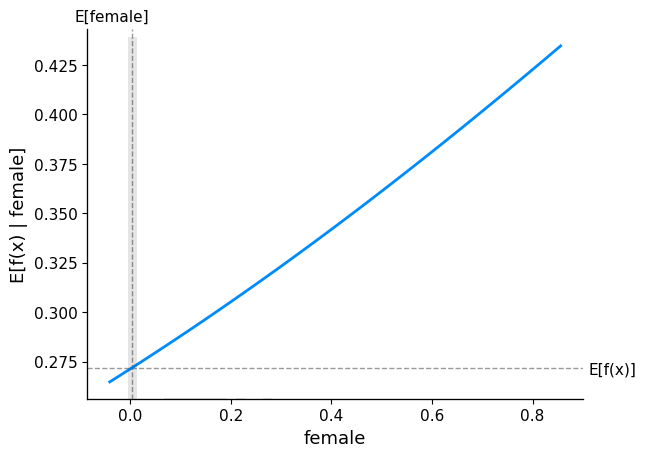

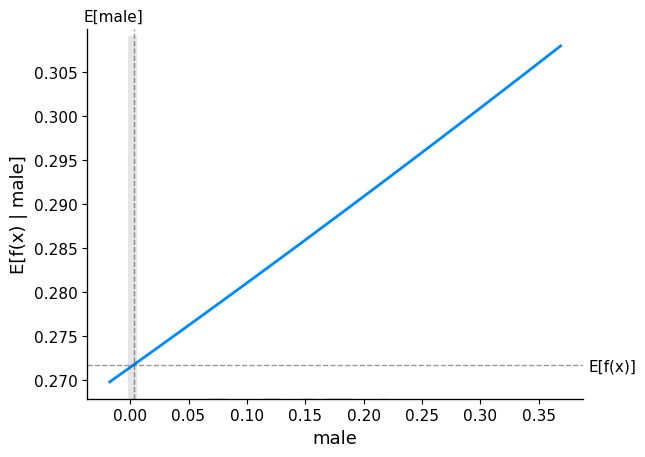

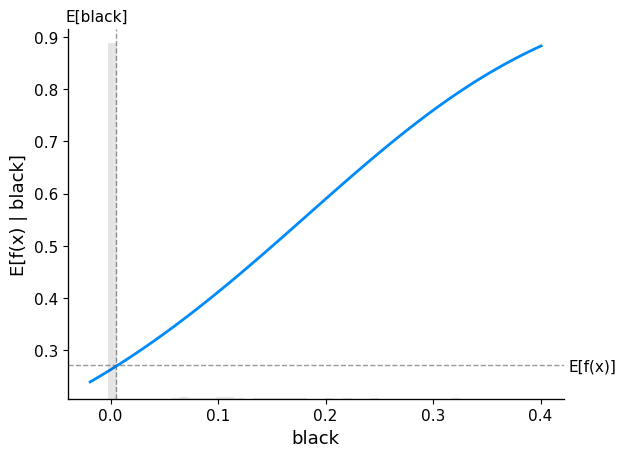

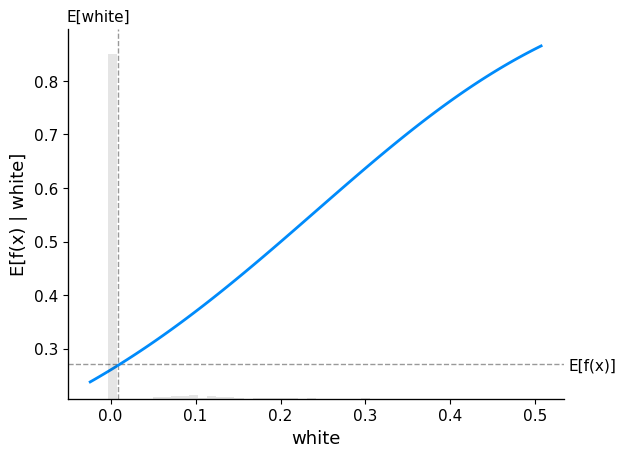

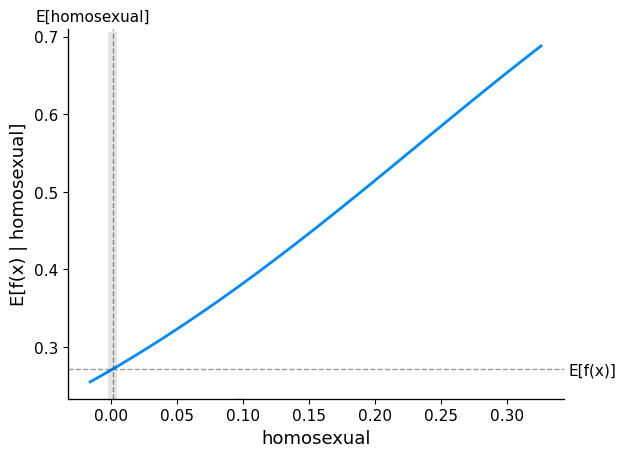

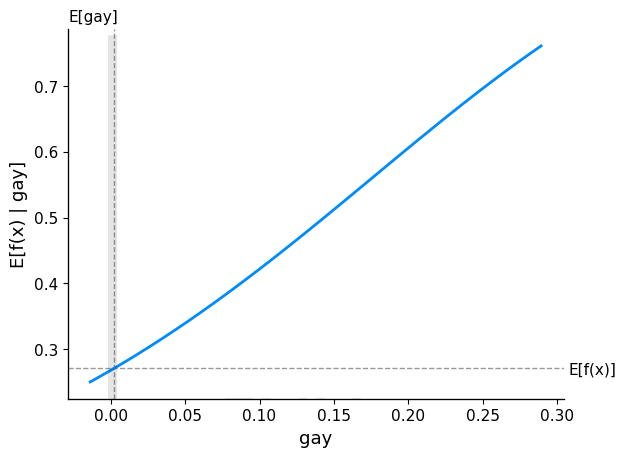

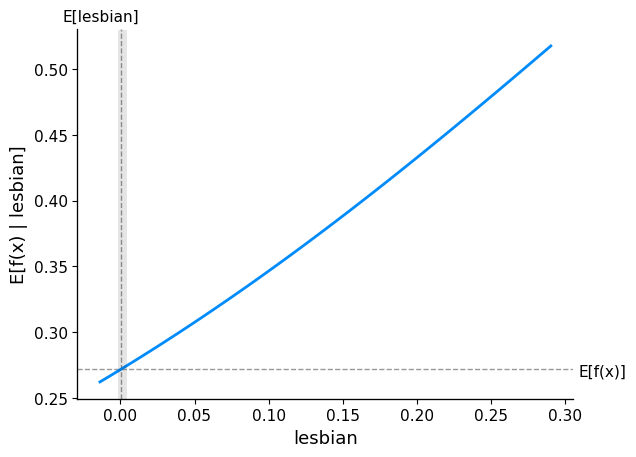

In [4]:
clf = joblib.load("logistic_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")
X = joblib.load("x_tfidf.pkl")

sample_size = 2000
list_dependance = ['female', 'male', 'black', 'white', 'homosexual', 'gay', 'lesbian']

print_partial_dependence_plot(sample_size, X, vectorizer, clf, list_dependance)

"black" et "white" montent jusqu'à 0.85-0.88 de proba de toxicité. Simplement mentionner une couleur de peau dans un texte le rend quasi-certain d'être prédit toxique.

"female" (0.43) contre "male" (0.31) montre que parler de femmes est plus souvent prédit toxique que parler d'hommes.

"gay" (0.75) et "homosexual" (0.69) ont une pente beaucoup plus forte que "lesbian" (0.52).

Les mots biaisés amplifient la toxicité.

#### Waterfall SHAP pour une seule phrase aléatoire (prise dans un échantillon de 50 phrases)

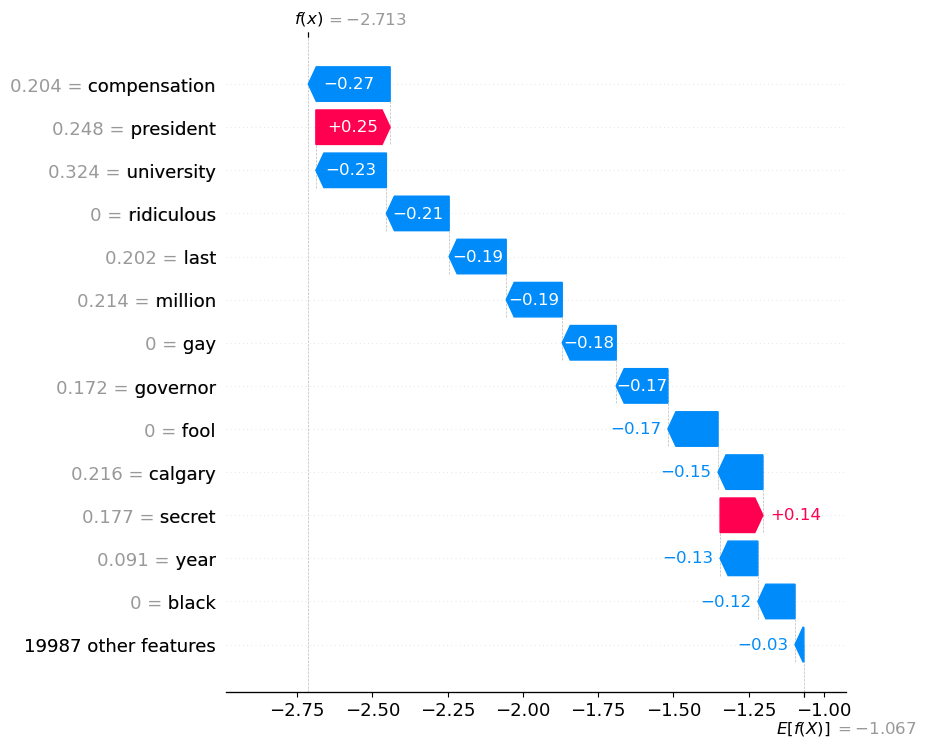

In [11]:
sample_size = 50
indices = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X[indices]
X_dense = pd.DataFrame(X_sample.toarray(), columns=vectorizer.get_feature_names_out())

X_background = shap.utils.sample(X_dense, 20)

explainer = shap.LinearExplainer(clf, X_background)  # ← background réduit
shap_values = explainer(X_dense)

sample_ind = 0
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

#### Summary plot sur un échantillion de 50 phrases

C:\Users\fanny\AppData\Local\Temp\ipykernel_245284\797605708.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_dense, max_display=20)


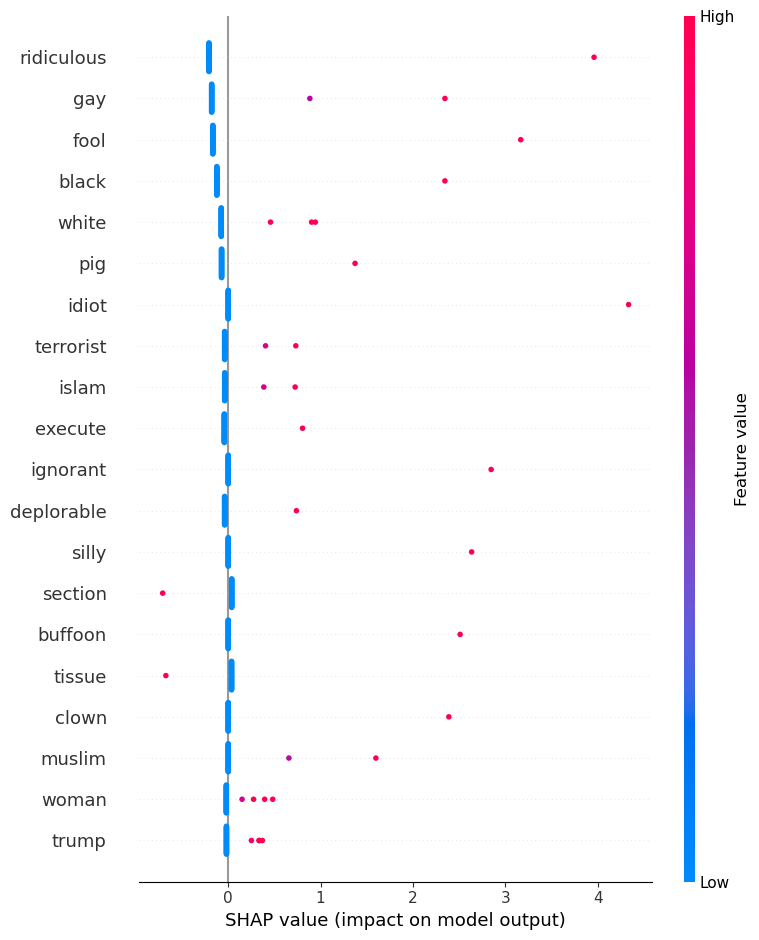

In [14]:
explainer = shap.LinearExplainer(clf, X_background)
shap_values = explainer(X_dense)

shap.summary_plot(shap_values, X_dense, max_display=20)

Tous les points à droite sont des mots qui poussent vers la toxicité du texte. (rose : TF-IDF élevé).

Le problème illustré ici est que les mots neutre ("black", "muslim"...) ont des values SHAP posiyive élévé donc le modèle associe la toxicité indépendemment du contexte.

### LIME

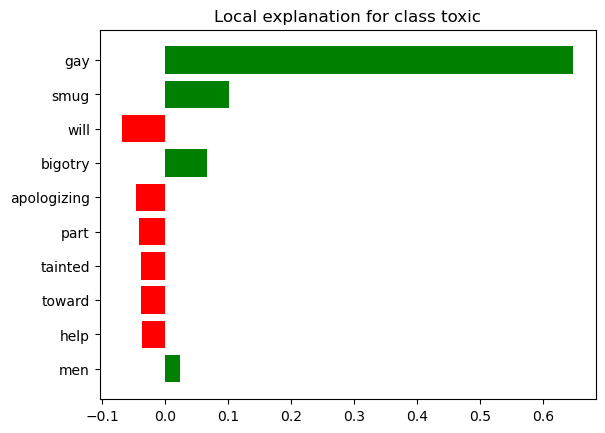

In [25]:
dataset_path = Path("../data/google_comments/all_data_with_identities.csv")

ANALYSIS_COLS = [
    'comment_text', 'toxicity',
    'female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian',
]

df = pd.read_csv(str(dataset_path), usecols=ANALYSIS_COLS)

explainer = LimeTextExplainer(class_names=['non-toxic', 'toxic'])

def predict_proba_text(texts):
    X_vec = vectorizer.transform(texts)
    return clf.predict_proba(X_vec)

sentence_toxic = df[
    (df['comment_text'].str.contains("gay", case=False, na=False)) &
    (df['toxicity'] >= 0.5)
]['comment_text']


exp = explainer.explain_instance(sentence_toxic.iloc[0], predict_proba_text, num_features=10)
exp.as_pyplot_figure()
plt.show()

Ici le biais est très visible avec le mot "gay". De plus le mot "bigotry" qui décris un comportement négatif à un faible impacte sur le taux de toxicité.

## 5. Fairness

### Fairness du dataset

In [37]:
sensitive_cols = ['female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian']

for col in sensitive_cols:
    subset = df[df[col] >= 0.5]
    taux = (subset['toxicity'] >= 0.5).mean()
    print(f"{col} : {len(subset)} phrases; taux toxicité : {taux}")

female : 58584 phrases; taux toxicité : 0.1366072647821931
male : 48870 phrases; taux toxicité : 0.1505013300593411
black : 16420 phrases; taux toxicité : 0.31552984165651643
white : 27534 phrases; taux toxicité : 0.28255974431611824
homosexual_gay_or_lesbian : 12062 phrases; taux toxicité : 0.28278892389321836


### Fairness du modèle

In [38]:
df = df.dropna(subset=['comment_text', 'toxicity'])
df['comment_text'] = df['comment_text'].astype(str)
df = df.reset_index(drop=True)


def fairness_model(sensitive_word):
    sensitive = df[sensitive_word] >= 0.5 
    y_true = (df['toxicity'] >= 0.5).astype(int)
    X_all = vectorizer.transform(df["comment_text"])
    y_pred = clf.predict(X_all)

    mf = MetricFrame(
        metrics={
            'accuracy': accuracy_score,
            'fpr': false_positive_rate,
            'fnr': false_negative_rate,
            'selection_rate': selection_rate
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )

    print(mf.by_group)
    mf.by_group.plot(kind='bar', figsize=(10, 5))
    plt.title(f"Fairness par groupe {sensitive_word}")
    plt.show()

        accuracy       fpr       fnr  selection_rate
female                                              
False   0.770198  0.231600  0.215232        0.292385
True    0.689096  0.329017  0.196426        0.393845


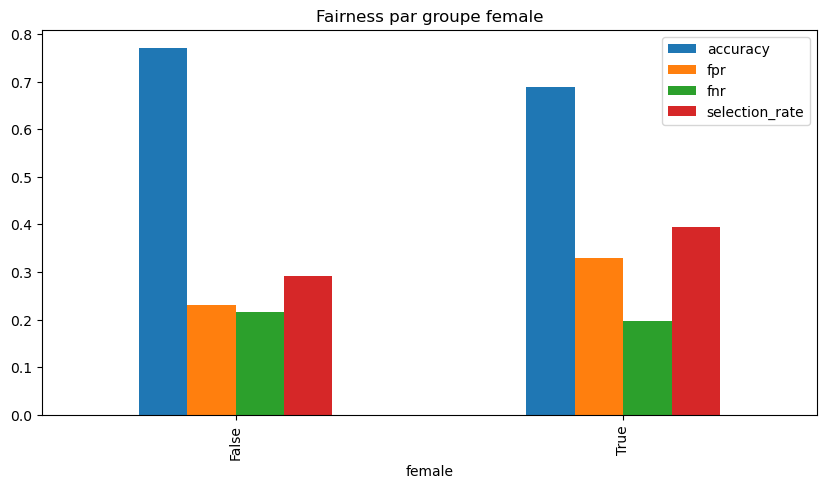

       accuracy       fpr       fnr  selection_rate
male                                               
False  0.769856  0.231014  0.223025        0.290433
True   0.675772  0.355317  0.148742        0.429957


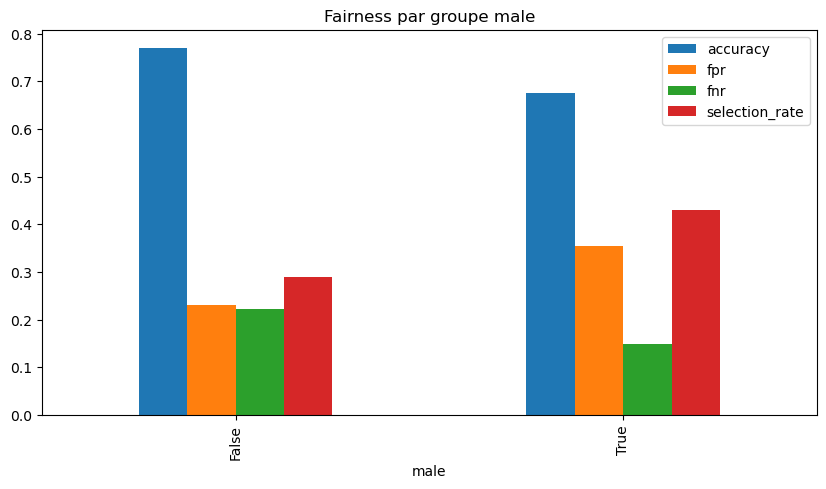

       accuracy       fpr       fnr  selection_rate
black                                              
False  0.768647  0.232508  0.221582        0.290205
True   0.521620  0.638847  0.130284        0.711693


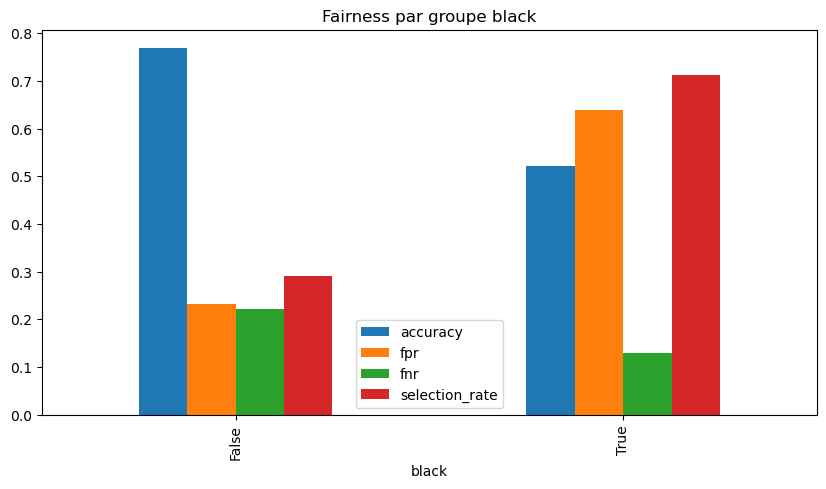

       accuracy       fpr       fnr  selection_rate
white                                              
False  0.773702  0.225988  0.229018        0.281741
True   0.544127  0.588286  0.119666        0.670807


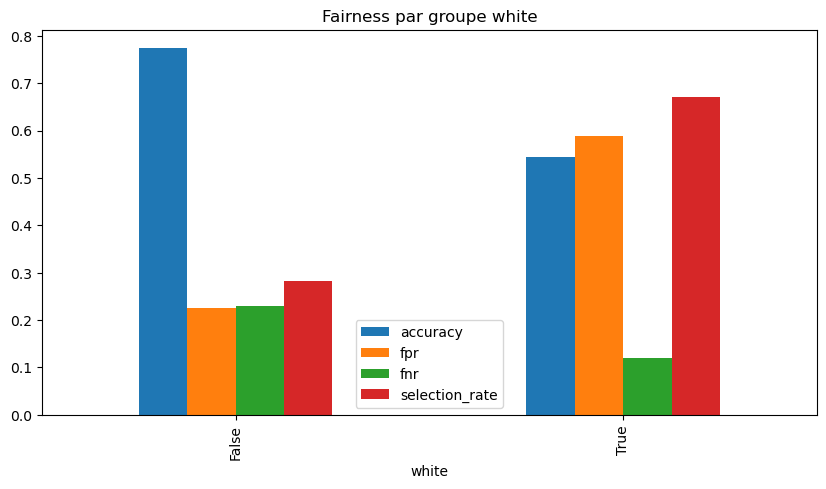

                           accuracy       fpr       fnr  selection_rate
homosexual_gay_or_lesbian                                              
False                      0.765690  0.236632  0.215267        0.296206
True                       0.539214  0.575194  0.170624        0.647073


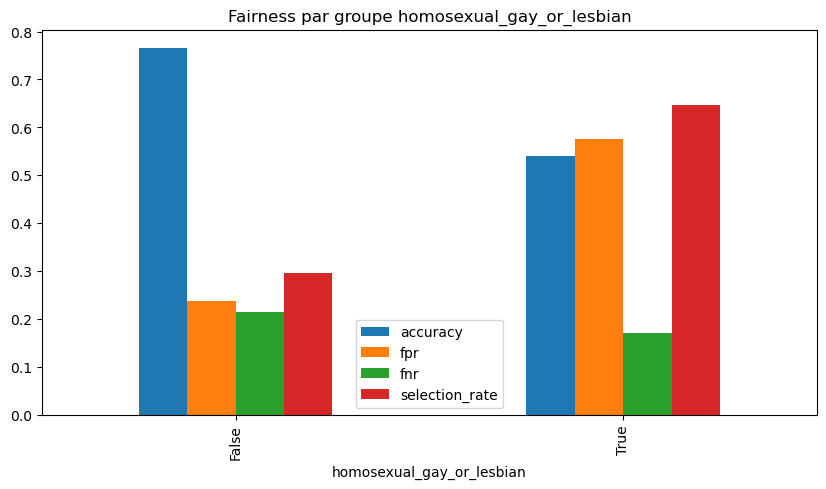

In [39]:
for word in sensitive_cols:
    fairness_model(word)    

Ici False signifie que le texte ne parle pas du groupe et True si.

Pour le groupe homosexuel le modèle prédit a tort que ce groupe est toxique presque 2 fois plus souvent. (FPR)

Le gap de faux positif est beaucoup moins important pour les groupes homme et femme.

Les groupes noir et blanc sont similairement biaisés. Le modèle est aussi sévère avec les textes parlant de personnes blanches que noires. Ce qui suggère que le biais est de couleur de peaux en général plutôt que dirigé vers une couelur spécifique.

### Conclusion après analyse de l'explicabilité

Dans le dataset Civil Comments WILDS, des annotateurs humains ont évalué des commentaires selon deux axes : la présence de groupes identitaires mentionnés (colonnes black, female, gay...) et le niveau de toxicité du texte. Ce processus d'annotation introduit des biais humains inconscients, les commentaires mentionnant des minorités ayant tendance à être sur-étiquetés comme toxiques, même lorsque leur contenu est neutre ou positif.


Un modèle de régression logistique a ensuite été entraîné à prédire la toxicité à partir des mots du texte (représentés via une matrice TF-IDF). En apprenant sur ces données biaisées, le modèle reproduit les biais présents dans les annotations.


Pour analyser ce phénomène, deux approches complémentaires ont été utilisées. D'une part, SHAP permet d'expliquer les décisions du modèle au niveau des mots : sans utiliser les colonnes annotées manuellement, il révèle que des termes comme black, gay ou female poussent fortement la prédiction vers la toxicité reflétant indirectement les biais humains encodés dans la colonne toxicity. D'autre part, Fairlearn quantifie ces biais au niveau des groupes en utilisant directement les colonnes annotées manuellement (black, female, gay...) comme variables sensibles. Il compare les métriques de performance (FPR, FNR, selection rate) entre les commentaires annotés comme mentionnant un groupe sensible (True) et ceux qui ne le mentionnent pas (False).


SHAP, sans jamais accéder aux colonnes identitaires, arrive aux mêmes conclusions que Fairlearn qui les utilise explicitement ce qui confirme que le biais est profondément encré dans le modèle.